# EBSD Per-Grain Pantleon WTMM — v2

Refactored notebook using `wtmm_ebsd/` modules. Each cell is a thin
wrapper around library functions; the heavy lifting is unit-tested
in `wtmm_ebsd/tests/`.

**Differences vs v1** (see `PERGRAIN_PANTLEON_REFACTOR_PLAN.md`):
- Frozen v1 is the regression baseline; this notebook reproduces v1
  outputs at the configured tolerance per the plan's tolerance table.
- Two silent v1 bugs are fixed and **will produce divergence** vs v1:
  1. `wtmm_ebsd.symmetry.orix_class_name`: orix Symmetry singletons
     all have `__class__.__name__ == 'Symmetry'` — v1's Dauphine
     check and `fz_max_deg` lookup were silently failing.
  2. Cell 10 Dauphine quaternion was 60° instead of 180° (a no-op
     against existing D3 symmetry). Fixed in `wtmm_ebsd.grains`.
- Numba on the gb-aware gradient (≈100×) and on KAM (≈10×).
- Sample-frame Nye tensor by default (frame-coherent).


## 1. Imports

In [64]:
# Cell A (revised)
import importlib, wtmm_ebsd.mtex_bridge
importlib.reload(wtmm_ebsd.mtex_bridge)
from wtmm_ebsd.mtex_bridge import mtex_dauphine_parents

import matlab.engine
if 'eng' not in globals():
    eng = matlab.engine.start_matlab()

# Build MTEX environment explicitly — independent of ~/Documents/MATLAB/startup.m
eng.eval("addpath('/Users/amasaryk/projects/mtex/mtex-5.11.2'); startup_mtex;", nargout=0)
eng.eval("addpath(genpath('/Users/amasaryk/projects/mtex_addons/ORTools'))", nargout=0)
eng.eval("addpath(genpath('/Users/amasaryk/projects/mtex_addons/CVA'))", nargout=0)

print('MATLAB:', eng.version(nargout=1))
print('MTEX  :', eng.eval("getMTEXpref('mtexPath')", nargout=1))
print('CVA   :', eng.eval("which('gridCVA')", nargout=1))
print('ORTool:', eng.eval("which('setParentGrainReconstructor')", nargout=1))

I found another version of MTEX and remove it from the current search path!
initialize MTEX 5.11.2  ...MATLAB: 25.2.0.3177638 (R2025b) Update 5
MTEX  : /Users/amasaryk/projects/mtex/mtex-5.11.2
CVA   : /Users/amasaryk/projects/mtex_addons/CVA/gridCVA.m
ORTool: /Users/amasaryk/projects/mtex_addons/ORTools/src/parentGrainReconstruction/setParentGrainReconstructor.m


In [65]:
import matlab.engine
import time
print('Importing OK. Starting MATLAB (this takes 15–30s the first time)...')
t0 = time.time()
eng = matlab.engine.start_matlab()
print(f'MATLAB started in {time.time()-t0:.1f}s')
print('Version:', eng.version(nargout=1))

Importing OK. Starting MATLAB (this takes 15–30s the first time)...
MATLAB started in 3.0s
Version: 25.2.0.3177638 (R2025b) Update 5


In [66]:
# Cell A.5 (reload bridge after the .m + .py edits)
import importlib, wtmm_ebsd.mtex_bridge
importlib.reload(wtmm_ebsd.mtex_bridge)
from wtmm_ebsd.mtex_bridge import mtex_dauphine_parents

In [67]:
# Cell B (re-run to get fresh diag with initial_gid)
gid_mtex, diag = mtex_dauphine_parents(
    ebsd, eng,
    initial_threshold_deg=10.0,
    twin_tolerance_deg=4.0,
    verbose=True,
)
print(list(diag.keys()))   # should include 'initial_gid' now

[mtex_bridge] Sending 927x1237 map (1146699 indexed pixels) to MATLAB...
  Building EBSD object: 1146699 pixels, step=(1.1, 1.1) um
  size(euler1) = [927, 1237]  (sanity check, should be 927 x 1237)
  pre-EBSD x_um: length=1146699, range=[0, 1.36e+03], n_unique=1237
  pre-EBSD y_um: length=1146699, range=[0, 1.02e+03], n_unique=927
  prop fields: x, y
  post-EBSD ebsd_obj.prop.x: length=1146699 (constructor OK)
  post-subset ebsd_q.prop.x: length=1146699 (subset OK)
  Running calcGrains at 10.0 deg threshold ...


TypeError: cannot unpack non-iterable NoneType object

In [ ]:
import numpy as np
from wtmm_ebsd.grains import identify_grains

# Re-run Python flood-fill at same threshold for fair comparison
gid_py = identify_grains(ebsd, theta_c_deg=10.0, dauphine_aware=True)

n_py   = int((np.unique(gid_py)   > 0).sum())
n_mtex = int((np.unique(gid_mtex) > 0).sum())
print(f'Python flood-fill (Dauphine-aware D3d->D6h):  {n_py:6d} grains')
print(f'MTEX grain.merge(twin boundaries):            {n_mtex:6d} grains')
print(f'Reduction by MTEX over Python flood-fill:     {n_py - n_mtex} grains'
      f'  ({100*(n_py-n_mtex)/n_py:.1f}%)')

Python flood-fill (Dauphine-aware D3d->D6h):    2811 grains
MTEX grain.merge(twin boundaries):              1095 grains
Reduction by MTEX over Python flood-fill:     1716 grains  (61.0%)


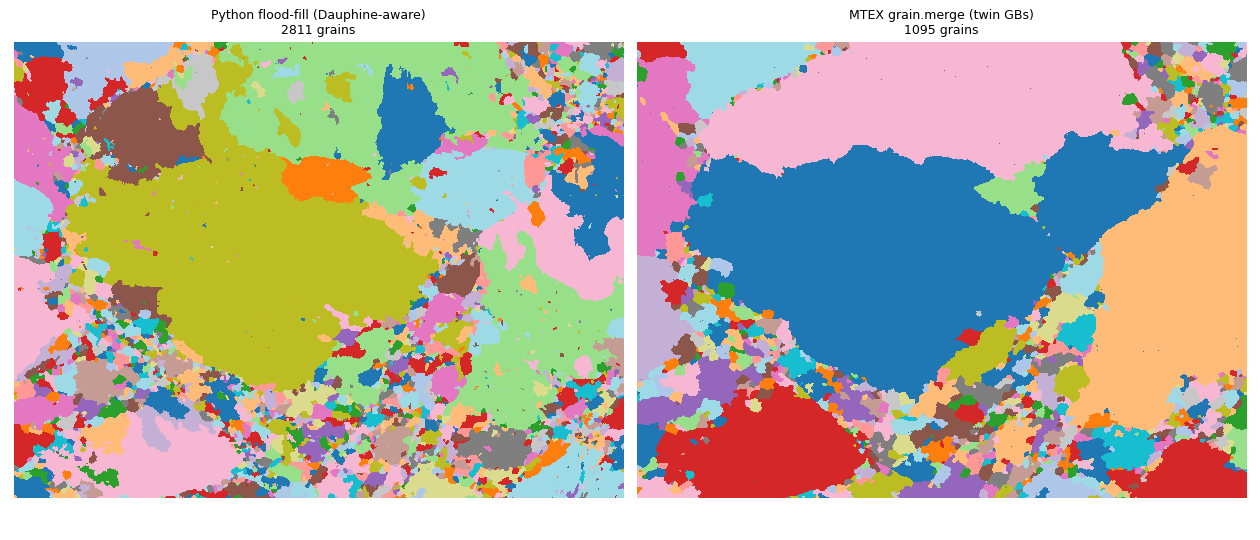

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(np.where(gid_py > 0, gid_py % 47, 0), 
                cmap='tab20', interpolation='none')
axes[0].set_title(f'Python flood-fill (Dauphine-aware)\n{n_py} grains')
axes[0].axis('off')

axes[1].imshow(np.where(gid_mtex > 0, gid_mtex % 47, 0),
                cmap='tab20', interpolation='none')
axes[1].set_title(f'MTEX grain.merge (twin GBs)\n{n_mtex} grains')
axes[1].axis('off')

plt.tight_layout()
plt.show()

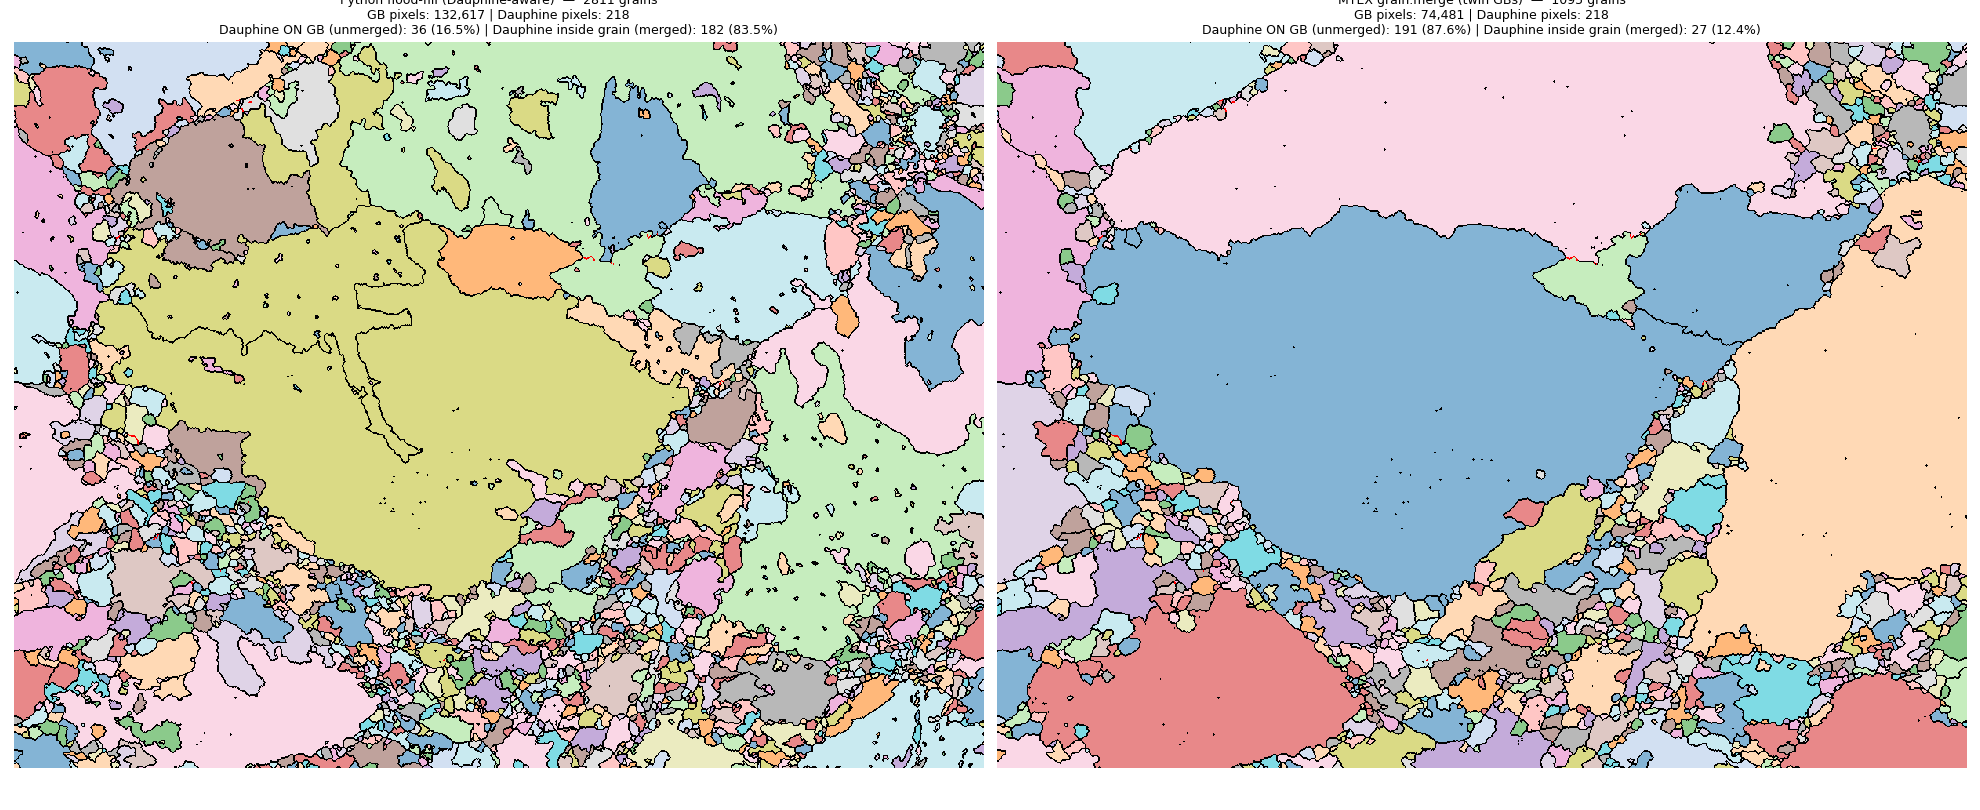

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.papeschi import detect_dauphine_boundaries
from wtmm_ebsd.grains import build_gb_mask

# Dauphine boundaries (same physical detection regardless of segmentation)
dr, dd = detect_dauphine_boundaries(ebsd)
ny, nx = ebsd['euler1'].shape
dau_mask = np.zeros((ny, nx), dtype=bool)
dau_mask[:, :-1] |= dr; dau_mask[:, 1:] |= dr
dau_mask[:-1, :] |= dd; dau_mask[1:, :] |= dd

# Per-segmentation GB masks
gb_py   = build_gb_mask(gid_py)
gb_mtex = build_gb_mask(gid_mtex)

n_py   = int((np.unique(gid_py)   > 0).sum())
n_mtex = int((np.unique(gid_mtex) > 0).sum())

def overlay_panel(ax, gid, gb_mask, dau_mask, title):
    # Grain interiors (pastel)
    ax.imshow(np.where(gid > 0, gid % 47, -1), cmap='tab20', interpolation='none',
              vmin=0, alpha=0.55)
    # GBs in black
    gb_rgba = np.zeros((*gb_mask.shape, 4))
    gb_rgba[gb_mask] = [0, 0, 0, 1.0]
    ax.imshow(gb_rgba, interpolation='none')
    # Dauphine boundaries in red — drawn on top
    dau_rgba = np.zeros((*dau_mask.shape, 4))
    dau_rgba[dau_mask] = [1.0, 0.0, 0.0, 1.0]
    ax.imshow(dau_rgba, interpolation='none')
    # Diagnostic counts
    n_dau           = int(dau_mask.sum())
    n_dau_on_gb     = int((dau_mask & gb_mask).sum())
    n_dau_in_grain  = int((dau_mask & ~gb_mask).sum())
    ax.set_title(
        f'{title}\n'
        f'GB pixels: {int(gb_mask.sum()):,} | '
        f'Dauphine pixels: {n_dau:,}\n'
        f'Dauphine ON GB (unmerged): {n_dau_on_gb:,} '
        f'({100*n_dau_on_gb/max(n_dau,1):.1f}%) | '
        f'Dauphine inside grain (merged): {n_dau_in_grain:,} '
        f'({100*n_dau_in_grain/max(n_dau,1):.1f}%)'
    )
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
overlay_panel(axes[0], gid_py,   gb_py,   dau_mask,
              f'Python flood-fill (Dauphine-aware)  —  {n_py} grains')
overlay_panel(axes[1], gid_mtex, gb_mtex, dau_mask,
              f'MTEX grain.merge (twin GBs)  —  {n_mtex} grains')
plt.tight_layout()
plt.show()

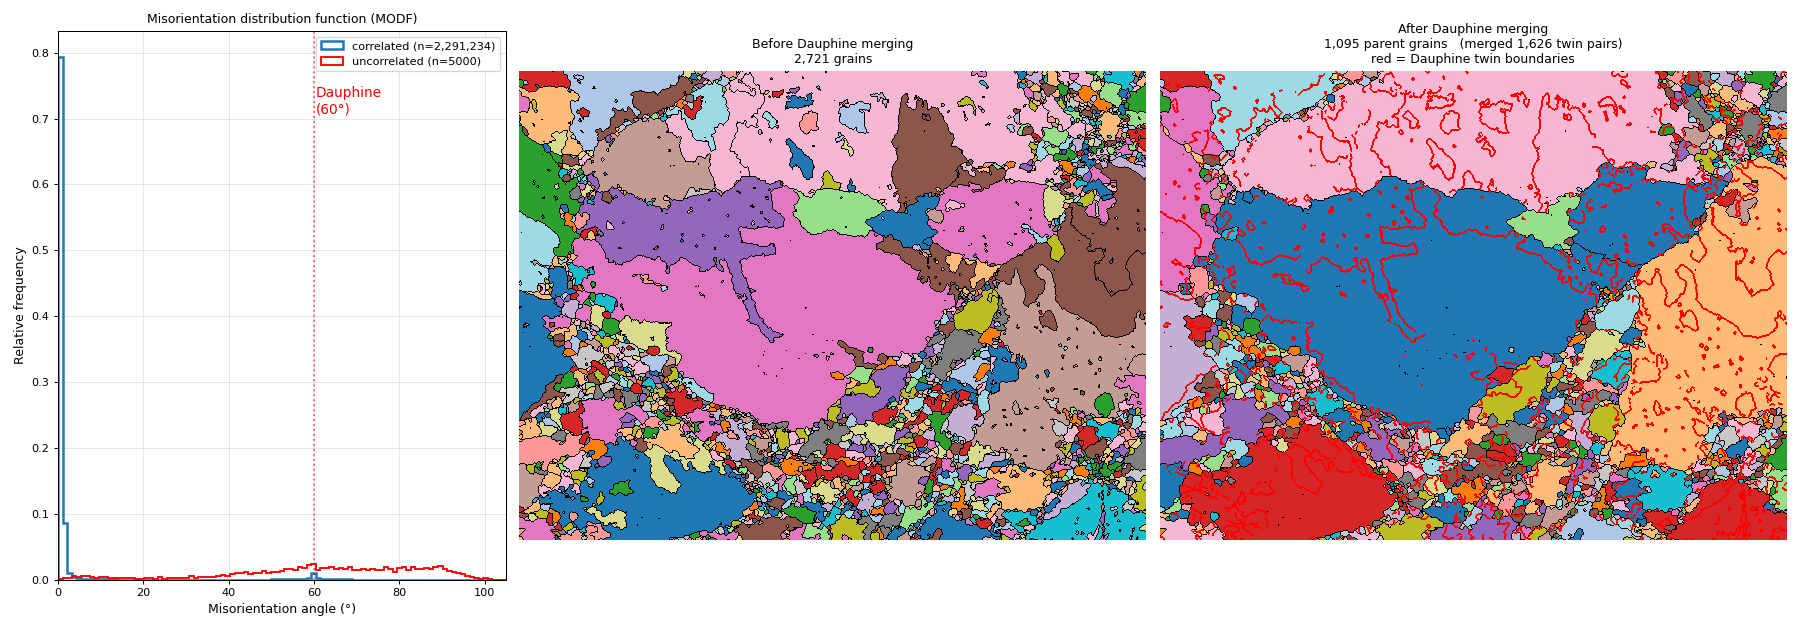

Saved: mtex_dauphine_demo.png


In [59]:
# ============================================================================
#  Cell: Presentation figure — MODF + before/after Dauphine merging
#  Re-run Cell B first if you haven't already, so diag has the new fields
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation
from wtmm_ebsd.papeschi import neighbor_misorientation_axis_angle
from wtmm_ebsd.grains import build_gb_mask
from orix.quaternion.symmetry import D3d

# ---------------- 1. Compute MODF (correlated + uncorrelated) ----------------
sym_q = D3d.data.astype(np.float64)

# Correlated: actual neighbor pairs
th_r, _ = neighbor_misorientation_axis_angle(ebsd, sym_q, direction='right')
th_d, _ = neighbor_misorientation_axis_angle(ebsd, sym_q, direction='down')
ang_corr = np.rad2deg(np.concatenate([th_r[np.isfinite(th_r)],
                                      th_d[np.isfinite(th_d)]]))

# Uncorrelated: 5000 random pairs from indexed pixels
mask_indexed = ebsd['phase'] > 0
ny, nx = ebsd['phase'].shape
e1 = ebsd['euler1'][mask_indexed].ravel()
e2 = ebsd['euler2'][mask_indexed].ravel()
e3 = ebsd['euler3'][mask_indexed].ravel()
n_pairs_uncorr = 5000
rng = np.random.default_rng(42)
i_a = rng.integers(0, e1.size, n_pairs_uncorr)
i_b = rng.integers(0, e1.size, n_pairs_uncorr)

from wtmm_ebsd.orientation import euler_to_quat, quat_mul, quat_conj
q_a = euler_to_quat(np.deg2rad(e1[i_a]), np.deg2rad(e2[i_a]), np.deg2rad(e3[i_a]))
q_b = euler_to_quat(np.deg2rad(e1[i_b]), np.deg2rad(e2[i_b]), np.deg2rad(e3[i_b]))
q_rel = quat_mul(q_a, quat_conj(q_b))
# symmetry-reduce: max |w| over sym
w_abs = np.abs(quat_mul(q_rel[:, None, :], sym_q[None, :, :])[..., 0])
ang_uncorr = np.rad2deg(2 * np.arccos(np.clip(w_abs.max(axis=1), 0, 1)))

# ---------------- 2. Three-panel figure -------------------------------------
gid_init  = diag['initial_gid']     # before merge
gid_final = gid_mtex                # after merge (= parent_grain_id)
dau_mask  = binary_dilation(diag['dauphine_mask'], iterations=1)

n_init  = int((np.unique(gid_init)  > 0).sum())
n_final = int((np.unique(gid_final) > 0).sum())

fig = plt.figure(figsize=(20, 7))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.4, 1.4])

# --- Panel 1: MODF ---
ax1 = fig.add_subplot(gs[0])
bins = np.linspace(0, 105, 100)
ax1.hist(ang_corr, bins=bins, density=True, histtype='step',
         color='C0', linewidth=2.0, label=f'correlated (n={ang_corr.size:,})')
ax1.hist(ang_uncorr, bins=bins, density=True, histtype='step',
         color='red', linewidth=1.5, label=f'uncorrelated (n={n_pairs_uncorr})')
ax1.axvline(60, color='red', linestyle=':', alpha=0.6)
ax1.text(60.5, ax1.get_ylim()[1]*0.85, 'Dauphine\n(60°)',
          color='red', fontsize=11)
ax1.set_xlabel('Misorientation angle (°)')
ax1.set_ylabel('Relative frequency')
ax1.set_title('Misorientation distribution function (MODF)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 105)

# --- Panel 2: Before merging ---
ax2 = fig.add_subplot(gs[1])
ax2.imshow(np.where(gid_init > 0, gid_init % 47, -1), cmap='tab20',
           interpolation='none', vmin=0)
gb_init_rgba = np.zeros((ny, nx, 4))
gb_init_rgba[build_gb_mask(gid_init)] = [0, 0, 0, 1]
ax2.imshow(gb_init_rgba, interpolation='none')
ax2.set_title(f'Before Dauphine merging\n{n_init:,} grains')
ax2.axis('off')

# --- Panel 3: After merging + Dauphine boundaries highlighted ---
ax3 = fig.add_subplot(gs[2])
ax3.imshow(np.where(gid_final > 0, gid_final % 47, -1), cmap='tab20',
           interpolation='none', vmin=0)
gb_final_rgba = np.zeros((ny, nx, 4))
gb_final_rgba[build_gb_mask(gid_final)] = [0, 0, 0, 1]
ax3.imshow(gb_final_rgba, interpolation='none')
dau_rgba = np.zeros((ny, nx, 4))
dau_rgba[dau_mask] = [1, 0, 0, 1]
ax3.imshow(dau_rgba, interpolation='none')
ax3.set_title(f'After Dauphine merging\n{n_final:,} parent grains'
              f'   (merged {n_init - n_final:,} twin pairs)\n'
              'red = Dauphine twin boundaries')
ax3.axis('off')

plt.tight_layout()
plt.savefig('/Users/amasaryk/projects/Creep/wavelet/mtex_dauphine_demo.png',
             dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mtex_dauphine_demo.png')

In [61]:
# Cell A.5: reload bridge after edits
import importlib, wtmm_ebsd.mtex_bridge
importlib.reload(wtmm_ebsd.mtex_bridge)
from wtmm_ebsd.mtex_bridge import mtex_dauphine_parents

In [62]:
# Cell B: re-run to populate diag with all the new fields
gid_mtex, diag = mtex_dauphine_parents(
    ebsd, eng,
    initial_threshold_deg=10.0,
    twin_tolerance_deg=4.0,
    verbose=True,
)
print(list(diag.keys()))   # 'mori_corr_deg', 'mori_uncor_deg', 'initial_gid', 'dauphine_mask'

[mtex_bridge] Sending 927x1237 map (1146699 indexed pixels) to MATLAB...
  Building EBSD object: 1146699 pixels, step=(1.1, 1.1) um
  size(euler1) = [927, 1237]  (sanity check, should be 927 x 1237)
  pre-EBSD x_um: length=1146699, range=[0, 1.36e+03], n_unique=1237
  pre-EBSD y_um: length=1146699, range=[0, 1.02e+03], n_unique=927
  prop fields: x, y
  post-EBSD ebsd_obj.prop.x: length=1146699 (constructor OK)
  post-subset ebsd_q.prop.x: length=1146699 (subset OK)
  Running calcGrains at 10.0 deg threshold ...
  Grains after initial segmentation: 2150
  Dauphine twin boundary segments detected: 34585 / 95965 (36.0%)
  Dauphine pixels marked: 48804
  Grains after Dauphine merging: 1095  (reduction: 49.1%)
  MODF: correlated=95965 pairs, uncorrelated=5000 pairs
  Done. Output shape: 927 x 1237, unique parent IDs: 1095 (+ 0 for unindexed)
[mtex_bridge] Initial grains:  2150
[mtex_bridge] After merging:   1095  (49.1% reduction)
[mtex_bridge] Twin GB segments: 34585
[mtex_bridge] Dauphin

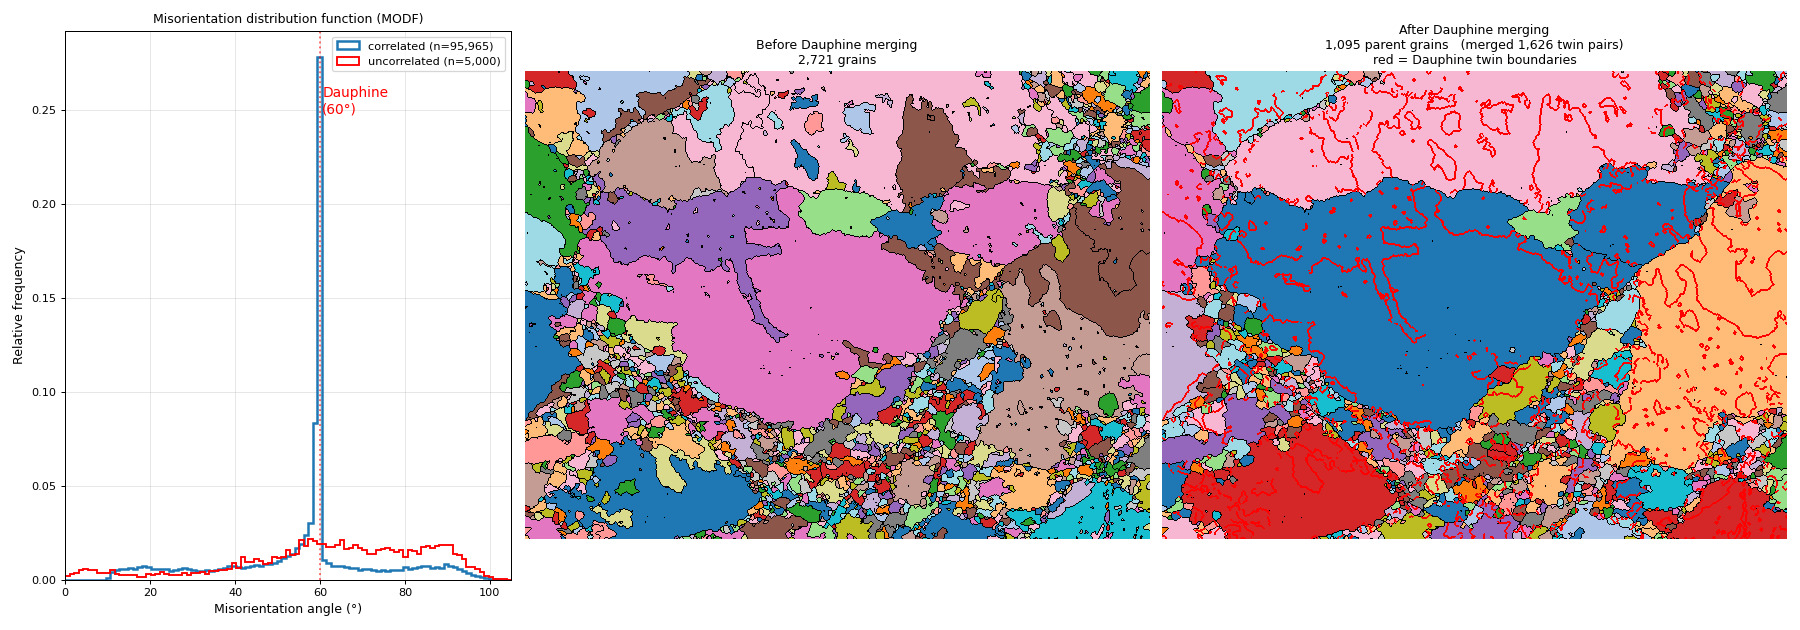

Saved: mtex_dauphine_demo.png


In [63]:
# Cell C: presentation figure (3 panels: MODF + before + after)
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation
from wtmm_ebsd.grains import build_gb_mask

ny, nx = ebsd['phase'].shape
ang_corr  = diag['mori_corr_deg']
ang_uncor = diag['mori_uncor_deg']
gid_init  = diag['initial_gid']
gid_final = gid_mtex
dau_mask  = binary_dilation(diag['dauphine_mask'], iterations=1)

n_init  = int((np.unique(gid_init)  > 0).sum())
n_final = int((np.unique(gid_final) > 0).sum())

fig = plt.figure(figsize=(20, 7))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.4, 1.4])

# --- Panel 1: MODF ---
ax1 = fig.add_subplot(gs[0])
bins = np.linspace(0, 105, 100)
ax1.hist(ang_corr,  bins=bins, density=True, histtype='step',
         color='C0', linewidth=2.0,
         label=f'correlated (n={ang_corr.size:,})')
ax1.hist(ang_uncor, bins=bins, density=True, histtype='step',
         color='red', linewidth=1.5,
         label=f'uncorrelated (n={ang_uncor.size:,})')
ax1.axvline(60, color='red', linestyle=':', alpha=0.6)
ax1.text(60.5, ax1.get_ylim()[1]*0.85, 'Dauphine\n(60°)',
          color='red', fontsize=11)
ax1.set_xlabel('Misorientation angle (°)')
ax1.set_ylabel('Relative frequency')
ax1.set_title('Misorientation distribution function (MODF)')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 105)

# --- Panel 2: Before merging ---
ax2 = fig.add_subplot(gs[1])
ax2.imshow(np.where(gid_init > 0, gid_init % 47, -1), cmap='tab20',
           interpolation='none', vmin=0)
gb_init_rgba = np.zeros((ny, nx, 4))
gb_init_rgba[build_gb_mask(gid_init)] = [0, 0, 0, 1]
ax2.imshow(gb_init_rgba, interpolation='none')
ax2.set_title(f'Before Dauphine merging\n{n_init:,} grains')
ax2.axis('off')

# --- Panel 3: After merging + Dauphine boundaries highlighted ---
ax3 = fig.add_subplot(gs[2])
ax3.imshow(np.where(gid_final > 0, gid_final % 47, -1), cmap='tab20',
           interpolation='none', vmin=0)
gb_final_rgba = np.zeros((ny, nx, 4))
gb_final_rgba[build_gb_mask(gid_final)] = [0, 0, 0, 1]
ax3.imshow(gb_final_rgba, interpolation='none')
dau_rgba = np.zeros((ny, nx, 4))
dau_rgba[dau_mask] = [1, 0, 0, 1]
ax3.imshow(dau_rgba, interpolation='none')
ax3.set_title(f'After Dauphine merging\n{n_final:,} parent grains'
              f'   (merged {n_init - n_final:,} twin pairs)\n'
              'red = Dauphine twin boundaries')
ax3.axis('off')

plt.tight_layout()
plt.savefig('/Users/amasaryk/projects/Creep/wavelet/mtex_dauphine_demo.png',
             dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mtex_dauphine_demo.png')

In [5]:
# Statement 1: assign cs in MATLAB's workspace (no return value)
eng.eval(
    "cs = crystalSymmetry('-3m', [4.913 4.913 5.504], 'mineral', 'Quartz');",
    nargout=0
)
# Statement 2: evaluate the expression (returns a value)
nrot = eng.eval("length(cs.properGroup.rot)", nargout=1)
print('Quartz proper rotations (D3):', int(nrot))

Quartz proper rotations (D3): 6


In [7]:
# What does the engine think `startup` is, and what's currently on its path?
print('startup file:', eng.eval("which('startup')", nargout=1))
print('CVA on path? :', eng.eval("any(strfind(path, 'CVA'))", nargout=1))

# Manual fix: addpath directly in this engine session
eng.eval("addpath(genpath('/Users/amasaryk/projects/mtex_addons/CVA'))", nargout=0)
eng.eval("addpath(genpath('/Users/amasaryk/projects/mtex_addons/ORTools'))", nargout=0)

# Verify
print('After manual addpath:')
print('  gridCVA:', eng.eval("which('gridCVA')", nargout=1))
print('  setParentGrainReconstructor:', eng.eval("which('setParentGrainReconstructor')", nargout=1))

startup file: /Users/amasaryk/projects/mtex/mtex-5.11.2/startup.m
CVA on path? : False
After manual addpath:
  gridCVA: /Users/amasaryk/projects/mtex_addons/CVA/gridCVA.m
  setParentGrainReconstructor: /Users/amasaryk/projects/mtex_addons/ORTools/src/parentGrainReconstruction/setParentGrainReconstructor.m


In [24]:
%load_ext autoreload
%autoreload 2

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---- global figure size + font tuning ----
# FIG_SCALE multiplies the *inches* of every figsize() set in this notebook;
# cells that read it will scale accordingly.  Lower = smaller plots, less
# screen real-estate.  Font sizes stay constant in points so text stays
# readable.  DPI low so widget iframes don't get huge on laptop screens.
FIG_SCALE = 0.7
plt.rcParams.update({
    'figure.dpi':       90,        # was matplotlib default 100
    'savefig.dpi':      150,       # publication exports stay sharp
    'font.size':        10,
    'axes.titlesize':   10,
    'axes.labelsize':   10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
})
%matplotlib widget

# wtmm_ebsd modules
from wtmm_ebsd import (
    cpo, demean, grains, ipf, kam, nye, orientation, papeschi,
    quality, shuffles, symmetry, twtmm, chain_filters,
)
from wtmm_ebsd.cwt2d import cwt_2d_f32, compute_scales
from wtmm_ebsd.io import read_ebsd
from wtmm_ebsd.cpo import (compute_cpo_attractor, compute_per_grain_cpo,
                            stereonet_density_plot)

# wtmm modules (palette, scalebar, publication plots, specific heat,
# Dupont/Venugopal partition + cumulant fits)
from wtmm.wavelet_scalebar import draw_wavelet_scalebar
from wtmm.multifractal_plots import (
    QUARTZ_SLIP_PALETTE, QUARTZ_SLIP_LABELS, get_pub_fonts,
    fit_cumulants, specific_heat,
    publication_spectra_2x2, multi_mode_overlay,
    centered_dh_plot, partition_loglog_panel,
)
from wtmm.dupont_venugopal import (
    fit_dupont_polynomial, fit_venugopal_cumulants, plateau_r2,
)
from wtmm.ebsd_zip import list_ebsd_files, open_ebsd

# xsmurf for the TWTMM driver
import xsmurf_wrapper as xsm
from xsmurf_wrapper.anchor_chain import chain_and_extract


## 2a. Browse all available EBSD datasets

Header-only metadata via `peek_all_datasets` — no data array is loaded.
Run this cell to see every file in `EBSD/` (including inside-zip entries)
with shape, step size, and phase names.  Use the `idx` column to set
`DATASET_INDEX` in the next cell.

In [9]:
# Header-only browse: all datasets in EBSD/ as a tidy table.
# Cheap — does NOT load any data arrays.
from wtmm.ebsd_zip import list_ebsd_files
from wtmm_ebsd.io import peek_all_datasets
from pathlib import Path

EBSD_DIR = Path("EBSD")
files = list_ebsd_files(EBSD_DIR)
print(f"Found {len(files)} EBSD files in {EBSD_DIR.resolve()}")

datasets_df = peek_all_datasets(files)
# Drop the 'error' column from the default view if everything parsed cleanly
_view = datasets_df.drop(columns=['error']) if (datasets_df['error'] == '').all() \
        else datasets_df
print()
# Show the whole table (don't truncate names) — typical use is ~25 files.
import pandas as pd
with pd.option_context('display.max_rows', None,
                        'display.max_colwidth', 80,
                        'display.width', 180):
    print(_view.to_string(index=False))


Found 94 EBSD files in /Users/amasaryk/projects/Creep/wavelet/EBSD

 idx                                                                       name format     ny     nx   xstep_um  n_phases                                                                                                                      phases
   0                                                 Overview_Map_Processed.ctf    ctf  600.0  800.0   1.508100         3                                                                                                   Siderite, Pyrite, Calcite
   1                                                       Overview_Map_Raw.ctf    ctf  600.0  800.0   1.508071         3                                                                                                   Siderite, Pyrite, Calcite
   2                                              Siderite_Detail_Processed.ctf    ctf  750.0 1000.0   0.219300         3                                                                         

## 2b. Load EBSD dataset(s)

Set either `DATASET_INDEX` (single dataset, original behaviour) **or**
`DATASET_INDICES` (list of indices to load several at once).  When
multiple are loaded, `ACTIVE_DATASET_INDEX` decides which one is the
"active" dataset that the rest of the pipeline operates on (it controls
the globals `ebsd`, `px_um`, etc.).  All loaded scans live in the
`datasets` dict; switch active dataset by re-running cell 6c with a
different `ACTIVE_DATASET_INDEX`.

For multi-dataset comparisons:
1. Load all the scans in cell 6.
2. Run the pipeline for each one by changing `ACTIVE_DATASET_INDEX` (cell 6c)
   and re-running from cell 8 onward.
3. After each run, the heavy outputs (KAM, alpha, partition function, ...)
   can be stashed under `datasets[idx]['results']` for cross-dataset
   comparison cells at the end of the notebook.

`DATASET_INDEX = 20` is the v1 snapshot baseline (SP78_Map_1).

In [10]:
# ===== Multi-dataset loader =====
# Backward-compatible: if you only set DATASET_INDEX, behaves like before.
# If you set DATASET_INDICES (list), loads all of them and lets
# ACTIVE_DATASET_INDEX choose which is "active" for the pipeline.
from wtmm.ebsd_zip import list_ebsd_files, open_ebsd
from wtmm_ebsd.io import read_ebsd
from pathlib import Path

# ---- USER PARAMETERS ----
DATASET_INDEX   = 21              # single-dataset shortcut (original API)
# DATASET_INDICES = [21] # uncomment to load multiple

ACTIVE_DATASET_INDEX = None       # None = auto-pick first in DATASET_INDICES
EBSD_DIR = Path("EBSD")
# -------------------------

if 'DATASET_INDICES' in dir() and DATASET_INDICES:
    indices_to_load = list(DATASET_INDICES)
else:
    indices_to_load = [DATASET_INDEX]

files = list_ebsd_files(EBSD_DIR)
print(f'Found {len(files)} EBSD files in {EBSD_DIR}/')
print(f'Loading {len(indices_to_load)} dataset(s): {indices_to_load}')

datasets = {}
for idx in indices_to_load:
    if not (0 <= idx < len(files)):
        print(f'  [skip] idx {idx} out of range')
        continue
    f = files[idx]
    print(f'\n  [{idx:3d}] {f.name}')
    with open_ebsd(f) as real_path:
        ebsd_local = read_ebsd(real_path)
    px_um_local = float(ebsd_local.get('meta', {}).get('xstep', 1.0))
    datasets[idx] = {
        'index':    idx,
        'name':     f.name,
        'ebsd':     ebsd_local,
        'px_um':    px_um_local,
        'results':  {},   # downstream cells stash per-dataset outputs here
    }
    phases = ebsd_local.get('meta', {}).get('phases', {})
    phase_summary = [(pid, info[2]) for pid, info in phases.items()]
    print(f'    shape:  {ebsd_local["euler1"].shape}')
    print(f'    step:   {px_um_local:.3f} um')
    print(f'    phases: {phase_summary}')

if not datasets:
    raise RuntimeError(f'No datasets loaded from indices {indices_to_load}')

if ACTIVE_DATASET_INDEX is None or ACTIVE_DATASET_INDEX not in datasets:
    ACTIVE_DATASET_INDEX = next(iter(datasets))

# ---- Set the GLOBALS the rest of the pipeline expects ----
ebsd  = datasets[ACTIVE_DATASET_INDEX]['ebsd']
px_um = datasets[ACTIVE_DATASET_INDEX]['px_um']
print(f"\nACTIVE dataset: idx {ACTIVE_DATASET_INDEX} "
      f"({datasets[ACTIVE_DATASET_INDEX]['name']})")
print(f'  px_um = {px_um:.3f}, shape = {ebsd["euler1"].shape}')
other_loaded = [idx for idx in datasets if idx != ACTIVE_DATASET_INDEX]
print(f'\nOther loaded datasets: {other_loaded}')
print('To switch active: edit ACTIVE_DATASET_INDEX in cell 6c and re-run.')


Found 94 EBSD files in EBSD/
Loading 1 dataset(s): [21]

  [ 21] SP78_Map_2.cpr
  CPR: 1237x927 @ 1.1 um, 1 phases, 10 fields
    shape:  (927, 1237)
    step:   1.100 um
    phases: [(1, 'Quartz-new')]

ACTIVE dataset: idx 21 (SP78_Map_2.cpr)
  px_um = 1.100, shape = (927, 1237)

Other loaded datasets: []
To switch active: edit ACTIVE_DATASET_INDEX in cell 6c and re-run.


### 2c. Switch active dataset

Run this cell after changing `ACTIVE_DATASET_INDEX` to make a different
loaded dataset "active" (i.e., the one that the pipeline cells 8+ will
process).  This is much faster than re-running cell 6 because it doesn't
re-read the .cpr/.crc files — it just re-points `ebsd` / `px_um` at the
already-loaded dict.

After switching active, **re-run cells 8 through 30+** to recompute KAM,
grain ID, demean, alpha, partition function, etc. for the new active
dataset.  Results from previous runs are preserved in
`datasets[idx]['results']` if you stashed them.

In [11]:
# Switch active dataset (after running cell 6 once for all loads)
ACTIVE_DATASET_INDEX = 21          # change me, then re-run

if 'datasets' not in dir() or not datasets:
    raise RuntimeError('No datasets loaded.  Run cell 6 first.')
if ACTIVE_DATASET_INDEX not in datasets:
    raise KeyError(
        f'idx {ACTIVE_DATASET_INDEX} not in loaded datasets {list(datasets)}.\n'
        f'Set DATASET_INDICES = [..., {ACTIVE_DATASET_INDEX}, ...] in cell 6 '
        f'and re-run, then re-run this cell.')

ebsd  = datasets[ACTIVE_DATASET_INDEX]['ebsd']
px_um = datasets[ACTIVE_DATASET_INDEX]['px_um']
phases_dict = ebsd.get('meta', {}).get('phases', {})
phase_summary = [(pid, info[2]) for pid, info in phases_dict.items()]
print(f"Active dataset is now: idx {ACTIVE_DATASET_INDEX} "
      f"({datasets[ACTIVE_DATASET_INDEX]['name']})")
print(f'  px_um = {px_um:.3f}, shape = {ebsd["euler1"].shape}')
print(f'  phases: {phase_summary}')

# Any pre-computed kam_map / grain_id / combined_log etc. that lived as
# globals from a previous active dataset are NOT cleared — re-run cells
# 8 through 30 to refresh them for this active dataset.
print('\n>>> Re-run cells 8 (KAM) onward to recompute for this active dataset. <<<')

stashed = list(datasets[ACTIVE_DATASET_INDEX]['results'])
if stashed:
    print(f'\nPreviously-stashed results for this dataset: {stashed}')

Active dataset is now: idx 21 (SP78_Map_2.cpr)
  px_um = 1.100, shape = (927, 1237)
  phases: [(1, 'Quartz-new')]

>>> Re-run cells 8 (KAM) onward to recompute for this active dataset. <<<


## 3. KAM (Numba) + Lebyodkin Mode A

`compute_kam` runs in ~10–50× the orix path on real EBSD sizes,
bit-exact to orix.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  KAM phase 1 (Quartz-new) (Dauphine-extended): 1,030,618 pixels, p50=0.598°, p95=3.570°


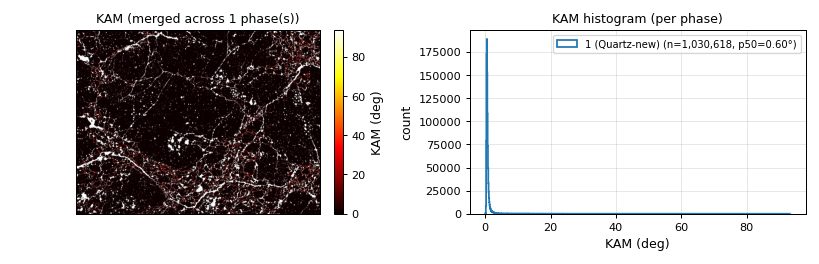

In [12]:
# ===== KAM over ALL phases (per-phase symmetry, merged map) =====
# `compute_kam_multiphase` iterates over every non-zero phase, looks up
# its Laue group, and runs KAM with that phase's mask.  Inter-phase pixel
# pairs are EXCLUDED automatically (different point groups -> no shared
# symmetry-reduced disorientation).  Phases without a Laue mapping are
# skipped with a warning instead of crashing the cell.

kam_map, kam_per_phase = kam.compute_kam_multiphase(
    ebsd, kernel=1, degrees=True, use_numba=True, verbose=True,
)

# ---- Plot: merged KAM + per-phase histograms ----
import matplotlib.pyplot as plt
n_phases_with_kam = len(kam_per_phase)
fig, axes = plt.subplots(1, 2, figsize=(13.0 * FIG_SCALE, 4.2 * FIG_SCALE))

vmax = float(np.nanpercentile(kam_map, 100)) if np.isfinite(kam_map).any() else 1.0
im = axes[0].imshow(kam_map, cmap='hot', vmin=0, vmax=vmax,
                     origin='upper', aspect='equal')
plt.colorbar(im, ax=axes[0], label='KAM (deg)', fraction=0.046, pad=0.04)
axes[0].set(title=f'KAM (merged across {n_phases_with_kam} phase(s))',
             xticks=[], yticks=[])

# Per-phase histograms (overlaid)
hist_max = float(np.nanpercentile(kam_map, 100)) if np.isfinite(kam_map).any() else 1.0
for pid, info in kam_per_phase.items():
    vals = info['kam'][np.isfinite(info['kam'])]
    axes[1].hist(vals.ravel(), bins=1000, range=(0, hist_max),
                  histtype='step', linewidth=1.4,
                  label=f"{info['name']} (n={info['n_pixels']:,}, "
                        f"p50={info['p50_deg']:.2f}°)")
axes[1].set(xlabel='KAM (deg)', ylabel='count',
             title=f'KAM histogram (per phase)')
if kam_per_phase:
    axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Insert as a new cell right after cell 10 (KAM cell)
import importlib, wtmm_ebsd.kam, wtmm_ebsd.grains, wtmm_ebsd.symmetry
importlib.reload(wtmm_ebsd.symmetry)
importlib.reload(wtmm_ebsd.grains)
importlib.reload(wtmm_ebsd.kam)
from wtmm_ebsd.symmetry import (
    is_alpha_quartz_phase, get_phase_symmetry, orix_class_name, phase_label,
)
from wtmm_ebsd.grains import _phase_symmetry_set
import numpy as np

print('Phases present:', sorted(int(p) for p in np.unique(ebsd['phase']) if p > 0))
print('phases meta:', ebsd['meta'].get('phases', {}))
print()
for pid in sorted(int(p) for p in np.unique(ebsd['phase']) if p > 0):
    sym = get_phase_symmetry(ebsd, pid)
    print(f'phase {phase_label(ebsd, pid)}:')
    print(f'  Laue class:           {orix_class_name(sym)}')
    print(f'  is_alpha_quartz:      {is_alpha_quartz_phase(ebsd, pid)}')
    sym_q, sym_name, dauph = _phase_symmetry_set(ebsd, pid, dauphine_aware=True)
    print(f'  sym_q after extend:   {sym_q.shape}   (24,4) means Dauphine-extended')
    print(f'  dauphine applied?     {dauph}')

# Now re-run KAM with verbose=True and look for "(Dauphine-extended)" tag
print('\n=== fresh KAM (verbose) ===')
kam_map_test, kpp = wtmm_ebsd.kam.compute_kam_multiphase(
    ebsd, kernel=1, degrees=True, verbose=True,
)
for pid, info in kpp.items():
    print(f'phase {pid}: dauphine_extended = {info.get("dauphine_extended", "?")}')

Phases present: [1]
phases meta: {1: ['4.91300010681152;4.91300010681152;5.50400018692017', '90;90;120', 'Quartz-new', '7', '152']}

phase 1 (Quartz-new):
  Laue class:           D3d
  is_alpha_quartz:      True
  sym_q after extend:   (24, 4)   (24,4) means Dauphine-extended
  dauphine applied?     True

=== fresh KAM (verbose) ===
  KAM phase 1 (Quartz-new) (Dauphine-extended): 1,030,618 pixels, p50=0.598°, p95=3.570°
phase 1: dauphine_extended = True


### Lebyodkin Mode A — raw-KAM box-counting MF

Direct comparison to Lebyodkin et al. 2024 (Acta Materialia).

  D(0) = 2.024   (capacity)
  D(1) = 1.967   (information, via -slope of Z_info)
  alpha range = [1.410, 2.055]
  f(alpha) max = 2.024


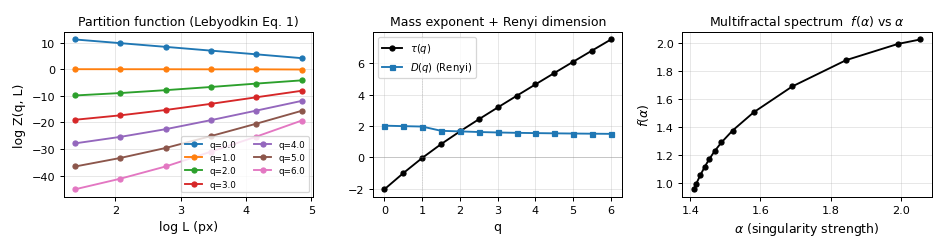

In [14]:
q_grid = np.arange(0.0, 6.01, 0.5)
lbk = kam.lebyodkin_spectrum(np.where(np.isfinite(kam_map), kam_map, 0.0),
                              q_grid, min_box_px=4, n_octaves=5)
print(f'  D(0) = {lbk["D_q"][np.argmin(np.abs(lbk["q"]))]:.3f}   (capacity)')
print(f'  D(1) = {lbk["D_q"][np.argmin(np.abs(lbk["q"] - 1.0))]:.3f}   (information, via -slope of Z_info)')
print(f'  alpha range = [{lbk["alpha"].min():.3f}, {lbk["alpha"].max():.3f}]')
print(f'  f(alpha) max = {lbk["f"].max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(15.0 * FIG_SCALE, 4.0 * FIG_SCALE))

# Panel 1: log Z(q, L) vs log L for a few q values
for qi, q in enumerate(q_grid[::2]):
    axes[0].plot(np.log(lbk["ls"]), lbk["log_Z"][2*qi], "o-", ms=4,
                 label=f"q={q:.1f}")
axes[0].set(xlabel="log L (px)", ylabel="log Z(q, L)",
            title="Partition function (Lebyodkin Eq. 1)")
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

# Panel 2: tau(q) and D(q) -- D(q) is now smooth thanks to information-aux
# fix at q=1 + linear bridge in |q-1| < 0.5.
axes[1].plot(lbk["q"], lbk["tau"], "o-", color="black", ms=4, label=r"$\tau(q)$")
axes[1].plot(lbk["q"], lbk["D_q"], "s-", color="C0",   ms=4, label=r"$D(q)$ (Renyi)")
axes[1].axhline(0, color="gray", lw=0.5, alpha=0.5)
axes[1].axvline(1.0, color="gray", lw=0.5, alpha=0.5, ls=":")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set(xlabel="q", title="Mass exponent + Renyi dimension")

# Panel 3: f(alpha) vs alpha (Halsey-Procaccia notation; same curve as
# the WTMM "D(h) vs h" but using physics-canonical names).
axes[2].plot(lbk["alpha"], lbk["f"], "o-", color="black", ms=4)
axes[2].set(xlabel=r"$\alpha$ (singularity strength)",
            ylabel=r"$f(\alpha)$",
            title=r"Multifractal spectrum  $f(\alpha)$ vs $\alpha$")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 4. Grain identification + smart fill

Vectorized `connected_components`-based segmentation (≈10–50×
faster than v1's Union-Find), with optional Dauphine-aware
extension for alpha-quartz.

  Phase 1 (Quartz-new): sym='D3d', Dauphine extension=True
Raw: 14969 grains total, 2767 >= 10 px (median 1 px)

Smart fill (cluster-classified Voronoi):
  Engulfed (one large neighbour): 6944 clusters (12,710 px)  -> dissolved
  Between (2+ large neighbours):  1796 clusters (6,121 px)  -> dissolved (Voronoi-split)
  Isolated (no large neighbours): 892 clusters (1,305 px)  -> kept
  Filled 116,081 unindexed pixels (Voronoi)
  Active grains: 3804 (2779 >= 10 px, 1025 smaller)
  Total pixels filled: 134,912 / 1,146,699 (11.77%)

Four-color theorem coloring: raw used 5, post-fill used 5


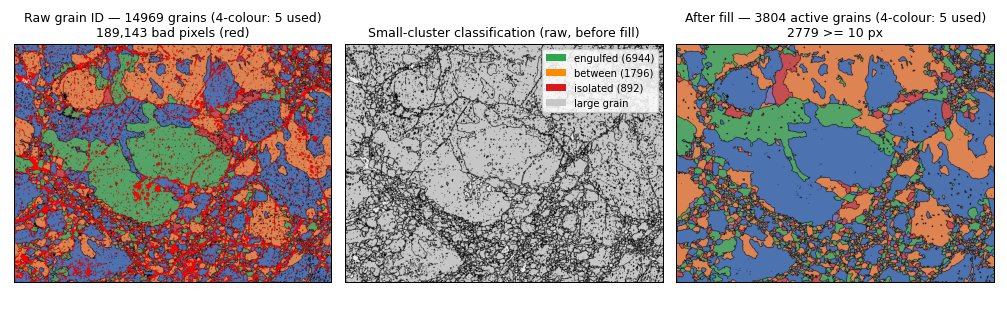

In [15]:
# ===== Grain identification + smart fill (with 4-color diagnostic viz) =====
# Symmetry-aware adjacency flood-fill (Dauphine-extended for quartz),
# then small-cluster classification (engulfed/between/isolated) and
# Voronoi-style fill of unindexed pixels.
#
# Diagnostic 3-panel viz uses a 4-color-theorem coloring of the grain
# adjacency graph (Welsh-Powell greedy) so neighbouring grains never share
# a color.  No more rainbow chaos.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.ndimage import label as ndi_label

# ---- parameters (mirror v1 cell 12) ----
GRAIN_THETA_DEG  = 7.0    # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS = 10     # drop grains smaller than this
DAUPHINE_AWARE   = True   # quartz: extend D3 -> D6 by 180-deg-about-c

FILL_ORIENTATIONS      = True
FILL_MIN_DISSOLVE_SIZE = GRAIN_MIN_PIXELS
FILL_DISSOLVE_ENGULFED = True
FILL_DISSOLVE_BETWEEN  = True
FILL_DISSOLVE_ISOLATED = False
FILL_EDGE_PROTECT_MIN  = max(3, GRAIN_MIN_PIXELS // 3)
FILL_BC_THRESHOLD      = 50      # for diagnostic only

# ---- run grain ID ----
grain_id_raw = grains.identify_grains(
    ebsd, theta_c_deg=GRAIN_THETA_DEG,
    min_pixels=GRAIN_MIN_PIXELS,
    dauphine_aware=DAUPHINE_AWARE,
    verbose=True)
n_grains_raw = int(grain_id_raw.max())
sizes_raw = np.bincount(grain_id_raw.ravel())[1:]
n_big_raw = int((sizes_raw >= GRAIN_MIN_PIXELS).sum())
print(f'Raw: {n_grains_raw} grains total, {n_big_raw} >= {GRAIN_MIN_PIXELS} px '
      f'(median {int(np.median(sizes_raw)) if sizes_raw.size else 0} px)')

# ---- smart fill ----
fill = grains.fill_grain_aware(
    grain_id_raw, ebsd,
    min_dissolve=FILL_MIN_DISSOLVE_SIZE,
    edge_protect_min=FILL_EDGE_PROTECT_MIN,
    diss_engulfed=FILL_DISSOLVE_ENGULFED,
    diss_between=FILL_DISSOLVE_BETWEEN,
    diss_isolated=FILL_DISSOLVE_ISOLATED) if FILL_ORIENTATIONS else None

if fill is not None:
    grain_id   = fill.grain_id
    was_filled = fill.was_filled
    classification = fill.classification
    cnt = fill.counts
    sizes_after = np.bincount(grain_id.ravel())[1:]
    nonzero_after = sizes_after[sizes_after > 0]
    n_active = len(nonzero_after)
    n_big_after = int((nonzero_after >= GRAIN_MIN_PIXELS).sum())
    n_small_remaining = int((nonzero_after < GRAIN_MIN_PIXELS).sum())
    print(f'\nSmart fill (cluster-classified Voronoi):')
    print(f'  Engulfed (one large neighbour): {cnt["engulfed"]} clusters '
          f'({cnt["engulfed_pix"]:,} px)  '
          f'{"-> dissolved" if FILL_DISSOLVE_ENGULFED else "-> kept"}')
    print(f'  Between (2+ large neighbours):  {cnt["between"]} clusters '
          f'({cnt["between_pix"]:,} px)  '
          f'{"-> dissolved (Voronoi-split)" if FILL_DISSOLVE_BETWEEN else "-> kept"}')
    print(f'  Isolated (no large neighbours): {cnt["isolated"]} clusters '
          f'({cnt["isolated_pix"]:,} px)  '
          f'{"-> dissolved" if FILL_DISSOLVE_ISOLATED else "-> kept"}')
    print(f'  Filled {cnt["holes_pix"]:,} unindexed pixels (Voronoi)')
    print(f'  Active grains: {n_active} ({n_big_after} >= {GRAIN_MIN_PIXELS} px, '
          f'{n_small_remaining} smaller)')
    print(f'  Total pixels filled: {int(was_filled.sum()):,} / {grain_id.size:,} '
          f'({100*was_filled.sum()/grain_id.size:.2f}%)')
else:
    grain_id = grain_id_raw
    was_filled = np.zeros_like(grain_id, dtype=bool)
    classification = {}
    cnt = {'engulfed': 0, 'between': 0, 'isolated': 0,
           'engulfed_pix': 0, 'between_pix': 0, 'isolated_pix': 0,
           'holes_pix': 0}
    n_active = int((np.bincount(grain_id.ravel())[1:] > 0).sum())
    n_big_after = n_big_raw

# ---- 4-color theorem coloring of grain adjacency ----
color_map_raw,  n_col_raw  = grains.four_color_grains(grain_id_raw)
color_map_post, n_col_post = grains.four_color_grains(grain_id)
print(f'\nFour-color theorem coloring: '
      f'raw used {n_col_raw}, post-fill used {n_col_post}')

# Tableau-style 4-color palette (extends to 6 if greedy needs it)
FOUR_COLORS = [
    '#4C72B0',  # blue
    '#DD8452',  # orange
    '#55A467',  # green
    '#C44E52',  # red
    '#8172B2',  # purple (overflow color 5)
    '#937860',  # brown  (overflow color 6)
]


def _color_grains(grain_id, color_map, palette=FOUR_COLORS):
    """Map (ny, nx) grain ids -> (ny, nx, 3) RGB using 4-color palette."""
    from matplotlib.colors import to_rgb
    n_pal = len(palette)
    # color index: -1 (background) -> light gray; >=0 -> palette[c % n_pal]
    rgb = np.full(grain_id.shape + (3,), 0.92, dtype=np.float32)
    for c in range(int(color_map.max()) + 1):
        mask = color_map[grain_id] == c
        rgb[mask] = to_rgb(palette[c % n_pal])
    return rgb


def _gb_overlay(gid):
    """Per-pixel grain-boundary mask: True where neighbour grain_id differs."""
    b = np.zeros_like(gid, dtype=bool)
    diff_r = gid[:, :-1] != gid[:, 1:]
    b[:, :-1] |= diff_r; b[:, 1:] |= diff_r
    diff_d = gid[:-1, :] != gid[1:, :]
    b[:-1, :] |= diff_d; b[1:, :] |= diff_d
    return b


grain_rgb_raw  = _color_grains(grain_id_raw,  color_map_raw)
grain_rgb_post = _color_grains(grain_id,      color_map_post)
gb_raw  = _gb_overlay(grain_id_raw)
gb_post = _gb_overlay(grain_id)

# Bad-pixel mask from BC + MAD + unindexed phase
bad_pix = (ebsd['phase'] == 0)
if ebsd.get('bc')  is not None: bad_pix |= (ebsd['bc']  < FILL_BC_THRESHOLD)
if ebsd.get('mad') is not None: bad_pix |= (ebsd['mad'] > 2.0)

# ---- 3-panel diagnostic figure ----
fig, axes = plt.subplots(1, 3, figsize=(16.0 * FIG_SCALE, 5.2 * FIG_SCALE))

# Panel A: raw grain map + GBs + bad pixels
ax = axes[0]
disp = grain_rgb_raw.copy()
disp[gb_raw] = [0, 0, 0]
disp[bad_pix] = [1, 0, 0]
ax.imshow(disp, origin='upper', aspect='equal')
ax.set(title=f'Raw grain ID — {n_grains_raw} grains '
              f'(4-colour: {n_col_raw} used)\n'
              f'{int(bad_pix.sum()):,} bad pixels (red)',
       xticks=[], yticks=[])

# Panel B: small-cluster classification
ax = axes[1]
cls_disp = np.full(grain_id_raw.shape + (3,), 0.92, dtype=np.float32)
cls_disp[grain_id_raw > 0] = [0.78, 0.78, 0.78]
color_by_kind = {
    'engulfed': [0.18, 0.65, 0.30],   # green
    'between':  [1.00, 0.55, 0.00],   # orange
    'isolated': [0.85, 0.10, 0.10],   # red
}
if classification:
    sizes_full = np.bincount(grain_id_raw.ravel())
    small_mask = np.zeros_like(grain_id_raw, dtype=bool)
    for gid in range(1, n_grains_raw + 1):
        if 0 < int(sizes_full[gid]) < FILL_MIN_DISSOLVE_SIZE:
            small_mask |= (grain_id_raw == gid)
    if small_mask.any():
        clab, _ = ndi_label(small_mask, structure=np.ones((3, 3)))
        for lab, info in classification.items():
            cls_disp[clab == lab] = color_by_kind[info['kind']]
cls_disp[gb_raw] = [0, 0, 0]
ax.imshow(cls_disp, origin='upper', aspect='equal')
legend_elems = [
    Patch(facecolor=color_by_kind['engulfed'], label=f'engulfed ({cnt["engulfed"]})'),
    Patch(facecolor=color_by_kind['between'],  label=f'between ({cnt["between"]})'),
    Patch(facecolor=color_by_kind['isolated'], label=f'isolated ({cnt["isolated"]})'),
    Patch(facecolor=[0.78, 0.78, 0.78], label='large grain'),
]
ax.legend(handles=legend_elems, loc='upper right',
          fontsize=8, framealpha=0.85)
ax.set(title='Small-cluster classification (raw, before fill)',
       xticks=[], yticks=[])

# Panel C: post-fill grain map + GBs (4-color)
ax = axes[2]
disp = grain_rgb_post.copy()
disp[gb_post] = [0, 0, 0]
ax.imshow(disp, origin='upper', aspect='equal')
ax.set(title=f'After fill — {n_active} active grains '
              f'(4-colour: {n_col_post} used)\n'
              f'{n_big_after} >= {GRAIN_MIN_PIXELS} px',
       xticks=[], yticks=[])

fig.tight_layout(); plt.show()


## 5. Per-grain Karcher demean (sample frame + crystal frame)

`compute_log_orientation_per_grain` builds `combined_log` (crystal
frame) AND `combined_log_sample` (sample frame) in one pass.  All
downstream Pantleon work uses the sample-frame copy.

  Processing 2779 grains (>= 10 px); skipping 1025 smaller grains (total grain IDs: 3804)
    Phase 1 (Quartz-new): sym='D3d', Dauphine=True
  Demean done: 2779/3804 grains kept, 1025 skipped (size < 10 px); covers 1,145,276/1,146,699 indexed pixels (99.9%)
  grains processed: 2779
  FZ-warn flags:    0


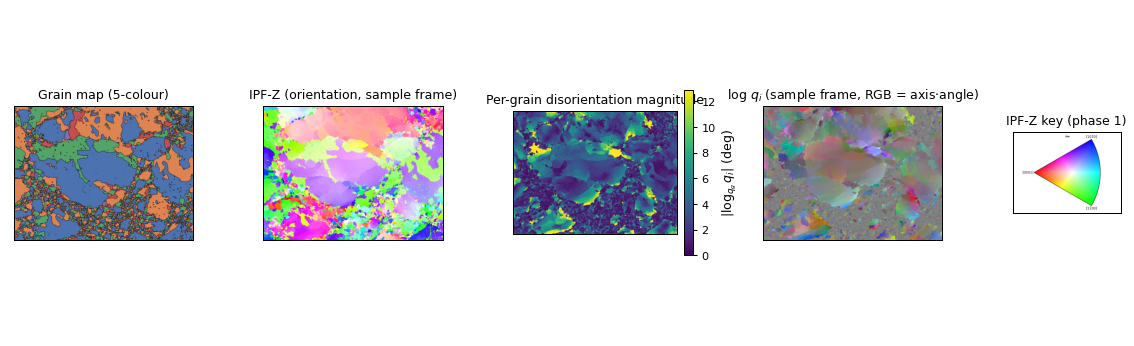

Grains flagged near FZ boundary: 0/2779


In [22]:
# ===== Per-grain Karcher demean + log orientation, with IPF-Z & log-field viz =====
# Demean is in the package; this cell adds the v1-style 4-panel diagnostic
# figure with a proper IPF-Z map (orix), per-grain Karcher mean check, log-
# orientation magnitude, and a 4-coloured grain map for context.

import numpy as np
import matplotlib.pyplot as plt
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d
from wtmm_ebsd.symmetry import get_phase_symmetry
from wtmm_ebsd.grains import four_color_grains

demean_result = demean.compute_log_orientation_per_grain(
    ebsd, grain_id,
    min_pixels=10, dauphine_aware=True, fz_warn_frac=0.7,
    verbose=True)
combined_log_sample = demean_result.combined_log_sample
combined_log        = demean_result.combined_log
combined_mask       = demean_result.combined_mask
grain_info          = demean_result.grain_info

print(f'  grains processed: {len(grain_info)}')
print(f'  FZ-warn flags:    {demean_result.n_fz_warn}')

# ---- IPF-Z map (per-phase, via orix) ----
ny, nx = ebsd['euler1'].shape
ipf_rgb = np.zeros((ny, nx, 3), dtype=np.float32)
phase_arr = ebsd['phase']
ipf_keys_by_phase = {}
for pid in np.unique(phase_arr):
    pid = int(pid)
    if pid == 0:
        continue
    sym = get_phase_symmetry(ebsd, phase_id=pid)
    if sym is None:
        continue
    rgb_p, mask_p = ipf.ipf_colors_for_phase(ebsd, phase_id=pid,
                                              sample_dir='Z')
    ipf_rgb[mask_p] = rgb_p[mask_p]
    ipf_keys_by_phase[pid] = IPFColorKeyTSL(sym, direction=Vector3d.zvector())

# ---- log-orientation magnitude (deg) ----
mag_deg = np.full((ny, nx), np.nan, dtype=np.float32)
m = combined_mask
mag_deg[m] = np.rad2deg(np.linalg.norm(combined_log_sample[m], axis=-1))
mag_p98 = float(np.nanpercentile(mag_deg, 98)) if np.isfinite(mag_deg).any() else 1.0

# ---- 4-coloured grain map for context ----
color_map, n_col = four_color_grains(grain_id)
FOUR_COLORS = ['#4C72B0', '#DD8452', '#55A467', '#C44E52',
               '#8172B2', '#937860']
from matplotlib.colors import to_rgb
grain_rgb = np.full((ny, nx, 3), 0.92, dtype=np.float32)
for c in range(int(color_map.max()) + 1):
    grain_rgb[color_map[grain_id] == c] = to_rgb(FOUR_COLORS[c % len(FOUR_COLORS)])
gb = np.zeros_like(grain_id, dtype=bool)
gb[:, :-1] |= grain_id[:, :-1] != grain_id[:, 1:]
gb[:,  1:] |= grain_id[:, :-1] != grain_id[:, 1:]
gb[:-1, :] |= grain_id[:-1, :] != grain_id[1:, :]
gb[ 1:, :] |= grain_id[:-1, :] != grain_id[1:, :]
grain_rgb[gb] = [0, 0, 0]

# ---- 4-panel figure with IPF-Z legend ----
fig = plt.figure(figsize=(18.0 * FIG_SCALE, 5.5 * FIG_SCALE))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.6])
ax_grain = fig.add_subplot(gs[0, 0])
ax_ipf   = fig.add_subplot(gs[0, 1])
ax_mag   = fig.add_subplot(gs[0, 2])
ax_log   = fig.add_subplot(gs[0, 3])
ax_key   = fig.add_subplot(gs[0, 4])

ax_grain.imshow(grain_rgb, origin='upper', aspect='equal')
ax_grain.set(title=f'Grain map ({n_col}-colour)', xticks=[], yticks=[])

ax_ipf.imshow(np.clip(ipf_rgb, 0, 1), origin='upper', aspect='equal')
ax_ipf.set(title='IPF-Z (orientation, sample frame)', xticks=[], yticks=[])

im = ax_mag.imshow(mag_deg, cmap='viridis', vmin=0, vmax=mag_p98,
                    origin='upper', aspect='equal')
plt.colorbar(im, ax=ax_mag, label=r'$|\log_{q_g} q_i|$ (deg)',
             fraction=0.046, pad=0.04)
ax_mag.set(title='Per-grain disorientation magnitude',
           xticks=[], yticks=[])

# Per-grain log-orientation as RGB (axis-angle: |v| = angle, axis = chroma)
# We map the LOG VECTOR (axis * angle) directly: clip to a sane angular
# range and normalize each channel symmetrically so 0 -> mid-gray.
log_view = combined_log_sample.copy()
log_view[~combined_mask] = 0
ang_clip = np.deg2rad(mag_p98 if mag_p98 > 0 else 1.0)
log_view = np.clip(log_view, -ang_clip, ang_clip) / (2 * ang_clip) + 0.5
log_view[~combined_mask] = 0
ax_log.imshow(log_view, origin='upper', aspect='equal')
ax_log.set(title=r'$\log\,q_i$ (sample frame, RGB = axis$\cdot$angle)',
           xticks=[], yticks=[])

# IPF-Z color key (use the dominant phase's symmetry)
if ipf_keys_by_phase:
    dom_phase = max(ipf_keys_by_phase.keys(),
                     key=lambda k: int((phase_arr == k).sum()))
    key_obj = ipf_keys_by_phase[dom_phase]
    # IPFColorKeyTSL.plot returns its own figure; capture and steal the artist
    try:
        key_fig = key_obj.plot(return_figure=True)
        key_ax_src = key_fig.axes[0]
        # We can't easily transplant matplotlib axes; instead rasterize and
        # re-display in our slot.
        key_fig.canvas.draw()
        img = np.asarray(key_fig.canvas.buffer_rgba())
        plt.close(key_fig)
        ax_key.imshow(img, aspect='equal')
        ax_key.set(title=f'IPF-Z key (phase {dom_phase})',
                    xticks=[], yticks=[])
    except Exception as exc:
        ax_key.text(0.5, 0.5, f'IPF key error:\n{exc}',
                     ha='center', va='center', transform=ax_key.transAxes)
        ax_key.axis('off')
else:
    ax_key.axis('off')

fig.tight_layout(); plt.show()

# FZ-boundary-warning grains
n_warn = sum(1 for g in grain_info.values() if g.fz_warn)
print(f'Grains flagged near FZ boundary: {n_warn}/{len(grain_info)}')


### Per-phase Karcher demean (alternative reference frame)

One Karcher mean per phase (not per grain).  Field is smooth
within grains but has REAL physical jumps at grain boundaries
(reflecting actual misorientation).  Used to study the full
polycrystal orientation map including grain-network structure.


In [ ]:
# ===== Per-PHASE Karcher demean (one mean per phase) =====
# Output shape mirrors compute_log_orientation_per_grain so it drops into
# the same alpha_jacobian_twtmm pipeline.  Cell 18 will run TWTMM on both
# variants and register `_phase`-suffixed modes for the per-phase one.

phase_demean = demean.compute_log_orientation_per_phase(
    ebsd, min_pixels=100, dauphine_aware=True, fz_warn_frac=0.7,
    verbose=True)
combined_log_phase        = phase_demean.combined_log
combined_log_phase_sample = phase_demean.combined_log_sample
combined_phase_mask       = phase_demean.combined_mask
phase_info                = phase_demean.phase_info
print(f'  per-phase demean: {len(phase_info)} phase(s) processed')
from wtmm_ebsd.symmetry import phase_label
for pid, pi in phase_info.items():
    print(f'    phase {phase_label(ebsd, pid)}: {pi.n_pixels:,} pixels, '
          f'theta_p99={pi.theta_p99_deg:.1f}deg (FZ ceil {pi.fz_max_deg:.1f}deg)')


## 6. CPO c-axis attractor + θ_attractor field

In [17]:
# ===== CPO c-axis attractor + IPF-Z map + stereonet (per-phase, per-grain) =====
# Skips triclinic phases (Ci, C1) where c-axis has no symmetry meaning.
# For phases with a meaningful c-axis (trig/hex/tet symmetry-strict; ortho/
# monoclinic conventional), shows a per-grain stereonet — one point per
# grain, not per pixel.

import numpy as np
import matplotlib.pyplot as plt
from orix.plot import IPFColorKeyTSL
from orix.vector import Vector3d
from wtmm_ebsd.symmetry import (
    get_phase_symmetry, orix_class_name, phase_label,
)
from wtmm_ebsd.orientation import euler_to_quat, rotate_vec_by_quat

# ---- Which phases have a meaningful c-axis CPO target? ----
# Triclinic Ci / C1: c-axis is just one of three lattice directions, no symmetry
# meaning -> SKIP.  Everything else: c-axis is either a symmetry axis (trig /
# hex / tet) or a conventional fabric direction (orthorhombic [001] for olivine;
# monoclinic c for micas/orthoclase, perpendicular to (001) cleavage in micas).
_C_AXIS_TRIVIAL = {'C1', 'Ci'}

def _c_axis_meaningful(sym_name: str) -> tuple[bool, str]:
    """Return (is_meaningful, label_for_status)."""
    if sym_name in _C_AXIS_TRIVIAL:
        return False, 'triclinic — c-axis is arbitrary, skipped'
    if sym_name in ('C2', 'Cs', 'C2h', 'C2v', 'D2', 'D2h'):
        return True, f'{sym_name} — c is conventional (not a symmetry axis)'
    return True, f'{sym_name} — c is a symmetry axis'

# ---- Compute attractors only for phases that pass the c-axis check ----
phase_arr = ebsd['phase']
phase_status: dict[int, dict] = {}
for pid in [int(p) for p in np.unique(phase_arr) if int(p) > 0]:
    sym = get_phase_symmetry(ebsd, phase_id=pid)
    sym_name = orix_class_name(sym) if sym is not None else 'C1'
    is_ok, status_str = _c_axis_meaningful(sym_name)
    phase_status[pid] = {'sym': sym, 'sym_name': sym_name,
                          'meaningful': is_ok, 'status': status_str}

# Only run compute_cpo_attractor on phases that pass the c-axis check
_kept_phases = [pid for pid, st in phase_status.items() if st['meaningful']]

theta_attractor_deg, attractors = cpo.compute_cpo_attractor(
    ebsd, axis="c", min_pixels=100,
    method="kde_mode", kde_kappa=50.0,
    weight_by="grain_uniform",
    grain_id=grain_id,
)
# Drop any attractor for a triclinic phase (compute_cpo_attractor doesn't
# know about the c-axis-meaningful filter, so we filter the dict here).
attractors = {pid: c for pid, c in attractors.items() if pid in _kept_phases}

per_grain_c = cpo.compute_per_grain_cpo(grain_info, axis="c")

print(f'  per-phase status:')
for pid, st in phase_status.items():
    name = phase_label(ebsd, pid)
    if st['meaningful']:
        c = attractors.get(pid)
        if c is not None:
            print(f'    phase {name}: c_attr = ({c[0]:+.3f}, {c[1]:+.3f}, {c[2]:+.3f})  [{st["status"]}]')
        else:
            print(f'    phase {name}: too few pixels  [{st["status"]}]')
    else:
        print(f'    phase {name}: SKIPPED  [{st["status"]}]')
print(f'  per-grain attractors (all phases): {len(per_grain_c)} grains')

# ---- IPF-Z map (per-phase) ----
ny, nx = ebsd['euler1'].shape
ipf_rgb = np.zeros((ny, nx, 3), dtype=np.float32)
ipf_keys = {}
for pid in np.unique(phase_arr):
    pid = int(pid)
    if pid == 0: continue
    sym = phase_status.get(pid, {}).get('sym')
    if sym is None: continue
    rgb_p, mask_p = ipf.ipf_colors_for_phase(ebsd, phase_id=pid, sample_dir='Z')
    ipf_rgb[mask_p] = rgb_p[mask_p]
    ipf_keys[pid] = IPFColorKeyTSL(sym, direction=Vector3d.zvector())
dom_phase = (max(_kept_phases, key=lambda k: int((phase_arr == k).sum()))
             if _kept_phases else None)

# ---- 4-panel: IPF-Z + θ map + θ normalised + IPF key ----
fig = plt.figure(figsize=(16.0 * FIG_SCALE, 5.5 * FIG_SCALE))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.55])
ax_ipf  = fig.add_subplot(gs[0, 0])
ax_th   = fig.add_subplot(gs[0, 1])
ax_dev  = fig.add_subplot(gs[0, 2])
ax_key  = fig.add_subplot(gs[0, 3])

ax_ipf.imshow(np.clip(ipf_rgb, 0, 1), origin='upper', aspect='equal')
ax_ipf.set(title='IPF-Z (full orientation)', xticks=[], yticks=[])

th_p99 = float(np.nanpercentile(theta_attractor_deg, 99)) \
         if np.isfinite(theta_attractor_deg).any() else 1.0
im = ax_th.imshow(theta_attractor_deg, cmap='twilight',
                   vmin=0, vmax=th_p99, origin='upper', aspect='equal')
plt.colorbar(im, ax=ax_th, label=r'$\theta_{attractor}$ (deg)',
             fraction=0.046, pad=0.04)
ax_th.set(title='CPO c-axis deviation from mode',
          xticks=[], yticks=[])

ax_dev.imshow(np.clip(theta_attractor_deg / max(th_p99, 1.0), 0, 1),
              cmap='magma', origin='upper', aspect='equal', vmin=0, vmax=1)
ax_dev.set(title=fr'normalised $\theta_{{attractor}}$ (max {th_p99:.1f}°)',
           xticks=[], yticks=[])

if dom_phase is not None:
    try:
        key_fig = ipf_keys[dom_phase].plot(return_figure=True)
        key_fig.canvas.draw()
        img = np.asarray(key_fig.canvas.buffer_rgba())
        plt.close(key_fig)
        ax_key.imshow(img, aspect='equal')
        ax_key.set(title=f'IPF-Z key ({phase_label(ebsd, dom_phase)})',
                    xticks=[], yticks=[])
    except Exception as exc:
        ax_key.text(0.5, 0.5, f'IPF key error:\n{exc}',
                     ha='center', va='center', transform=ax_key.transAxes)
        ax_key.axis('off')
else:
    ax_key.axis('off')

fig.tight_layout(); plt.show()

# ---- Build per-phase per-grain c-axis arrays ----
# `per_grain_c` is global (gid -> c).  We need to split by phase using
# `grain_info[gid].phase_id`.
per_phase_per_grain_c: dict[int, list] = {pid: [] for pid in _kept_phases}
for gid, c in per_grain_c.items():
    info = grain_info.get(int(gid))
    if info is None: continue
    pid = int(info.phase_id)
    if pid in per_phase_per_grain_c:
        per_phase_per_grain_c[pid].append(c)
for pid in list(per_phase_per_grain_c.keys()):
    per_phase_per_grain_c[pid] = (np.asarray(per_phase_per_grain_c[pid])
                                    if per_phase_per_grain_c[pid] else
                                    np.zeros((0, 3)))

# ---- Per-phase stereonets — one panel per c-axis-meaningful phase ----
phases_for_plot = [pid for pid in _kept_phases
                    if pid in attractors and len(per_phase_per_grain_c[pid]) > 0]
if not phases_for_plot:
    print('No phases with both an attractor and per-grain data — '
           'no per-phase stereonets to draw.')
else:
    n_phases = len(phases_for_plot)
    cols = min(3, n_phases)
    rows = (n_phases + cols - 1) // cols
    fig_st, axes_st = plt.subplots(rows, cols,
                                     figsize=(4.5 * cols * FIG_SCALE,
                                              4.5 * rows * FIG_SCALE),
                                     squeeze=False)
    for ax, pid in zip(axes_st.flatten(), phases_for_plot):
        c_grains = per_phase_per_grain_c[pid]
        attr = attractors[pid]
        # Fold to lower hemisphere (z <= 0)
        c_low = c_grains * np.where(c_grains[:, 2:3] <= 0.0, 1.0, -1.0)
        a_low = attr.copy()
        if a_low[2] > 0: a_low = -a_low

        ax.plot(c_low[:, 0], c_low[:, 1], 'o',
                 color='tab:blue', ms=2.5, alpha=0.55,
                 markeredgecolor='none')
        ax.plot(a_low[0], a_low[1], '*', color='cyan', ms=14,
                 markeredgecolor='black', markeredgewidth=0.8,
                 label='attractor')
        th = np.linspace(0, 2 * np.pi, 200)
        ax.plot(np.cos(th), np.sin(th), 'k-', lw=1)
        # Sample-frame X/Y axis labels (EBSD scan x to right, y up)
        for label, (lx, ly) in [('Y',  (0, 1.08)),  ('X',  (1.08, 0)),
                                  ('-Y', (0, -1.08)), ('-X', (-1.08, 0))]:
            ax.text(lx, ly, label, ha='center', va='center',
                     fontsize=10, fontweight='bold')
        ax.set_aspect('equal'); ax.set_xlim(-1.18, 1.18); ax.set_ylim(-1.18, 1.18)
        ax.set_xticks([]); ax.set_yticks([])
        sym_name = phase_status[pid]['sym_name']
        ax.set_title(f"{phase_label(ebsd, pid)}  [{sym_name}]\n"
                      f"{len(c_grains):,} grains",
                      fontsize=10)
        ax.legend(loc='upper right', fontsize=7, framealpha=0.85)
    # Hide unused panels
    for ax in axes_st.flatten()[n_phases:]:
        ax.set_visible(False)
    fig_st.suptitle('Per-grain c-axes (lower-hemisphere Lambert; one point per grain)',
                     fontsize=11, y=1.01)
    fig_st.tight_layout()
    plt.show()

# ---- Pixel-density stereonet for the dominant phase only (KDE shape) ----
# Useful as a complementary view: the per-grain plot shows discrete points
# (sampling), the density plot shows the smooth fabric distribution.
if dom_phase is not None and dom_phase in attractors:
    e1_rad = np.deg2rad(ebsd['euler1']).ravel()
    e2_rad = np.deg2rad(ebsd['euler2']).ravel()
    e3_rad = np.deg2rad(ebsd['euler3']).ravel()
    q = euler_to_quat(e1_rad, e2_rad, e3_rad)
    c_sample_all = rotate_vec_by_quat(
        q, np.broadcast_to([0.0, 0.0, 1.0], q.shape[:-1] + (3,)))
    c_sample_all /= np.linalg.norm(c_sample_all, axis=-1, keepdims=True)

    bad_pix = (phase_arr.ravel() == 0)
    if ebsd.get('bc') is not None:
        bad_pix = bad_pix | (ebsd['bc'].ravel() < 50)
    if ebsd.get('mad') is not None:
        bad_pix = bad_pix | (ebsd['mad'].ravel() > 2.0)
    pmask = (phase_arr.ravel() == dom_phase) & ~bad_pix
    c_phase = c_sample_all[pmask]
    gid_phase = grain_id.ravel()[pmask]
    sizes = np.bincount(gid_phase)
    sizes_safe = np.maximum(sizes, 1)
    w_phase = np.where(gid_phase > 0, 1.0 / sizes_safe[gid_phase], 0.0)
    fig_kde = cpo.stereonet_density_plot(
        c_phase, attractor=attractors[dom_phase],
        weights=w_phase, n_grid=256, kde_kappa=50.0, cmap='inferno',
        title=f'c-axis density — {phase_label(ebsd, dom_phase)} (grain-uniform weights)')
    plt.show()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 2193 but size of corresponding boolean axis is 927

### Dauphine twin boundary detection (Papeschi 2019)

Quartz-only diagnostic: detect ≈60°-about-c misorientation pairs.
Three panels: all GBs / Dauphine pairs / overlap analysis.


In [ ]:
# ===== Dauphine twin boundary detection (Papeschi 2019 §3) =====
# Dauphine twins in alpha-quartz are 60° (or 180°) rotations about the
# c-axis [0001].  They are NOT a true crystal symmetry of D3, so they
# show up as "boundaries" in raw orientation maps even though the c-axis
# is invariant.  Detection: flag pixel pairs whose misorientation:
#   (a) is within ±angle_tol of angle_target_deg (60 by default), AND
#   (b) has its axis within c_axis_tol of [0001]
#
# These pairs are the Dauphine boundaries.  We visualise them next to the
# regular grain map for context.  Demean / TWTMM cells use the
# `dauphine_aware=True` flag to FOLD across these boundaries (treating
# Dauphine pairs as a single grain for Karcher mean).

import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd import papeschi
from wtmm_ebsd.symmetry import is_quartz_phase

# Only attempt detection if the dominant phase is alpha-quartz
_qz_phases = [int(p) for p in np.unique(ebsd['phase'])
              if int(p) > 0 and is_quartz_phase(ebsd, int(p))]
if not _qz_phases:
    print('No alpha-quartz phase detected — skipping Dauphine analysis.')
else:
    print(f'Dauphine boundary detection on phase(s): {_qz_phases}')

    DAUPH_ANGLE_TARGET = 60.0   # deg; Papeschi 2019 (180° also possible)
    DAUPH_ANGLE_TOL    = 5.0    # deg
    DAUPH_AXIS_TOL     = 10.0   # deg (offset from [0001])

    dauph_right, dauph_down = papeschi.detect_dauphine_boundaries(
        ebsd,
        angle_target_deg=DAUPH_ANGLE_TARGET,
        angle_tol_deg=DAUPH_ANGLE_TOL,
        c_axis_tol_deg=DAUPH_AXIS_TOL,
    )

    # Total Dauphine boundary pixel count + length (assuming square pixels)
    n_dauph_h = int(dauph_right.sum())
    n_dauph_v = int(dauph_down.sum())
    total_dauph = n_dauph_h + n_dauph_v
    px_um_safe = float(px_um) if px_um else 1.0
    total_dauph_um = total_dauph * px_um_safe
    print(f'  Dauphine boundary segments: {n_dauph_h:,} horizontal + '
          f'{n_dauph_v:,} vertical = {total_dauph:,} total '
          f'({total_dauph_um:.1f} µm cumulative length)')

    # Build per-pixel "is on a Dauphine boundary" mask for visualisation
    ny, nx = ebsd['euler1'].shape
    dauph_mask = np.zeros((ny, nx), dtype=bool)
    dauph_mask[:, :-1] |= dauph_right
    dauph_mask[:,  1:] |= dauph_right
    dauph_mask[:-1, :] |= dauph_down
    dauph_mask[ 1:, :] |= dauph_down

    # All grain boundaries for comparison (where adjacent pixels have
    # different grain IDs)
    gb_mask = np.zeros((ny, nx), dtype=bool)
    gb_mask[:, :-1] |= grain_id[:, :-1] != grain_id[:, 1:]
    gb_mask[:,  1:] |= grain_id[:, :-1] != grain_id[:, 1:]
    gb_mask[:-1, :] |= grain_id[:-1, :] != grain_id[1:, :]
    gb_mask[ 1:, :] |= grain_id[:-1, :] != grain_id[1:, :]

    # Three-panel figure: GBs / Dauphine / overlap
    fig, axes = plt.subplots(1, 3, figsize=(18.0 * FIG_SCALE, 5.5 * FIG_SCALE), dpi=110)
    blank = np.full((ny, nx, 3), 0.92, dtype=np.float32)

    # Panel A: all grain boundaries
    img = blank.copy()
    img[gb_mask] = [0, 0, 0]
    axes[0].imshow(img, origin='upper', aspect='equal')
    axes[0].set(title=f'All grain boundaries ({int(gb_mask.sum()):,} px)',
                 xticks=[], yticks=[])

    # Panel B: Dauphine boundaries (red)
    img = blank.copy()
    img[gb_mask] = [0.65, 0.65, 0.65]    # other GBs in light gray
    img[dauph_mask] = [0.85, 0.10, 0.10]
    axes[1].imshow(img, origin='upper', aspect='equal')
    axes[1].set(title=f'Dauphine pairs ({int(dauph_mask.sum()):,} px, red)\n'
                       f'angle ≈ {DAUPH_ANGLE_TARGET}±{DAUPH_ANGLE_TOL}°, '
                       f'axis within {DAUPH_AXIS_TOL}° of [0001]',
                 xticks=[], yticks=[])

    # Panel C: overlap analysis — Dauphine pixels that ARE / AREN'T at GBs
    on_gb       = dauph_mask & gb_mask
    not_on_gb   = dauph_mask & ~gb_mask
    img = blank.copy()
    img[gb_mask] = [0.65, 0.65, 0.65]
    img[on_gb]     = [1.0, 0.55, 0.0]    # orange: Dauphine + GB (true twin pair)
    img[not_on_gb] = [0.0, 0.55, 1.0]    # blue:   Dauphine but no GB
                                          # (intra-grain, possibly Dauphine
                                          # already folded by smart fill)
    axes[2].imshow(img, origin='upper', aspect='equal')
    axes[2].set(title=f'Dauphine ∩ GB: {int(on_gb.sum()):,} px (orange)\n'
                       f'Dauphine \\ GB: {int(not_on_gb.sum()):,} px (blue)',
                 xticks=[], yticks=[])

    fig.suptitle('Dauphine twin boundary detection (Papeschi 2019)',
                 fontsize=11)
    fig.tight_layout(); plt.show()

    print('\nReading: orange = real Dauphine twin boundaries (where adjacent\n'
          'grains are 60°-about-c twins).  Blue = intra-grain Dauphine pairs\n'
          '(typical when smart-fill or dauphine_aware=True merged the twins\n'
          'into single grains).  Demean cells with dauphine_aware=True will\n'
          'fold these — no further action needed.')


## 7. Pantleon Nye tensor (Numba GB-aware grad, σ=1.5 px pre-smooth)

In [ ]:
kappa, gb_unsafe = nye.compute_kappa_2x3(
    combined_log_sample, grain_id,
    gaussian_sigma_px=1.5, gb_safe=True, use_numba=True)
alpha = nye.assemble_alpha_pantleon(kappa)
alpha[gb_unsafe] = 0.0
print(f'  alpha shape: {alpha.shape}')
print(f'  GB-unsafe pixels masked: {int(gb_unsafe.sum()):,}')


  alpha shape: (310, 414, 3, 3)
  GB-unsafe pixels masked: 3,163


## 7b. Scalar field gallery — multifractal targets

Each scalar field below can be fed independently into the scalar WTMM
pipeline (cell with "Scalar WTMM on …" further down).  They correspond
to the P1–P8 sections of Hobbs & Ord (2015) Vol. I, Ch. 9 & 13:

- `kam`             — KAM (Kernel Avg Misorientation, multi-phase) — Hobbs–Ord §13.8
- `gnd_frob`        — $\|\alpha\|_F$ — bulk Frobenius of Pantleon Nye tensor (P1, Ch 9)
- `gnd_sq`          — $\|\alpha\|^2$ — entropy production density (P4, Hobbs et al. 2011)
- `bc_damage`       — $1 - \text{BC}/\text{BC}_{\max}$ — band-contrast damage proxy (P2, Ch 10.4)
- `gb_distance`     — Euclidean distance to nearest grain boundary (P8, Ch 13)
- `theta_attractor` — CPO θ deviation from per-phase mode (computed in §6)

All fields are stashed in the `scalar_fields` dict.  The downstream
"Scalar WTMM" cell pulls them by name and registers them under
`svd_wtmm[<name>]` for the partition function, viewer, and publication
spectra to consume.

In [ ]:
# ===== Scalar field gallery + diagnostic figure =====
# All fields stash in `scalar_fields` dict.  Cell that runs scalar WTMM
# (further down) iterates over the dict and registers each as an SVD mode.

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt

# Normalisation: divide each field by its p99 (finite values) so the
# partition function stays in a sane numerical range.  D(h) is invariant
# under multiplicative scaling (the shift only affects c1, the spectrum
# location on the h-axis).  Set NORMALIZE = False to keep raw units.
NORMALIZE = True

scalar_fields:   dict[str, np.ndarray] = {}
field_meta:      dict[str, dict]       = {}
field_norm_p99:  dict[str, float]      = {}      # factor we divided by

def _normalise(name: str, f: np.ndarray) -> np.ndarray:
    if not NORMALIZE:
        field_norm_p99[name] = 1.0
        return f.astype(np.float32)
    finite = np.isfinite(f) & (f != 0)
    if not finite.any():
        field_norm_p99[name] = 1.0
        return f.astype(np.float32)
    p99 = float(np.nanpercentile(np.abs(f[finite]), 99))
    if p99 <= 0:
        field_norm_p99[name] = 1.0
        return f.astype(np.float32)
    field_norm_p99[name] = p99
    return (f / p99).astype(np.float32)

# 1. KAM (multi-phase, computed in §3 / cell 8)
if 'kam_map' in globals():
    f = np.where(np.isfinite(kam_map), kam_map, 0.0).astype(np.float32)
    scalar_fields['kam'] = _normalise('kam', f)
    vmax = float(np.nanpercentile(kam_map, 95)) if np.isfinite(kam_map).any() else 1.0
    field_meta['kam'] = {'label': 'KAM (deg)', 'cmap': 'hot', 'vmin': 0, 'vmax': vmax}

# 2 & 3. Frobenius norm and squared norm of Nye α (built in §7 / cell 22)
if 'alpha' in globals() and alpha is not None:
    a = np.asarray(alpha)
    if a.ndim == 4:                      # (ny, nx, 2, 3)
        f_frob = np.sqrt(np.sum(a * a, axis=(-1, -2))).astype(np.float32)
        f_sq   = np.sum(a * a, axis=(-1, -2)).astype(np.float32)
    elif a.ndim == 3:                    # (ny, nx, n_components)
        f_frob = np.sqrt(np.sum(a * a, axis=-1)).astype(np.float32)
        f_sq   = np.sum(a * a, axis=-1).astype(np.float32)
    else:
        f_frob = f_sq = None
    if f_frob is not None:
        scalar_fields['gnd_frob'] = _normalise('gnd_frob', f_frob)
        scalar_fields['gnd_sq']   = _normalise('gnd_sq', f_sq)
        field_meta['gnd_frob'] = {
            'label': r'$\|\alpha\|_F$ (rad/µm)', 'cmap': 'viridis',
            'vmin': 0, 'vmax': float(np.nanpercentile(f_frob, 99))}
        field_meta['gnd_sq'] = {
            'label': r'$\|\alpha\|^2$ (rad²/µm²)', 'cmap': 'magma',
            'vmin': 0, 'vmax': float(np.nanpercentile(f_sq, 99))}

# 4. Band-contrast damage proxy (Hobbs–Ord §10.4)
if ebsd.get('bc') is not None:
    bc = ebsd['bc'].astype(np.float32)
    bc_max = float(bc.max()) if bc.size and bc.max() > 0 else 1.0
    f = (1.0 - bc / bc_max).astype(np.float32)
    scalar_fields['bc_damage'] = _normalise('bc_damage', f)
    field_meta['bc_damage'] = {'label': '1 − BC/BC_max', 'cmap': 'gray_r',
                                'vmin': 0, 'vmax': 1.0}

# 5. Distance to grain boundary (P8, Hobbs–Ord §13)
if 'grain_id' in globals():
    gb_mask_2d = np.zeros_like(grain_id, dtype=bool)
    gb_mask_2d[:, :-1] |= (grain_id[:, :-1] != grain_id[:, 1:])
    gb_mask_2d[:, 1:]  |= (grain_id[:, :-1] != grain_id[:, 1:])
    gb_mask_2d[:-1, :] |= (grain_id[:-1, :] != grain_id[1:, :])
    gb_mask_2d[1:, :]  |= (grain_id[:-1, :] != grain_id[1:, :])
    gb_or_phase0 = gb_mask_2d | (grain_id == 0)
    px_um_safe = float(px_um) if 'px_um' in globals() and px_um else 1.0
    f = distance_transform_edt(~gb_or_phase0).astype(np.float32) * px_um_safe
    scalar_fields['gb_distance'] = _normalise('gb_distance', f)
    field_meta['gb_distance'] = {'label': 'dist→GB (µm)', 'cmap': 'cubehelix',
                                  'vmin': 0, 'vmax': float(np.nanpercentile(f, 99))}

# 6. CPO θ-attractor (computed in §6 / cell 18 if quartz is present)
if 'theta_attractor_deg' in globals():
    f = np.where(np.isfinite(theta_attractor_deg), theta_attractor_deg, 0.0).astype(np.float32)
    scalar_fields['theta_attractor'] = _normalise('theta_attractor', f)
    vmax = float(np.nanpercentile(theta_attractor_deg, 99)) \
            if np.isfinite(theta_attractor_deg).any() else 1.0
    field_meta['theta_attractor'] = {'label': 'CPO θ (deg)', 'cmap': 'twilight',
                                      'vmin': 0, 'vmax': vmax}

# ---- diagnostic table ----
print(f'Computed {len(scalar_fields)} scalar fields '
       f'({"normalized by p99" if NORMALIZE else "raw units"}):')
for name, f in scalar_fields.items():
    finite_pct = 100.0 * np.isfinite(f).mean()
    nrm = field_norm_p99.get(name, 1.0)
    print(f'  {name:18s}  shape={f.shape}  '
          f'median={float(np.nanmedian(f)):.3g}  '
          f'p95={float(np.nanpercentile(f, 95)):.3g}  '
          f'finite={finite_pct:.1f}%  '
          f'p99-norm={nrm:.3g}')

# ---- panel figure ----
if scalar_fields:
    n = len(scalar_fields)
    cols = 3 if n >= 3 else n
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols * FIG_SCALE, 2.9 * rows * FIG_SCALE))
    axes_flat = np.atleast_1d(axes).flatten()
    for ax, (name, f) in zip(axes_flat, scalar_fields.items()):
        meta = field_meta.get(name, {})
        im = ax.imshow(f, origin='upper', aspect='equal',
                       cmap=meta.get('cmap', 'viridis'),
                       vmin=meta.get('vmin'), vmax=meta.get('vmax'))
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                      label=meta.get('label', name))
        ax.set_title(name, fontsize=10)
        ax.set(xticks=[], yticks=[])
    for ax in axes_flat[len(scalar_fields):]:
        ax.set_visible(False)
    plt.suptitle(f'Scalar field gallery — {len(scalar_fields)} multifractal targets',
                  fontsize=12, y=1.005)
    plt.tight_layout()
    plt.show()

print('\nFields stashed in `scalar_fields` dict.  The "Scalar WTMM" cell '
       'further down picks them up automatically.')


## 8. α-Jacobian TWTMM driver

*Not* Pantleon GND analysis — this measures the multifractal
structure of $\nabla\alpha$ (a third spatial derivative of
orientation).  See `wtmm_ebsd.twtmm` docstring.

In [ ]:
# ===== α-Jacobian TWTMM driver — all 6 SVD modes =====
# Pantleon (2008 Eqs. 11 & 13): build the full κ-tensor at each scale and
# decompose via SVD into 6 multifractal observables:
#
#   alpha_sigma_max  : largest singular value of the *α-Jacobian* (Pantleon
#                       linear-combination of κ partials)
#   alpha_sigma_min  : smallest singular value of α-Jacobian
#   sigma_max        : largest singular value of the *raw κ-tensor* (TWTMM
#                       directly on the orientation gradient — no Pantleon
#                       decomposition)
#   sigma_min        : smallest κ-tensor singular value
#   modL             : longitudinal modulus  sqrt(κ11² + κ22² + ¼(κ12+κ21)² + κ31² + κ32²)
#   modT             : transverse modulus    ½ |κ12 − κ21|
#
# All 6 give independent multifractal channels.  alpha_* are Pantleon-style;
# sigma_*/modL/modT are direct on κ (the orientation-gradient story).

import numpy as np
from wtmm_ebsd.cwt2d import compute_scales

# ---- parameters (mirror v1 cell 39) ----
A_MIN, N_OCT, N_VOX = 1.0, 4, 11
FRACINT_ALPHA       = 1.0       # η for pseudo-fractional integration
PAD                 = 32
WAVELET             = 'gaussian'
WAVELET_HESSIAN     = 'gaussian'
USE_WAVELET_HESSIAN = True       # Pantleon-linear α Jacobian via 2nd derivs
CHAIN_METHOD        = 'greedy'
SIMILITUDE          = 0.8
THRESH              = 1e-3

# Which SVD modes to compute.  All 6 by default; trim to the subset you need
# if memory is tight.
SVD_MODES_RUN = (
    'alpha_sigma_max', 'alpha_sigma_min',   # Pantleon α-tensor SVD
    'sigma_max',       'sigma_min',         # TWTMM on κ (orientation gradient)
    'modL',            'modT',              # longitudinal + transverse modulus
)
# ----------------------------------------

scales = compute_scales(n_oct=N_OCT, n_vox=N_VOX, a_min=A_MIN)
print(f'  {len(scales)} scales: {scales[0]:.2f} ... {scales[-1]:.2f} px '
      f'({scales[0] * px_um:.2f} ... {scales[-1] * px_um:.2f} µm)')

# Scale-vs-grain-size guard (Lebyodkin et al. 2024 convention):
# WTMM scales above the median grain diameter mix intra-/inter-grain physics.
_grain_areas = np.bincount(grain_id.ravel())[1:]
_grain_areas = _grain_areas[_grain_areas > 0]
if _grain_areas.size:
    _med_d = 2.0 * float(np.sqrt(np.median(_grain_areas) / np.pi))
    if scales[-1] > _med_d:
        print(f'  WARN: largest scale {scales[-1]:.1f} px > median grain '
              f'diameter {_med_d:.1f} px. Restrict plateau fits to '
              f'≲ {_med_d:.1f} px (or ≲ {_med_d/3:.1f} px for q<0).')
MAX_SAFE_SCALE_PX = (2.0 * float(np.sqrt(np.median(_grain_areas) / np.pi))
                     if _grain_areas.size else np.inf)

# ---- Variant flags (per-grain demean is the canonical Pantleon path) ----
RUN_PERGRAIN_TWTMM = True   # canonical Pantleon (intra-grain only)
RUN_PERPHASE_TWTMM = True   # alternative: includes grain-network structure

svd_wtmm: dict = {}

if RUN_PERGRAIN_TWTMM:
    print('\n[per-grain Karcher demean] — alpha-Jacobian TWTMM ...')
    sw_pg = twtmm.alpha_jacobian_twtmm(
        combined_log_sample, scales,
        cwt_2d_f32=cwt_2d_f32, xsm=xsm, chain_and_extract=chain_and_extract,
        grain_id=grain_id, px_um=px_um,
        fracint_alpha=FRACINT_ALPHA, pad=PAD,
        wavelet=WAVELET, wavelet_hessian=WAVELET_HESSIAN,
        use_wavelet_hessian=USE_WAVELET_HESSIAN,
        chain_method=CHAIN_METHOD, similitude=SIMILITUDE,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        svd_modes=SVD_MODES_RUN, verbose=True)
    for m, val in sw_pg.items():
        svd_wtmm[m] = val   # canonical names — no suffix

if RUN_PERPHASE_TWTMM and 'combined_log_phase_sample' in globals():
    print('\n[per-phase Karcher demean] — alpha-Jacobian TWTMM ...')
    sw_pp = twtmm.alpha_jacobian_twtmm(
        combined_log_phase_sample, scales,
        cwt_2d_f32=cwt_2d_f32, xsm=xsm, chain_and_extract=chain_and_extract,
        grain_id=grain_id, px_um=px_um,
        fracint_alpha=FRACINT_ALPHA, pad=PAD,
        wavelet=WAVELET, wavelet_hessian=WAVELET_HESSIAN,
        use_wavelet_hessian=USE_WAVELET_HESSIAN,
        chain_method=CHAIN_METHOD, similitude=SIMILITUDE,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        svd_modes=SVD_MODES_RUN, verbose=True)
    for m, val in sw_pp.items():
        svd_wtmm[f'{m}_phase'] = val   # _phase suffix for the per-phase variant

# Pick a default mode for downstream cells.
mode = 'alpha_sigma_max' if 'alpha_sigma_max' in svd_wtmm else next(iter(svd_wtmm))
print(f'\nDefault downstream mode = {mode!r}.  Total {len(svd_wtmm)} keys:')
for m in svd_wtmm:
    n = len(svd_wtmm[m]['chains']) if isinstance(svd_wtmm.get(m), dict) else 0
    print(f'    {m:32s}  ({n} chains)')


## 9. Kantelhardt shuffle null hypotheses

Two distinct nulls:
- **Upstream** (`combined_log_sample` → TWTMM): tests if the
  orientation field's scaling comes from spatial correlations.
- **Downstream** (`gnd_per_family` → scalar WTMM): different null
  because NNLS is non-linear (see plan §"Risk").

In [ ]:
# ===== Kantelhardt shuffles — UPSTREAM on the orientation field =====
# Two null hypotheses:
#   _shuf     : within-grain pixel permutation.  Per-grain stats preserved,
#               within-grain spatial correlations destroyed.  Tests whether
#               within-grain coherence drives the multifractality.
#   _shufall  : global pixel permutation across all valid pixels.  Grain-level
#               structure also destroyed; only the global PDF survives.  Tests
#               whether grain-scale organisation contributes.
#
# Both shuffles are applied UPSTREAM on combined_log_sample (the demeaned log-
# orientation field), so the entire α-Jacobian + κ-tensor SVD pipeline runs
# on the shuffled field.  Every SVD mode (alpha_sigma_max/min, sigma_max/min,
# modL, modT) gets a `_shuf` and `_shufall` variant registered into svd_wtmm.

import numpy as np

RUN_SHUFFLE     = True    # within-grain shuffle (_shuf)
RUN_SHUFFLE_ALL = True    # global shuffle      (_shufall)
SHUFFLE_SEED    = 0


def _shuffle_within_grains(field, gid_map, seed=0):
    """Per-grain pixel permutation; within-pixel component tuple stays bound."""
    rng = np.random.default_rng(seed)
    out = field.copy()
    for gid in np.unique(gid_map):
        if gid <= 0: continue
        ys, xs = np.where(gid_map == gid)
        n = len(ys)
        if n < 2: continue
        perm = rng.permutation(n)
        out[ys, xs] = field[ys[perm], xs[perm]]
    return out


def _shuffle_global(field, valid_mask, seed=0):
    """Global permutation across all valid pixels (no grain constraint)."""
    rng = np.random.default_rng(seed)
    out = field.copy()
    ys, xs = np.where(valid_mask)
    n = len(ys)
    if n < 2: return out
    perm = rng.permutation(n)
    out[ys, xs] = field[ys[perm], xs[perm]]
    return out


def _rerun_alpha_twtmm(work_field, suffix, verbose=False):
    """Run the full α-Jacobian TWTMM pipeline on `work_field` and register
    each SVD mode as `<mode><suffix>` in the global svd_wtmm dict.  Uses
    the exact parameters from cell 18 so spectra are directly comparable."""
    sw = twtmm.alpha_jacobian_twtmm(
        work_field, scales,
        cwt_2d_f32=cwt_2d_f32, xsm=xsm, chain_and_extract=chain_and_extract,
        grain_id=grain_id, px_um=px_um,
        fracint_alpha=FRACINT_ALPHA, pad=PAD,
        wavelet=WAVELET, wavelet_hessian=WAVELET_HESSIAN,
        use_wavelet_hessian=USE_WAVELET_HESSIAN,
        chain_method=CHAIN_METHOD, similitude=SIMILITUDE,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        svd_modes=SVD_MODES_RUN, verbose=verbose)
    for m in SVD_MODES_RUN:
        if m in sw:
            svd_wtmm[f'{m}{suffix}'] = sw[m]
    return sw


registered = []

if RUN_SHUFFLE:
    print(f'Within-grain shuffle (seed={SHUFFLE_SEED})...')
    cls_shuf = _shuffle_within_grains(combined_log_sample, grain_id,
                                       seed=SHUFFLE_SEED)
    _rerun_alpha_twtmm(cls_shuf, '_shuf', verbose=False)
    registered.extend(f'{m}_shuf' for m in SVD_MODES_RUN)
    print(f'  registered: {len([m for m in SVD_MODES_RUN if (m + "_shuf") in svd_wtmm])} modes with _shuf suffix')

if RUN_SHUFFLE_ALL:
    print(f'Global shuffle (seed={SHUFFLE_SEED})...')
    cls_shufall = _shuffle_global(combined_log_sample, combined_mask,
                                    seed=SHUFFLE_SEED)
    _rerun_alpha_twtmm(cls_shufall, '_shufall', verbose=False)
    registered.extend(f'{m}_shufall' for m in SVD_MODES_RUN)
    print(f'  registered: {len([m for m in SVD_MODES_RUN if (m + "_shufall") in svd_wtmm])} modes with _shufall suffix')

if not (RUN_SHUFFLE or RUN_SHUFFLE_ALL):
    print('Both shuffle branches disabled.')
else:
    print(f'\n{len(registered)} shuffled-mode keys added to svd_wtmm.  '
           'Use them in the multi-mode overlay / centered-D(h) plots to test '
           'long-range correlation hypotheses (Kantelhardt 2002).')


## Slip-system GND resolution (Pantleon Eq. 19, NNLS or LP)

Pointwise NNLS / LP attribution of the Nye α tensor onto candidate
slip systems for the active phase.  Outputs `gnd_per_system` and
`gnd_per_family`, plus a top-N family-density grid.

**Caveats**: NNLS is highly underdetermined for quartz (~96 systems
vs 6 accessible α components).  Per-family ρ maps are *consistent*
with the observed κ, not unique attributions.


In [ ]:
# ===== Slip-system GND resolution (Pantleon Eq. 19, NNLS or LP) =====
# Resolve the pointwise Nye α tensor onto candidate slip systems for the
# active phase.  Per-pixel NNLS / LP fit produces ρ_GND for each system;
# `aggregate_by_family` collapses to one density map per slip family.
#
# IMPORTANT CAVEATS (Pantleon's own warnings):
#   1. NNLS is HIGHLY UNDERDETERMINED for quartz (~96 candidate systems vs
#      6 accessible Nye components → ~16× underdetermined).  Per-family ρ
#      maps are *consistent* with the observed κ, not unique attributions.
#   2. Multifractal D(h) of a non-linearly-projected field (ρ) does NOT
#      satisfy the simple Hölder shift D_κ(h) = D_ω(h+1).  Do not overlay
#      D_ω and D_GND on the same h-axis with a shift implication.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from wtmm_ebsd.nye import compute_kappa_2x3, assemble_alpha_pantleon
from wtmm.slip_systems import (
    SLIP_SYSTEMS_DB, BURGERS_MAGNITUDE_M,
    resolve_gnd_per_pixel, aggregate_by_family,
)
from wtmm_ebsd.symmetry import phase_label as _phase_label

# ---- solver configuration ----
GND_SOLVER         = 'lp'              # 'nnls' or 'lp'
GND_LINE_ENERGY    = 'crss_lh1980'     # 'uniform' | 'character' | 'anisotropic' | 'crss_lh1980'
GND_POISSON        = 0.08
GND_PRESMOOTH_PX   = 1.5               # Gaussian σ before 1-px finite diff
GND_PARTIAL_SAFE   = True              # per-axis safety: keep pixels where one
                                        # axis FD is OK and zero only the failed
                                        # axis components.  Recovers thin-strip
                                        # grains (1 px wide).  Set False for v1's
                                        # strict whole-pixel rejection.
DAUPHINE_MERGE     = True              # collapse {pos, neg} rhomb pairs (quartz)
UNIT_M_INV2        = True              # convert ρ from rad/px → m^-2 via Burgers
N_PARALLEL_JOBS    = -1                # all cores; set 1 for serial debug

# ---- Phase name lookup (pid -> SLIP_SYSTEMS_DB key) ----
def _try_db_match(name):
    """Return name if it (raw, stripped, or canonicalised) matches a key
    in SLIP_SYSTEMS_DB; otherwise None.

    Tries in order:
      1. raw stripped name (handles "Quartz-new", "Forsterite", etc.)
      2. fuzzy canonicalisation (handles "Quartz (low quartz)" → "Quartz",
         "alpha-quartz" → "Quartz Alpha", etc.)
    """
    if not name: return None
    raw = str(name).strip()
    if raw in SLIP_SYSTEMS_DB:
        return raw
    # Try common aliases (only when the raw name didn't match)
    n = raw.lower()
    aliases = {
        'quartz alpha':       'Quartz Alpha',
        'alpha quartz':       'Quartz Alpha',
        'alpha-quartz':       'Quartz Alpha',
        'low quartz':         'Quartz low',
        'low-quartz':         'Quartz low',
        'quartz low':         'Quartz low',
        'quartz (low quartz)': 'Quartz low',
        'forsterite':         'Forsterite',
        'olivine':            'Olivine',
        'calcite':            'Calcite',
    }
    for key, target in aliases.items():
        if key in n and target in SLIP_SYSTEMS_DB:
            return target
    # Final fallback: substring match on any DB key
    for db_key in SLIP_SYSTEMS_DB:
        if db_key.lower() in n or n in db_key.lower():
            return db_key
    return None


def _phase_name_lookup(pid):
    """Map ebsd phase id -> SLIP_SYSTEMS_DB key.

    The CTF/CPR readers store phases at ebsd['meta']['phases'][pid] as a
    LIST: [lattice_str, angles_str, structure_name, laue_group, space_group].
    Falls back to top-level 'phases' if needed.

    Order of attempts at each entry: raw name match -> canonical alias.
    """
    meta_phases = (ebsd.get('meta', {}) or {}).get('phases', {})
    ent = meta_phases.get(pid) if isinstance(meta_phases, dict) else None
    if ent is not None:
        if isinstance(ent, (list, tuple)):
            # Structure name is index 2 (CPR convention); try other indices too
            for idx in (2, 0, 1):
                if idx < len(ent):
                    matched = _try_db_match(ent[idx])
                    if matched:
                        return matched
        elif isinstance(ent, dict):
            for key in ('canonical_name', 'name', 'phase_name', 'structure'):
                if ent.get(key):
                    matched = _try_db_match(ent[key])
                    if matched:
                        return matched
        else:
            return _try_db_match(ent)
    top = ebsd.get('phases')
    if isinstance(top, dict) and pid in top:
        ent = top[pid]
        if isinstance(ent, (list, tuple)):
            for idx in (2, 0, 1):
                if idx < len(ent):
                    matched = _try_db_match(ent[idx])
                    if matched:
                        return matched
    return None

# DIAGNOSTIC: dump what the EBSD reader populated so a missing phase
# match is debuggable in one read of the cell output.
_meta_phases = (ebsd.get('meta', {}) or {}).get('phases', {})
print(f'  ebsd[meta][phases] (raw): {_meta_phases}')
for _pid in np.unique(ebsd['phase']):
    _pid = int(_pid)
    if _pid == 0: continue
    _resolved = _phase_name_lookup(_pid)
    _flag = "(MATCHED in SLIP_SYSTEMS_DB)" if _resolved in SLIP_SYSTEMS_DB else "(NO MATCH)"
    print(f'  phase {_pid}: lookup -> {_resolved!r}  {_flag}')

# ---- Build accessible α-tensor from combined_log_sample ----
print(f'Building κ-tensor (GB-aware finite difference, σ_smooth = {GND_PRESMOOTH_PX} px)...')
kappa, kappa_unsafe = compute_kappa_2x3(
    combined_log_sample, grain_id,
    gaussian_sigma_px=GND_PRESMOOTH_PX, gb_safe=True,
    partial_safe=GND_PARTIAL_SAFE, use_numba=True)
alpha = assemble_alpha_pantleon(kappa)        # (ny, nx, 3, 3)
kappa_safe = ~kappa_unsafe
mode_label = 'partial-safe (per-axis)' if GND_PARTIAL_SAFE else 'strict (whole-pixel)'
print(f'  α shape = {alpha.shape}, '
      f'safe pixels = {int(kappa_safe.sum()):,}/{kappa_safe.size:,} '
      f'({100*kappa_safe.mean():.1f}%, {mode_label})')

if GND_PARTIAL_SAFE:
    # Show how much we recovered vs strict mode
    _, ku_strict = compute_kappa_2x3(combined_log_sample, grain_id,
                                       gaussian_sigma_px=GND_PRESMOOTH_PX,
                                       gb_safe=True, partial_safe=False,
                                       use_numba=True)
    n_strict = int((~ku_strict).sum())
    n_partial = int(kappa_safe.sum())
    n_recov = n_partial - n_strict
    if n_recov > 0:
        print(f'  partial_safe recovered {n_recov:,} pixels '
              f'({100*n_recov/kappa_safe.size:.1f}%) over strict mode '
              f'({n_strict:,} -> {n_partial:,})')

# Zero α at GB-unsafe pixels so they contribute zero to NNLS
alpha_in = np.where(kappa_safe[..., None, None], alpha, 0.0)

phase_arr = ebsd['phase']
print(f'Phases present: {[(int(p), _phase_name_lookup(int(p))) for p in np.unique(phase_arr) if p > 0]}')

# ---- Per-pixel slip-system resolution ----
print(f'\nResolving Nye tensor (solver={GND_SOLVER}, line_energy={GND_LINE_ENERGY})...')
gnd_per_system, gnd_meta = resolve_gnd_per_pixel(
    alpha_in,
    ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
    phase_arr,
    phase_name_lookup=_phase_name_lookup,
    slip_db=SLIP_SYSTEMS_DB,
    solver=GND_SOLVER,
    line_energy=GND_LINE_ENERGY,
    poisson_ratio=GND_POISSON,
    progress=True,
    n_jobs=N_PARALLEL_JOBS,
)
n_active = sum(1 for (_, _), rho in gnd_per_system.items() if rho.max() > 1e-10)
print(f'  {n_active} / {len(gnd_per_system)} systems carry non-negligible density.')

# ---- Aggregate by family ----
gnd_per_family = aggregate_by_family(
    gnd_per_system, slip_db=SLIP_SYSTEMS_DB,
    phase_name_lookup=_phase_name_lookup, meta=gnd_meta,
)

# ---- Optional Dauphine-pair merge for quartz ----
if DAUPHINE_MERGE:
    pairs = [('rhomb_pos_a', 'rhomb_neg_a', 'rhomb_a'),
              ('rhomb_pos_ac', 'rhomb_neg_ac', 'rhomb_ac')]
    fams_present = {fam for (_p, fam) in gnd_per_family.keys()}
    for fam in list(fams_present):
        if fam.startswith('steep_dipyr_pos_'):
            tag = fam[len('steep_dipyr_pos_'):]
            neg = f'steep_dipyr_neg_{tag}'
            if neg in fams_present:
                pairs.append((fam, neg, f'steep_dipyr_{tag}'))
    consumed = set()
    for pos, neg, total in pairs:
        for (pid, fam), rho in list(gnd_per_family.items()):
            if fam == pos and (pid, neg) in gnd_per_family:
                gnd_per_family[(pid, total)] = rho + gnd_per_family[(pid, neg)]
                consumed.update([(pid, pos), (pid, neg)])
    for k in consumed:
        gnd_per_family.pop(k, None)
    if consumed:
        print(f'Dauphine-merge collapsed {len(consumed)} ± rhomb/steep pairs.')

# ---- Convert raw ρ [rad/px] → ρ [m^-2] via per-family Burgers magnitude ----
if UNIT_M_INV2:
    px_m = float(px_um) * 1e-6
    missing = set()

    def _convert(d, key_to_family):
        for key in list(d.keys()):
            pid = int(key[0])
            phase_nm = _phase_name_lookup(pid)
            bmag_phase = BURGERS_MAGNITUDE_M.get(phase_nm)
            if bmag_phase is None:
                missing.add((phase_nm, '*')); continue
            fam = key_to_family(phase_nm, key[1])
            if fam is None:
                missing.add((phase_nm, str(key[1]))); continue
            b_mag = bmag_phase.get(fam)
            if b_mag is None:
                missing.add((phase_nm, fam)); continue
            d[key] = d[key] / (px_m * b_mag)

    _convert(gnd_per_family, lambda _p, fam: fam)

    def _fam_for_sys(phase_nm, sys_name):
        for ss in SLIP_SYSTEMS_DB.get(phase_nm, []):
            if ss['name'] == sys_name:
                return ss.get('family')
        return None
    _convert(gnd_per_system, _fam_for_sys)

    if missing:
        print(f'  WARNING: missing Burgers magnitudes for {sorted(missing)} '
              '(those entries left in raw [rad/pixel])')
    sum_sys = sum(float(v.sum()) for v in gnd_per_system.values())
    sum_fam = sum(float(v.sum()) for v in gnd_per_family.values())
    if max(abs(sum_sys), abs(sum_fam)) > 0 and \
       abs(sum_sys - sum_fam) / max(abs(sum_sys), abs(sum_fam)) > 0.01:
        print(f'  WARN: Σ(per-system) = {sum_sys:.3e}  vs  Σ(per-family) = {sum_fam:.3e} '
              '(unit pipeline inconsistent)')

# ---- Total GND map ----
rho_tot = np.zeros(combined_log_sample.shape[:2], dtype=np.float32)
for v in gnd_per_system.values():
    rho_tot = rho_tot + v.astype(np.float32)
unit_lbl = r'$\rho$ (m$^{-2}$)' if UNIT_M_INV2 else r'$\rho$ (rad/px)'

# ---- Per-family summary + viz ----
fam_totals = sorted([((pid, fam), float(rho.sum()))
                      for (pid, fam), rho in gnd_per_family.items()],
                     key=lambda kv: -kv[1])
top_n = min(6, len([1 for _k, t in fam_totals if t > 1e-10]))
print(f'\nTop-{top_n} families by total ρ:')
for (pid, fam), tot in fam_totals[:top_n]:
    print(f'  ({_phase_label(ebsd, pid):24s} {fam:24s})   '
          f'Σ = {tot:.3e}   max = {gnd_per_family[(pid, fam)].max():.3e}')

ncols = 4
nrows = (top_n + 1 + ncols - 1) // ncols   # +1 for total
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), dpi=110)
axes = np.atleast_2d(axes)
flat = list(axes.flat)

def _show(ax, field, title):
    arr = np.where(field > 0, field, np.nan)
    if not np.isfinite(arr).any():
        ax.axis('off'); ax.set_title(title + '  (empty)'); return
    vmin = float(np.nanpercentile(arr, 5))
    vmax = float(np.nanpercentile(arr, 99))
    if vmin <= 0: vmin = vmax * 1e-3
    im = ax.imshow(arr, cmap='magma', norm=LogNorm(vmin=vmin, vmax=vmax),
                    origin='upper', aspect='equal', interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=unit_lbl)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])

_show(flat[0], rho_tot, r'$\rho_{\rm tot} = \Sigma_{\rm sys} \rho$')
for i, ((pid, fam), _t) in enumerate(fam_totals[:top_n], start=1):
    _show(flat[i], gnd_per_family[(pid, fam)], f'{fam}')
for j in range(top_n + 1, len(flat)):
    flat[j].axis('off')

fig.suptitle(f'Slip-system GND density (solver={GND_SOLVER}, '
              f'line_energy={GND_LINE_ENERGY})', fontsize=12)
fig.tight_layout()
plt.show()


### Scalar WTMM on GND family + total + θ_attractor

Standard scalar 2D WTMM on each chosen ρ map (and the CPO
θ_attractor field), via `wtmm_ebsd.scalar_field_wtmm`.  Results
are stashed under `svd_wtmm["gnd_<family>"]` etc., so all the
downstream PF / spectra / viewer cells pick them up by switching
`mode`.


In [ ]:
# ===== Scalar WTMM on total GND + top-N family density maps =====
# Run the standard scalar 2D WTMM pipeline on each selected ρ map and
# stash results under svd_wtmm['gnd_<name>'].  Downstream cells (interactive
# PF, partition function, publication spectra, viewer) automatically pick
# them up by switching `mode = 'gnd_total'` etc.
#
# Run AFTER the slip-system NNLS resolution cell.

import numpy as np
from wtmm_ebsd.twtmm import scalar_field_wtmm

GND_WTMM_FAMILIES_TOPN = 4         # how many most-populated families to include
GND_WTMM_INCLUDE_TOTAL = True
GND_WTMM_MIN_SUM       = 1e-10
INCLUDE_THETA_ATTRACTOR = True     # also run scalar WTMM on the CPO θ field

# ---- collect fields ----
fields_to_run: dict[str, np.ndarray] = {}
if GND_WTMM_INCLUDE_TOTAL:
    fields_to_run['gnd_total'] = rho_tot.astype(np.float32)

if INCLUDE_THETA_ATTRACTOR and 'theta_attractor_deg' in globals():
    fields_to_run['theta_attractor'] = np.where(
        np.isfinite(theta_attractor_deg), theta_attractor_deg, 0.0
    ).astype(np.float32)

# Pull in the §7b gallery fields (KAM, gnd_frob, gnd_sq, bc_damage,
# gb_distance) — they were computed and visualised right after the
# Nye α assembly, so they're already in `scalar_fields` dict.
if 'scalar_fields' in globals():
    for _name, _f in scalar_fields.items():
        if _name not in fields_to_run:
            fields_to_run[_name] = _f.astype(np.float32)

fam_totals = sorted([((pid, fam), float(rho.sum()))
                      for (pid, fam), rho in gnd_per_family.items()],
                     key=lambda kv: -kv[1])
top_fams = [k for k, v in fam_totals[:GND_WTMM_FAMILIES_TOPN] if v > GND_WTMM_MIN_SUM]
for (pid, fam) in top_fams:
    fields_to_run[f'gnd_{fam}'] = gnd_per_family[(pid, fam)].astype(np.float32)

print(f'Running scalar WTMM on {len(fields_to_run)} fields:')
for name, f in fields_to_run.items():
    print(f'  {name:24s}  shape={f.shape}  Σ={float(f.sum()):.3e}')

# ---- run scalar WTMM, register under svd_wtmm[name] ----
for name, field in fields_to_run.items():
    print(f'\n  scalar_field_wtmm({name})...')
    out = scalar_field_wtmm(
        field, np.asarray(scales),
        cwt_2d_f32=cwt_2d_f32, xsm=xsm,
        chain_and_extract=chain_and_extract,
        grain_id=grain_id,
        fracint_alpha=FRACINT_ALPHA, pad=PAD,
        wavelet=WAVELET, chain_method=CHAIN_METHOD,
        similitude=SIMILITUDE, thresh=THRESH,
        a_min=A_MIN, n_oct=N_OCT, n_vox=N_VOX,
        verbose=True)
    svd_wtmm[name] = out['scalar']

print(f'\nRegistered scalar-WTMM modes in svd_wtmm:')
for name in fields_to_run:
    n_ch = len(svd_wtmm[name]['chains'])
    print(f'  {name:24s}  ({n_ch} chains)')

print('\nSwitch downstream cells (PF interactive, publication spectra, viewer)\n'
       'by reassigning `mode = "gnd_total"` (or any of the above), then re-run\n'
       'them.  The new partition module + cumulant fitters work identically on\n'
       'these scalar-derived chains.')


## 10. Chain pruning (modulus + Hölder slope)

In [ ]:
mode = 'alpha_sigma_max'
chs = svd_wtmm[mode]['chains']

# Example modulus prune
kept_mod, dropped_mod = chain_filters.filter_by_modulus(chs, threshold=-2.0)
print(f'  modulus prune (>=-2): kept {len(kept_mod)}/{len(chs)}')

# Example Holder slope prune (drop negative-h chains)
kept_h, dropped_h = chain_filters.filter_by_holder(chs, slope_cutoff=0.0,
                                                    holder='ols')
print(f'  Holder>=0 prune:    kept {len(kept_h)}/{len(chs)}')

# Register the pruned set as a new mode for downstream cells
chain_filters.register_pruned_mode(svd_wtmm, mode, kept_h,
                                    suffix='_h_pruned',
                                    grain_id=grain_id, threshold=0.0)


  modulus prune (>=-2): kept 536/2574
  Holder>=0 prune:    kept 2258/2574


'alpha_sigma_max_h_pruned'

### Interactive log-log chain viewer + click-to-prune / SPLIT

Three stages in this cell:

1. **Length floor** — chains with vertical length below `min_len` are
   dropped (default 2; raise to require chains spanning more scales).
2. **Hölder slope cutoff** — origin-anchored log-log; click middle panel
   to set the reference Hölder slope.  Chains with OLS h below the cutoff
   are dropped (typical use: kill negative-h spurious chains).
3. **Modulus SPLIT** — click left panel or histogram to set the
   log₂|W| split.  HIGH-amp (red) and LOW-amp (blue) chains are shown
   together — bimodal distributions in the right-panel histogram suggest
   a grain-boundary vs subgrain population split.  Two apply modes:
   - **"Apply: keep HIGH only"** — drop low-amp, register `_pruned`
   - **"Apply: SPLIT into hi/lo"** — register `_hi_amp` AND `_lo_amp`
     so downstream cells can compare both populations independently.

Both use the standalone library logic in `wtmm_ebsd.chain_filters`; the
widget glue is just notebook code.

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import Dropdown, Button, HBox, VBox, Label, Output, IntSlider
from wtmm_ebsd.chain_filters import (
    chain_max_log2_modulus, chain_ols_holder, chain_length,
    filter_by_modulus, filter_by_holder, filter_by_length,
    register_pruned_mode,
)

ll_modes = [m for m in svd_wtmm if isinstance(svd_wtmm[m], dict) and svd_wtmm[m].get("chains")]
if not ll_modes:
    print("No SVD modes with chains -- run cell 17 first.")
else:
    # Discover the maximum chain length across modes so the slider has a sane range.
    _max_len = 0
    for _m in ll_modes:
        for _ch in svd_wtmm[_m]["chains"]:
            L = chain_length(_ch)
            if L > _max_len:
                _max_len = L
    _max_len = max(_max_len, 2)

    ll_state = {"mode": ll_modes[0],
                "mod_threshold": -np.inf,    # split / floor
                "h_threshold":   -np.inf,
                "min_len":       2}          # hard floor: drop length-0/1 chains

    # 3 subplots: (a) log-log with two-population colouring,
    #             (b) origin-anchored, (c) histogram of max log2|W| per chain.
    fig_ll, ax_ll = plt.subplots(1, 3, figsize=(16.0 * FIG_SCALE, 4.5 * FIG_SCALE), dpi=110,
                                  gridspec_kw={"width_ratios": [3, 3, 2]})

    def _redraw():
        m = ll_state["mode"]
        chs = svd_wtmm[m]["chains"]
        n_total = len(chs)
        # Stage 1: length filter
        kept_len, dropped_len = filter_by_length(chs, ll_state["min_len"])
        # Stage 2: holder filter (negative-h spurious)
        kept_h, dropped_h = filter_by_holder(kept_len, ll_state["h_threshold"], holder="ols")
        # Stage 3: modulus split (HIGH-amp >= threshold, LOW-amp < threshold)
        thr = ll_state["mod_threshold"]
        if np.isfinite(thr):
            hi, lo = filter_by_modulus(kept_h, thr)
        else:
            hi, lo = kept_h, []

        for a in ax_ll: a.cla()

        # left: log-log with colour split
        for ch in lo[:1500]:
            ax_ll[0].plot(ch["log2_scales"], ch["log2_mod"],
                          lw=0.4, alpha=0.20, color="tab:blue")
        for ch in hi[:1500]:
            ax_ll[0].plot(ch["log2_scales"], ch["log2_mod"],
                          lw=0.4, alpha=0.20, color="tab:red")
        if np.isfinite(thr):
            ax_ll[0].axhline(thr, color="black", lw=1.2, linestyle="--")
        title = f"[{m}] hi={len(hi)} lo={len(lo)}"
        if dropped_len or dropped_h:
            title += f"  (len-pruned={len(dropped_len)}, h-pruned={len(dropped_h)})"
        title += "\nclick LEFT to set log2|W| split"
        ax_ll[0].set(xlabel=r"$\log_2 a$ (px)",
                      ylabel=r"$\log_2 |W|$",
                      title=title)
        ax_ll[0].grid(alpha=0.3)

        # middle: origin-anchored slope
        for ch in lo[:1500]:
            log2s = np.asarray(ch["log2_scales"], dtype=np.float64)
            log2m = np.asarray(ch["log2_mod"],    dtype=np.float64)
            if log2s.size < 2: continue
            ax_ll[1].plot(log2s - log2s[0], log2m - log2m[0],
                          lw=0.4, alpha=0.20, color="tab:blue")
        for ch in hi[:1500]:
            log2s = np.asarray(ch["log2_scales"], dtype=np.float64)
            log2m = np.asarray(ch["log2_mod"],    dtype=np.float64)
            if log2s.size < 2: continue
            ax_ll[1].plot(log2s - log2s[0], log2m - log2m[0],
                          lw=0.4, alpha=0.20, color="tab:red")
        if np.isfinite(ll_state["h_threshold"]):
            xs = np.linspace(0, 6, 50)
            ax_ll[1].plot(xs, ll_state["h_threshold"] * xs, color="black", lw=1.2)
        ax_ll[1].set(xlabel=r"$\log_2(a/a_{\min})$",
                      ylabel=r"$\log_2|W| - \log_2|W(a_{\min})|$",
                      title="origin-anchored — click MIDDLE to set h cutoff")
        ax_ll[1].grid(alpha=0.3)

        # right: histogram of max log2|W| per chain (the split diagnostic)
        max_mods = np.array([chain_max_log2_modulus(ch) for ch in kept_h])
        max_mods = max_mods[np.isfinite(max_mods)]
        if max_mods.size > 0:
            ax_ll[2].hist(max_mods, bins=40, color="0.7", edgecolor="0.4")
            if np.isfinite(thr):
                ax_ll[2].axvline(thr, color="black", lw=1.5, linestyle="--",
                                  label=f"split @ {thr:.2f}")
                ax_ll[2].legend(loc="upper right", fontsize=8)
        ax_ll[2].set(xlabel=r"max $\log_2 |W|$ per chain",
                      ylabel="# chains",
                      title="amp-distribution\n(bimodal -> grain-boundary vs subgrain?)")
        ax_ll[2].grid(alpha=0.3)

        fig_ll.tight_layout()
        fig_ll.canvas.draw_idle()
        with status:
            status.clear_output()

    def on_click(event):
        if event.inaxes is ax_ll[0] and event.ydata is not None:
            ll_state["mod_threshold"] = float(event.ydata)
        elif event.inaxes is ax_ll[1] and event.xdata and event.xdata > 0:
            ll_state["h_threshold"] = float(event.ydata) / float(event.xdata)
        elif event.inaxes is ax_ll[2] and event.xdata is not None:
            # let the histogram also accept clicks for setting the split
            ll_state["mod_threshold"] = float(event.xdata)
        _redraw()
    fig_ll.canvas.mpl_connect("button_press_event", on_click)

    def on_mode(change):
        if change["name"] == "value":
            ll_state["mode"] = change["new"]
            _redraw()
    mode_dd = Dropdown(options=ll_modes, value=ll_state["mode"], description="mode:")
    mode_dd.observe(on_mode, names="value")

    len_slider = IntSlider(value=ll_state["min_len"], min=0, max=_max_len, step=1,
                            description="min len:", continuous_update=False)
    def on_len(change):
        if change["name"] == "value":
            ll_state["min_len"] = int(change["new"])
            _redraw()
    len_slider.observe(on_len, names="value")

    reset_btn = Button(description="Reset thresholds")
    def on_reset(_):
        ll_state["mod_threshold"] = -np.inf
        ll_state["h_threshold"]   = -np.inf
        ll_state["min_len"]       = 2
        len_slider.value = 2
        _redraw()
    reset_btn.on_click(on_reset)

    # Apply (drop low-amp): keep only the HIGH-amp half.
    apply_drop_btn = Button(description="Apply: keep HIGH only", button_style="warning")
    def on_apply_drop(_):
        m = ll_state["mode"]
        chs = svd_wtmm[m]["chains"]
        kept_len, _ = filter_by_length(chs, ll_state["min_len"])
        kept_h, _   = filter_by_holder(kept_len, ll_state["h_threshold"], holder="ols")
        hi, _       = filter_by_modulus(kept_h, ll_state["mod_threshold"])
        new = register_pruned_mode(svd_wtmm, m, hi,
                                    suffix="_pruned",
                                    grain_id=grain_id,
                                    threshold=float(ll_state["mod_threshold"]),
                                    extra_meta={"min_chain_len": ll_state["min_len"]})
        with status:
            print(f"  registered {new!r}: {len(hi)} chains "
                  f"(min_len={ll_state['min_len']}, drop-below mode)")
    apply_drop_btn.on_click(on_apply_drop)

    # Apply SPLIT: register BOTH halves as separate modes so downstream
    # cells can compare D(h) for high-amp (likely GB) vs low-amp (subgrain).
    apply_split_btn = Button(description="Apply: SPLIT into hi/lo", button_style="success")
    def on_apply_split(_):
        m = ll_state["mode"]
        chs = svd_wtmm[m]["chains"]
        kept_len, _ = filter_by_length(chs, ll_state["min_len"])
        kept_h, _   = filter_by_holder(kept_len, ll_state["h_threshold"], holder="ols")
        thr = ll_state["mod_threshold"]
        if not np.isfinite(thr):
            with status:
                print("  no split threshold set -- click on log-log left or histogram first")
            return
        hi, lo = filter_by_modulus(kept_h, thr)
        meta_common = {"min_chain_len": ll_state["min_len"],
                        "split_threshold": float(thr)}
        new_hi = register_pruned_mode(svd_wtmm, m, hi,
                                       suffix="_hi_amp",
                                       grain_id=grain_id,
                                       threshold=float(thr),
                                       extra_meta={**meta_common, "amp_band": "high"})
        new_lo = register_pruned_mode(svd_wtmm, m, lo,
                                       suffix="_lo_amp",
                                       grain_id=grain_id,
                                       threshold=float(thr),
                                       extra_meta={**meta_common, "amp_band": "low"})
        with status:
            print(f"  registered {new_hi!r}: {len(hi)} high-amp chains")
            print(f"  registered {new_lo!r}: {len(lo)} low-amp chains")
            print(f"  -> compare D(h) by selecting these modes in cell 35/40/42")
    apply_split_btn.on_click(on_apply_split)

    status = Output()
    display(VBox([
        HBox([mode_dd, len_slider]),
        HBox([reset_btn, apply_drop_btn, apply_split_btn]),
        status,
    ]))
    _redraw()

### Precompute partition function + cumulants per mode

Heavy lifting (vectorised, ~18× faster than the old triple-Python-loop
version).  Builds `pf_data`, `hd_std_per_mode`, `hd_cmax_per_mode`,
`cum_per_mode`, `pf_state` once.  Re-running the interactive cells
below is now free.


In [ ]:
# ===== Precompute: partition function + cumulants per mode =====
# Single source-of-truth for the heavy partition-function machinery.
# Builds:
#   pf_data[mode]        = {hd_std, hd_cmax, C_std, C_cmax}
#   hd_std_per_mode      alias dict
#   hd_cmax_per_mode     alias dict
#   cum_per_mode[mode]   = {C_std, C_cmax}
#   pf_state[mode]       = {scale_min, scale_max} (initialised to inner plateau;
#                           updated by the interactive cell when the user clicks)
#
# `build_hd_from_chains` is now ~18× faster than the v1 triple-Python-loop
# version (vectorised over q via np.power broadcasting), so this cell finishes
# in seconds even for 50+ modes × 8k chains.

import numpy as np
from wtmm_ebsd.partition import (
    build_hd_from_chains, compute_cumulants_log2,
)

# ---- q-grid configuration -- change these to widen / refine the q range ----
# The interactive PF cell, multi-mode overlay, cumulant fitters, and publication
# spectra all read pf_data which is built on this q grid.  Bigger range -> more
# tail behaviour but worse condition number on small chain counts.
Q_MIN  = -3.0
Q_MAX  =  6.0
Q_STEP =  0.1
Q_LIST = np.arange(Q_MIN, Q_MAX + 0.5 * Q_STEP, Q_STEP)
print(f"q grid: {len(Q_LIST)} values from {Q_LIST[0]:.2f} to {Q_LIST[-1]:.2f} (step {Q_STEP})")

SCALES_PX  = np.asarray(scales, dtype=np.float64)
PX_UM      = float(px_um)
SCALES_UM  = SCALES_PX * PX_UM
LOG2_A_UM  = np.log2(SCALES_UM)
LOG2_A_PX  = np.log2(SCALES_PX)
N_SC       = len(SCALES_PX)

# All modes that have chains
pf_modes = [m for m in svd_wtmm
             if isinstance(svd_wtmm[m], dict) and svd_wtmm[m].get('chains')]

print(f'Precomputing partition function + cumulants for {len(pf_modes)} mode(s)...')
import time
_t0 = time.perf_counter()
pf_data = {}
for m in pf_modes:
    chs = svd_wtmm[m]['chains']
    hd_std, hd_cmax = build_hd_from_chains(chs, SCALES_PX, q_list=Q_LIST)
    for hd in (hd_std, hd_cmax):
        hd['scales_um']      = SCALES_UM
        hd['log2_scales_um'] = LOG2_A_UM
    C_std  = compute_cumulants_log2(chs, N_SC, use_chainmax=False)
    C_cmax = compute_cumulants_log2(chs, N_SC, use_chainmax=True)
    pf_data[m] = {'hd_std': hd_std, 'hd_cmax': hd_cmax,
                  'C_std':  C_std,  'C_cmax':  C_cmax}
    print(f'  {m:32s}  {len(chs):6,} chains')
print(f'Precompute finished in {time.perf_counter()-_t0:.2f} s')

# Aliases consumed by the static publication cells
hd_std_per_mode  = {m: pf_data[m]['hd_std']  for m in pf_modes}
hd_cmax_per_mode = {m: pf_data[m]['hd_cmax'] for m in pf_modes}
# Cumulants alias consumed by the cumulant-interactive + publication cells
cum_per_mode     = {m: {'C_std':  pf_data[m]['C_std'],
                         'C_cmax': pf_data[m]['C_cmax']} for m in pf_modes}

# Per-mode plateau state.  Preserved across re-runs of THIS cell so the user's
# clicked plateau in the interactive PF cell isn't lost.  Only resets if a new
# mode appears or pf_state hasn't been built yet.
def _default_plateau():
    return {'scale_min': float(SCALES_UM[2])  if N_SC > 4 else float(SCALES_UM[0]),
            'scale_max': float(SCALES_UM[-3]) if N_SC > 4 else float(SCALES_UM[-1])}
if 'pf_state' not in globals():
    pf_state = {}
for m in pf_modes:
    pf_state.setdefault(m, _default_plateau())

# Default downstream "active" mode
mode = 'alpha_sigma_max' if 'alpha_sigma_max' in pf_data else next(iter(pf_data))
print(f'\nDefault `mode` for downstream cells: {mode!r}')


### Interactive Dupont (polynomial) vs Venugopal (cumulant) partition fit

Click the partition log-log panel to set the scale-plateau bounds; the right
panel shows τ(q) with **two cumulant fits overlaid**: red = Dupont polynomial
fit of τ(q); blue = Venugopal cumulant fit from per-scale moments of $\ln|W|$.
The (c1, c2, c3) cumulants from each method are listed in the status box —
they should AGREE within ~10% for a clean cascade.  Disagreement flags either
a non-Gaussian cascade or a poor plateau choice.


In [ ]:
# ===== Interactive partition function: Dupont vs Venugopal, with η correction =====
# Replaces v2's broken cell 26 (which used <|W|^q> instead of Σ|W|^q).
#
# - Builds a true partition function Z(q,a) = Σ_k |T_k(a)|^q via
#   wtmm_ebsd.partition.build_hd_from_chains  (canonical / Chhabra-Jensen).
# - Fits τ(q), h(q), D(q) by WLS over a click-selectable scale plateau
#   with sample-variance error propagation.
# - Provides Dupont (polynomial fit of τ(q)) AND Venugopal (per-scale
#   cumulants of log|T|) as separate cumulant estimators.
# - "Frame" toggle: 'original' applies the η-fractional-integration
#   shift-back (τ - q·η, h - η); 'integrated' shows spectra as numerically
#   computed (the integrated-signal frame).
#
# LEFT-click on top-left τ(q,a) panel = scale_min  |  RIGHT-click = scale_max.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from wtmm_ebsd.partition import (
    build_hd_from_chains, fit_hq_Dq_weighted,
    compute_cumulants_log2, dupont_fit_polynomial,
    venugopal_fit_cumulants, tau_from_cumulants,
)

# η defaults to whatever FRACINT_ALPHA was in the TWTMM driver cell.  Re-running
# cell 22 with a different FRACINT_ALPHA and then re-running this cell will
# pick up the new value automatically.  The η text box below also lets you
# override on the fly without re-running.
ETA = float(globals().get('FRACINT_ALPHA', 0.0))

SCALES_PX = np.asarray(scales, dtype=np.float64)
PX_UM = float(px_um)
SCALES_UM = SCALES_PX * PX_UM
LOG2_A_UM = np.log2(SCALES_UM)
LOG2_A_PX = np.log2(SCALES_PX)
N_SC = len(SCALES_PX)

# pf_modes is built by the precompute cell; default the active widget mode
# from globals if available, else fall back to alpha_sigma_max
DEFAULT_MODE = (mode if 'mode' in globals() and mode in pf_data
                else next(iter(pf_data)))
pf_modes = list(pf_data.keys())

# Read precomputed pf_data from the precompute cell above.  We no longer
# rebuild the partition function here -- re-running this cell to tweak the
# interactive widgets is now ~free.
if 'pf_data' not in globals() or not pf_data:
    raise RuntimeError(
        'pf_data not found.  Run the precompute cell above first '
        '(it builds pf_data, hd_std_per_mode, cum_per_mode, pf_state).'
    )
print(f'Using precomputed pf_data ({len(pf_data)} modes available).')

# pf_state is initialised by the precompute cell and persists across re-runs

mode_dd  = widgets.Dropdown(options=pf_modes, value=DEFAULT_MODE, description='Mode:')
cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                  value='Standard', description='PF:')
frame_tog = widgets.ToggleButtons(options=[('Original (h - η)', 'original'),
                                            ('Integrated (h_obs)', 'integrated')],
                                   value='original', description='Frame:')
qrange_sl = widgets.FloatRangeSlider(
    value=[max(Q_MIN, -1.0), min(Q_MAX, 4.0)],
    min=float(Q_MIN), max=float(Q_MAX),
    step=max(0.25, float(Q_STEP)), description='q range:',
                                      continuous_update=False,
                                      style={'description_width': 'initial'},
                                      layout=widgets.Layout(width='400px'))
eta_box  = widgets.FloatText(value=ETA, description='η:', step=0.1,
                              layout=widgets.Layout(width='150px'))
panel_dd = widgets.Dropdown(options=[(r'τ(q,a) = log₂ Z(q,a)', 'tau'),
                                       (r'h(q,a) = ⟨log|T|⟩_q (Chhabra-Jensen α)', 'h'),
                                       (r'D(q,a) = q·h − τ (Chhabra-Jensen f(α))', 'D')],
                             value='tau',
                             description='Top panel:',
                             style={'description_width': 'initial'},
                             layout=widgets.Layout(width='450px'))

fig, axes = plt.subplots(2, 3, figsize=(16.0 * FIG_SCALE, 9.0 * FIG_SCALE))


def _data_range(*arrs, pad=0.05):
    vs = []
    for a in arrs:
        if a is None: continue
        v = np.asarray(a); v = v[np.isfinite(v)]
        if v.size: vs.append(v)
    if not vs: return None
    allv = np.concatenate(vs)
    lo, hi = float(allv.min()), float(allv.max())
    if hi - lo < 1e-9: return lo - 0.5, hi + 0.5
    p = pad * (hi - lo)
    return lo - p, hi + p


def _on_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes is not axes[0, 0]: return
    a = 2.0 ** event.xdata
    st = pf_state[mode_dd.value]
    if event.button == 1: st['scale_min'] = a
    elif event.button == 3: st['scale_max'] = a
    if st['scale_min'] > st['scale_max']:
        st['scale_min'], st['scale_max'] = st['scale_max'], st['scale_min']
    redraw()
fig.canvas.mpl_connect('button_press_event', _on_click)


def redraw(*_):
    m = mode_dd.value
    use_cmax = cmax_tog.value == 'Chainmax'
    frame = frame_tog.value
    eta = float(eta_box.value)
    qmin, qmax = qrange_sl.value
    smin, smax = pf_state[m]['scale_min'], pf_state[m]['scale_max']

    data = pf_data[m]
    hd = data['hd_cmax'] if use_cmax else data['hd_std']
    C = data['C_cmax'] if use_cmax else data['C_std']
    scales_arr = hd['scales_um']
    log2_s = hd['log2_scales_um']
    s_mask = (scales_arr >= smin) & (scales_arr <= smax)

    res = fit_hq_Dq_weighted(hd, scale_range=(smin / PX_UM, smax / PX_UM),
                              eta=eta, frame=frame)
    q_pf = res['q_list']
    tau_pf = res['tau']; h_pf = res['h']; D_pf = res['D']
    tau_err = res['tau_err']; h_err = res['h_err']; D_err = res['D_err']
    valid = np.isfinite(tau_pf) & np.isfinite(h_pf) & np.isfinite(D_pf)

    fm = valid & (q_pf >= qmin) & (q_pf <= qmax)
    dup = (dupont_fit_polynomial(q_pf[fm], tau_pf[fm], tau_err[fm], deg=2)
           if fm.sum() >= 4 else None)
    ven = venugopal_fit_cumulants(C, LOG2_A_PX,
                                    scale_range=(smin / PX_UM, smax / PX_UM),
                                    scales=SCALES_PX, eta=eta, frame=frame)

    for ax in axes.flat: ax.cla()

    # ---- top-left: per-scale view (τ / h / D selectable, plateau highlighted) ----
    ax = axes[0, 0]
    panel_key = panel_dd.value
    panel_arr = {'tau': 'tau_qa', 'h': 'h_qa', 'D': 'D_qa'}[panel_key]
    panel_ylabel = {
        'tau': r'$\log_2 Z(q,a)$',
        'h':   r'$h(q,a) = \langle\log_2|T|\rangle_q$',
        'D':   r'$D(q,a) = q\,h - \tau$',
    }[panel_key]
    panel_title = {
        'tau': r'$\tau(q,a)$',
        'h':   r'$h(q,a)$  (Chhabra-Jensen $\alpha$ per scale)',
        'D':   r'$D(q,a)$  (Chhabra-Jensen $f(\alpha)$ per scale)',
    }[panel_key]
    q_show = np.array([-3, -2, -1, 0, 1, 2, 3, 4])
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))
    for qv, color in zip(q_show, colors):
        idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
        # The per-scale arrays are stored in the integrated frame; the slope
        # fit overlay shows the slope used to derive the corresponding
        # spectrum value (slope of τ_qa = τ; of h_qa = h; of D_qa = D).
        y = hd[panel_arr][idx]
        v = np.isfinite(y)
        if v.sum() < 2: continue
        ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')
        yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            sl, ic = np.polyfit(xf[vf], yf[vf], 1)
            ax.plot(log2_s[v], sl * log2_s[v] + ic, '-',
                    color=color, lw=1, alpha=0.4)
    ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
    ax.set(xlabel=r'$\log_2(a / \mu m)$', ylabel=panel_ylabel,
           title=fr'{panel_title} — {m} [{cmax_tog.value}]   click to set plateau')
    ax.grid(True, alpha=0.3)

    # ---- top-middle: τ(q) with Dupont + Venugopal ----
    ax = axes[0, 1]
    if valid.any():
        ax.errorbar(q_pf[valid], tau_pf[valid], yerr=tau_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF')
    qd = np.linspace(-5, 6, 300)
    if dup is not None and np.isfinite(dup['c0']):
        ax.plot(qd, tau_from_cumulants(qd, dup['c0'], dup['c1'], dup['c2'],
                                        dup['c3'] if np.isfinite(dup['c3']) else 0.0),
                'b-', lw=1.2, alpha=0.8, zorder=3,
                label=f"Dupont c2={dup['c2']:+.3f}")
    if np.isfinite(ven['c0']):
        ax.plot(qd, tau_from_cumulants(qd, ven['c0'], ven['c1'], ven['c2'],
                                        ven['c3'] if np.isfinite(ven['c3']) else 0.0),
                'r--', lw=1.2, alpha=0.8, zorder=3,
                label=f"Venugopal c2={ven['c2']:+.3f}")
    xr = _data_range(q_pf[valid])
    yr = _data_range(tau_pf[valid])
    if xr: ax.set_xlim(*xr)
    if yr: ax.set_ylim(*yr)
    ax.set(xlabel='q', ylabel=r'$\tau(q)$',
           title=f'τ(q)  [{frame} frame]')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # ---- top-right: summary text ----
    ax = axes[0, 2]; ax.axis('off')
    txt = (f'Mode: {m}  ({cmax_tog.value})\n'
           f'Frame: {frame}   η: {eta:+.3f}\n'
           f'Plateau: [{smin:.2f}, {smax:.2f}] µm\n'
           f'q range: [{qmin:.2f}, {qmax:.2f}]\n\n')
    if dup is not None:
        txt += (f'Dupont    : c0={dup["c0"]:+.3f}  c1={dup["c1"]:+.3f}  '
                f'c2={dup["c2"]:+.4f}  R²={dup["r2"]:.3f}\n')
    txt += (f'Venugopal : c0={ven["c0"]:+.3f}  c1={ven["c1"]:+.3f}  '
            f'c2={ven["c2"]:+.4f}  c3={ven["c3"]:+.4f}\n\n'
            'NOTE: Dupont fits τ(q) directly (sensitive to q-window).\n'
            'Venugopal fits cumulants C_n(a) of log|T| (sensitive to scale plateau).\n'
            'They estimate the same c_p but should be cross-checked.')
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top',
            fontsize=9, family='monospace')

    # ---- bottom-left: h(q) ----
    ax = axes[1, 0]
    if valid.any():
        ax.errorbar(q_pf[valid], h_pf[valid], yerr=h_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF')
    if dup is not None and np.isfinite(dup['c1']) and np.isfinite(dup['c2']):
        ax.plot(qd, dup['c1'] - dup['c2'] * qd,
                'b-', lw=1.2, alpha=0.8, zorder=3, label='Dupont')
    if np.isfinite(ven['c1']) and np.isfinite(ven['c2']):
        c3v = ven['c3'] if np.isfinite(ven['c3']) else 0.0
        ax.plot(qd, ven['c1'] - ven['c2'] * qd + c3v * qd ** 2 / 2,
                'r--', lw=1.2, alpha=0.8, zorder=3, label='Venugopal')
    xr = _data_range(q_pf[valid])
    yr = _data_range(h_pf[valid])
    if xr: ax.set_xlim(*xr)
    if yr: ax.set_ylim(*yr)
    ax.set(xlabel='q', ylabel='h(q)',
           title=f'h(q)  [{frame} frame]')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # ---- bottom-middle: D(h) ----
    ax = axes[1, 1]
    if valid.any():
        ax.errorbar(h_pf[valid], D_pf[valid], yerr=D_err[valid],
                    xerr=h_err[valid], fmt='ko', ms=4, capsize=1,
                    elinewidth=0.4, ecolor=(0, 0, 0, 0.35), zorder=2,
                    label='PF')
    # Dupont parabola (requires c2 > 0)
    if dup is not None and np.isfinite(dup['c0']) and dup['c2'] > 1e-6:
        ds = np.sqrt(2 * dup['c0'] * dup['c2'])
        hh = np.linspace(dup['c1'] - 1.05 * ds, dup['c1'] + 1.05 * ds, 300)
        dd = dup['c0'] - (hh - dup['c1']) ** 2 / (2 * dup['c2'])
        ax.plot(hh, np.where(dd >= 0, dd, np.nan), 'b-', lw=1.2,
                alpha=0.8, zorder=3, label='Dupont')
    # Venugopal parametric Legendre via tau_from_cumulants
    if np.isfinite(ven['c0']) and np.isfinite(ven['c1']) and ven['c2'] > 1e-6:
        c3v = ven['c3'] if np.isfinite(ven['c3']) else 0.0
        q_l = np.linspace(-5, 6, 500)
        h_l = ven['c1'] - ven['c2'] * q_l + c3v * q_l ** 2 / 2
        t_l = tau_from_cumulants(q_l, ven['c0'], ven['c1'], ven['c2'], c3v)
        D_l = q_l * h_l - t_l
        ok = (D_l >= 0) & np.isfinite(h_l)
        ax.plot(h_l[ok], D_l[ok], 'r--', lw=1.2, alpha=0.8, zorder=3,
                label='Venugopal')
    ax.axhline(2, color='gray', ls='--', alpha=0.3)
    xr = _data_range(h_pf[valid])
    yr = _data_range(D_pf[valid])
    if xr: ax.set_xlim(*xr)
    if yr: ax.set_ylim(*yr)
    ax.set(xlabel='h', ylabel='D(h)',
           title=f'D(h)  [{frame} frame]')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # ---- bottom-right: C(q) = -d²τ/dq² ----
    ax = axes[1, 2]
    if dup is not None and np.isfinite(dup['c2']):
        ax.axhline(dup['c2'], color='blue', lw=1.2, alpha=0.8, zorder=3,
                   label=f'Dupont: {dup["c2"]:.4f}')
    if np.isfinite(ven['c2']) and np.isfinite(ven['c3']):
        ax.plot(qd, ven['c2'] - ven['c3'] * qd, 'r--', lw=1.2, alpha=0.8,
                zorder=3, label=f'Venugopal: {ven["c2"]:.4f}-{ven["c3"]:.4f}q')
    qfd = q_pf[valid]; tfd = tau_pf[valid]
    if len(qfd) >= 5:
        sr = np.argsort(qfd); qs = qfd[sr]; ts = tfd[sr]; dq = np.diff(qs)
        d2 = np.full(len(qs), np.nan)
        for k in range(1, len(qs) - 1):
            d2[k] = ((ts[k+1] - 2*ts[k] + ts[k-1])
                     / ((dq[k-1] + dq[k]) / 2) ** 2)
        fv = np.isfinite(d2)
        if fv.any():
            ax.plot(qs[fv], -d2[fv], 'ko-', ms=2, lw=0.6, alpha=0.5,
                    label='finite diff')
            xr = _data_range(qs[fv])
            yr = _data_range(-d2[fv])
            if xr: ax.set_xlim(*xr)
            if yr: ax.set_ylim(*yr)
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel=r'$C(q) = -d^2\tau / dq^2$',
           title=f'specific heat  [{frame} frame]')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    fig.suptitle(f'Interactive PF — {m}  '
                  f'plateau [{smin:.1f}, {smax:.1f}] µm  η={eta:+.2f}  ({frame})',
                  fontsize=10)
    fig.tight_layout(); fig.canvas.draw_idle()


for w in (mode_dd, cmax_tog, frame_tog, qrange_sl, eta_box, panel_dd):
    w.observe(redraw, names='value')

display(widgets.VBox([
    widgets.HBox([mode_dd, cmax_tog, frame_tog]),
    widgets.HBox([qrange_sl, eta_box]),
    panel_dd,
]))
print('LEFT-click τ(q,a) panel (top-left) = scale_min  |  RIGHT-click = scale_max')
redraw()


### Interactive cumulant analysis (Venugopal 2005)

Click on the C₀/C₁ or C₂/C₃ panels to set the plateau
(left=fit_min, right=fit_max).  Switching SVD mode keeps the
per-mode plateau separately.


In [ ]:
# ===== Cumulant analysis (Venugopal et al. 2005) — interactive per-mode =====
# Psi_a(q) = ln<exp(q ln|T_a|)> = sum C_n(a) q^n / n!
# C_n(a) = (-1)^{n-1} c_n log(a)
# tau(q) = -c0 + c1 q − c2 q^2/2 + c3 q^3/6
#
# Interactive: SVD-mode dropdown, Std/Chainmax toggle, click on the C_n vs
# log(a) panels to set the plateau (left=fit_min, right=fit_max).  Each
# mode remembers its own range.  Cumulant slopes c0..c3 are fit JOINTLY by
# clicking once — the four cumulant-vs-scale fits all use the same plateau.
#
# Outputs registered for downstream cells:
#   cum_per_mode[mode] = {'C_std': (4, n_sc), 'C_cmax': (4, n_sc)}
#   cum_state[mode]    = {'fit_min', 'fit_max'} in µm

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from wtmm_ebsd.partition import compute_cumulants_log2

_cum_modes = [m for m in svd_wtmm
              if isinstance(svd_wtmm.get(m), dict) and svd_wtmm[m].get('chains')]

scales_um = np.asarray(scales) * float(px_um)
scales_px = np.asarray(scales)
log2_a    = np.log2(scales_um)
N_SC      = len(scales_px)

# cum_per_mode is built by the precompute cell — no recomputation here.
if 'cum_per_mode' not in globals() or not cum_per_mode:
    raise RuntimeError(
        'cum_per_mode not found.  Run the precompute cell first.'
    )
print(f'Using precomputed cum_per_mode ({len(cum_per_mode)} modes).')

# Per-mode plateau state (sync from PF interactive cell if available)
cum_state = {}
for m in _cum_modes:
    if 'pf_state' in globals() and m in pf_state:
        cum_state[m] = {'fit_min': float(pf_state[m]['scale_min']),
                        'fit_max': float(pf_state[m]['scale_max'])}
    else:
        cum_state[m] = {
            'fit_min': float(scales_um[2])  if N_SC > 4 else float(scales_um[0]),
            'fit_max': float(scales_um[-3]) if N_SC > 4 else float(scales_um[-1]),
        }

DEFAULT_MODE = (mode if 'mode' in globals() and mode in _cum_modes
                else _cum_modes[0])
ETA_CUM = float(globals().get('FRACINT_ALPHA', 1.0))

cum_mode_dd  = widgets.Dropdown(options=_cum_modes, value=DEFAULT_MODE,
                                  description='SVD mode:')
cum_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                       value='Standard', description='PF:')

_fig_cum, _axes_cum = plt.subplots(2, 3, figsize=(16.0 * FIG_SCALE, 9.0 * FIG_SCALE))


def _cum_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in (_axes_cum[0, 0], _axes_cum[0, 1]): return
    m = cum_mode_dd.value
    st = cum_state[m]
    a_val = 2.0 ** event.xdata
    if event.button == 1:   st['fit_min'] = a_val
    elif event.button == 3: st['fit_max'] = a_val
    if st['fit_min'] > st['fit_max']:
        st['fit_min'], st['fit_max'] = st['fit_max'], st['fit_min']
    cum_draw()
_fig_cum.canvas.mpl_connect('button_press_event', _cum_click)


def cum_draw(*_):
    m = cum_mode_dd.value
    use_cmax = 'Chainmax' in cum_cmax_tog.value
    Cset = cum_per_mode[m]
    C = Cset['C_cmax'] if use_cmax else Cset['C_std']
    st = cum_state[m]
    fmin, fmax = st['fit_min'], st['fit_max']
    fmask = (scales_um >= fmin) & (scales_um <= fmax)

    # Joint fit: each C_n vs log2(a) over the SAME plateau, in one shot.
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c = {}; slopes = {}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3:
            c[n] = np.nan; slopes[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[v], y[v], 1)
        slopes[n] = sl
        c[n] = sign_map[n] * sl

    c0, c1, c2, c3 = c[0], c[1], c[2], c[3]
    c2_abs  = abs(c2) if np.isfinite(c2) else 1e-3
    c1_corr = (c1 - ETA_CUM) if np.isfinite(c1) else np.nan

    for ax in _axes_cum.flat: ax.cla()
    pal = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    names = ['C0 = log2(Na)', 'C1 = <log2|T|>', 'C2 = var(log2|T|)', 'C3']

    # Top-left: C0 + C1 vs log2(a)
    ax = _axes_cum[0, 0]
    for n in (0, 1):
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=pal[n], ms=4, alpha=0.7,
                    label=f'{names[n]}, c{n}={c[n]:+.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=pal[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.12, color='yellow')
    ax.set(xlabel=r'$\log_2(a/\mu m)$', ylabel=r'$C_n$',
           title=f'[{m}] C0 + C1 — click to set plateau')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Top-middle: C2 + C3 vs log2(a)
    ax = _axes_cum[0, 1]
    for n in (2, 3):
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=pal[n], ms=4, alpha=0.7,
                    label=f'{names[n]}, c{n}={c[n]:+.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=pal[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.12, color='yellow')
    ax.set(xlabel=r'$\log_2(a/\mu m)$', ylabel=r'$C_n$',
           title=f'[{m}] C2 + C3 — click to set plateau')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Top-right: summary text
    ax = _axes_cum[0, 2]; ax.axis('off')
    txt  = f'[{m}] cumulant coefficients (log2 base)\n\n'
    txt += f'  c0 = {c0:+.4f}  (D_F)\n'
    txt += f'  c1 = {c1:+.4f}  (<h> raw)\n'
    if ETA_CUM > 0:
        txt += f'  c1_corr = {c1_corr:+.4f} (c1 - η = {ETA_CUM})\n'
    txt += f'  c2 = {c2:+.4f}  (intermittency)\n'
    txt += f'  c3 = {c3:+.4f}  (asymmetry)\n\n'
    txt += f'Plateau: [{fmin:.2f}, {fmax:.2f}] µm\n'
    txt += f'PF mode: {"chainmax" if use_cmax else "standard"}\n\n'
    txt += 'Click left/right on C panels to set plateau.\nSwitching mode preserves per-mode plateau.'
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top',
            fontsize=10, family='monospace')

    # Bottom-left: τ(q) reconstruction from cumulants
    ax = _axes_cum[1, 0]
    q_arr = np.linspace(-5, 6, 300)
    tau_cum = -c0 + c1_corr * q_arr - c2_abs * q_arr ** 2 / 2 + c3 * q_arr ** 3 / 6
    if np.any(np.isfinite(tau_cum)):
        ax.plot(q_arr, tau_cum, 'r-', lw=2, label='cumulant')
    ax.set(xlabel='q', ylabel=r'$\tau(q)$ [log2]',
           title='τ(q) from cumulants')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Bottom-middle: D(h) — Legendre + log-normal parabola
    ax = _axes_cum[1, 1]
    q_leg = np.linspace(-5, 6, 500)
    h_leg   = c1_corr - c2_abs * q_leg + c3 * q_leg ** 2 / 2
    tau_leg = -c0 + c1_corr * q_leg - c2_abs * q_leg ** 2 / 2 + c3 * q_leg ** 3 / 6
    D_leg   = q_leg * h_leg - tau_leg
    show = (D_leg >= 0) & np.isfinite(h_leg) & np.isfinite(D_leg)
    if show.any():
        ax.plot(h_leg[show], D_leg[show], 'r-', lw=2,
                label='Legendre of cumulant τ')
    if c2_abs > 1e-10:
        dh_sp = np.sqrt(2 * c0 * c2_abs) if c0 * c2_abs > 0 else 1.0
        h_par = np.linspace(c1_corr - dh_sp * 1.05, c1_corr + dh_sp * 1.05, 300)
        D_par = c0 - (h_par - c1_corr) ** 2 / (2 * c2_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r:', lw=1.5, alpha=0.5, label='log-normal (c3=0)')
    ax.axhline(2, color='gray', ls='--', alpha=0.4)
    ax.set(xlabel='h', ylabel='D(h)',
           title='D(h) — Legendre of cumulant τ', ylim=(-0.1, 2.5))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    # Bottom-right: histogram of per-chain Hölder slopes (vs c1_corr)
    ax = _axes_cum[1, 2]
    holders = svd_wtmm[m].get('holders', [])
    if holders:
        h_ols = np.array([h.get('h', np.nan) for h in holders])
        h_vals = h_ols[np.isfinite(h_ols)] - ETA_CUM
        if len(h_vals):
            ax.hist(h_vals, bins=50, range=(-1, 3), alpha=0.7, color='steelblue')
            ax.axvline(np.median(h_vals), color='blue', lw=1.5,
                       label=f'OLS med = {np.median(h_vals):+.3f}')
    if np.isfinite(c1_corr):
        ax.axvline(c1_corr, color='red', ls='--', lw=2,
                   label=f'c1 = {c1_corr:+.3f}')
    ax.set(xlabel=('h (η-corrected)' if ETA_CUM > 0 else 'h'),
           ylabel='count', title=f'[{m}] h-slope histogram')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    _fig_cum.suptitle(f'[{m}] Cumulant analysis (Venugopal 2005)'
                       + (f'   η = {ETA_CUM}' if ETA_CUM > 0 else ''),
                       fontsize=11)
    _fig_cum.tight_layout(); _fig_cum.canvas.draw_idle()


cum_cmax_tog.observe(cum_draw, names='value')
cum_mode_dd.observe(cum_draw,  names='value')
display(widgets.HBox([cum_mode_dd, cum_cmax_tog]))
print('LEFT-click C0/C1 or C2/C3 panel = fit_min  |  RIGHT-click = fit_max')
print('Mode dropdown switches without losing per-mode plateaus.')
cum_draw()


### Static publication partition functions (1×3) — τ(q,a), h(q,a), D(q,a)

Reads `pf_state[mode]` for the plateau (set by the
interactive PF cell).  Switch SVD mode via the dropdown.


In [ ]:
# ===== Partition functions (log-log): τ(q,a), h(q,a), D(q,a) — publication =====
# 1 × 3 panels.  Reads `pf_state[mode]` for the plateau (the same plateau
# used by the interactive PF fit cell).  Use the dropdown to switch mode.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ipywidgets as widgets

# Available modes (those with hd_std_per_mode populated)
_pub_pf_modes = [m for m in svd_wtmm if m in hd_std_per_mode]
_pub_pf_default = (mode if 'mode' in globals() and mode in _pub_pf_modes
                   else _pub_pf_modes[0])

pub_pf_mode_dd  = widgets.Dropdown(options=_pub_pf_modes, value=_pub_pf_default,
                                     description='SVD mode:')
pub_pf_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                          value='Standard', description='PF:')

# Integer-q markers per Pantleon convention
_q_show = np.array([-1, 0, 0.5, 1, 2, 3, 4, 5])
_q_style = {
    -1:   {'color': 'white',     'mec': 'black', 'mew': 0.5},
    0:    {'color': '#aaaaaa',   'mec': 'none',  'mew': 0},
    0.5:  {'color': '#666666',   'mec': 'none',  'mew': 0},
    1:    {'color': 'black',     'mec': 'none',  'mew': 0},
    2:    {'color': 'gray',      'mec': 'none',  'mew': 0},
    3:    {'color': 'darkgreen', 'mec': 'none',  'mew': 0},
    4:    {'color': 'lightgray', 'mec': 'black', 'mew': 0.3},
    5:    {'color': 'limegreen', 'mec': 'none',  'mew': 0},
}

_fig_pub_pf, _axes_pub_pf = plt.subplots(1, 3, figsize=(13.0 * FIG_SCALE, 7.0 * FIG_SCALE), dpi=130)


def pub_pf_draw(*_):
    m = pub_pf_mode_dd.value
    use_cmax = 'Chainmax' in pub_pf_cmax_tog.value
    hd = (hd_cmax_per_mode[m] if use_cmax else hd_std_per_mode[m])
    log2_s = hd['log2_scales_um']
    scales_arr = hd['scales_um']

    # Plateau from pf_state (set by interactive PF fitter)
    if 'pf_state' in globals() and m in pf_state:
        smin = pf_state[m]['scale_min']
        smax = pf_state[m]['scale_max']
        smin2 = pf_state[m].get('scale_min_2')
        smax2 = pf_state[m].get('scale_max_2')
        has_r2 = smin2 is not None and smax2 is not None
    else:
        lo_i = int(0.20 * len(log2_s))
        hi_i = max(lo_i + 3, int(0.80 * len(log2_s)))
        smin = scales_arr[lo_i]; smax = scales_arr[hi_i - 1]
        smin2 = smax2 = None; has_r2 = False

    panels = [('tau_qa', r'$\log_2 Z(q,a)$',          r'$\tau(q,a)$'),
              ('h_qa',   r'$h(q,a)$',                   r'$h(q,a)$'),
              ('D_qa',   r'$D(q,a)$ — fractal dim.',    r'$D(q,a)$ (generalised dim.)')]
    s1 = (scales_arr >= smin) & (scales_arr <= smax)
    for ax in _axes_pub_pf: ax.cla()

    for col, (key, ylabel, title) in enumerate(panels):
        ax = _axes_pub_pf[col]
        # auto y-range from data points only (not from extrapolated fit lines)
        all_y = []
        for qv in _q_show:
            idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
            y = hd[key][idx]; v = np.isfinite(y)
            if v.any(): all_y.append(y[v])
        if all_y:
            cat = np.concatenate(all_y)
            ylo = float(cat.min()); yhi = float(cat.max())
            ypad = (yhi - ylo) * 0.05 if yhi > ylo else 0.5
            data_ylim = (ylo - ypad, yhi + ypad)
        else:
            data_ylim = None

        for qv in _q_show:
            sty = _q_style.get(int(qv) if qv == int(qv) else qv,
                                  {'color': 'black', 'mec': 'none', 'mew': 0})
            color = sty['color']
            fit_color = 'black' if color == 'white' else color
            idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
            y = hd[key][idx]; v = np.isfinite(y)
            if v.sum() < 2: continue
            ax.plot(log2_s[v], y[v], 'o', color=color, ms=2.5, alpha=0.8,
                    mec=sty['mec'], mew=sty['mew'])
            yf = y[s1]; xf = log2_s[s1]; vf = np.isfinite(yf)
            if vf.sum() >= 2:
                sl, ic = np.polyfit(xf[vf], yf[vf], 1)
                x_line = log2_s[v]; y_line = sl * x_line + ic
                if data_ylim is not None:
                    clip = (y_line >= data_ylim[0]) & (y_line <= data_ylim[1])
                    if clip.any():
                        ls_i = '-' if color != 'white' else (0, (3, 1))
                        lw_i = 0.9 if color != 'white' else 1.4
                        ax.plot(x_line[clip], y_line[clip], ls=ls_i,
                                color=fit_color, lw=lw_i, alpha=0.5)

        ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.12,
                    color='yellow', zorder=0)
        if has_r2:
            ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.12,
                        color='cyan', zorder=0)
        if data_ylim is not None: ax.set_ylim(data_ylim)
        ax.set(xlabel=r'$\log_2(\mathrm{scale}\ \mu m)$',
                ylabel=ylabel, title=title)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

    suptitle = (f'[{m}] Plateau I: [{smin:.0f}, {smax:.0f}]'
                + (f'   II: [{smin2:.0f}, {smax2:.0f}]' if has_r2 else '')
                + r' $\mu$m'
                + (' (Chainmax)' if use_cmax else ' (Standard)'))
    _fig_pub_pf.suptitle(suptitle, fontsize=10)

    handles = []
    for qv in _q_show:
        sty = _q_style.get(int(qv) if qv == int(qv) else qv,
                              {'color': 'black', 'mec': 'none', 'mew': 0})
        handles.append(Line2D([0], [0], marker='o', color='none',
                                markerfacecolor=sty['color'],
                                markeredgecolor=(sty['mec']
                                                 if sty['mec'] != 'none'
                                                 else 'black'),
                                markeredgewidth=max(sty['mew'], 0.3), ms=6,
                                label=f'q={qv:g}'))
    if _fig_pub_pf.legends:
        _fig_pub_pf.legends.clear()
    _fig_pub_pf.legend(handles=handles, loc='lower center', ncol=len(_q_show),
                        fontsize=7, frameon=True, fancybox=False,
                        edgecolor='gray', bbox_to_anchor=(0.5, 0.0),
                        columnspacing=1.0, handletextpad=0.3)
    _fig_pub_pf.tight_layout()
    _fig_pub_pf.subplots_adjust(bottom=0.12)
    _fig_pub_pf.canvas.draw_idle()


pub_pf_mode_dd.observe(pub_pf_draw,  names='value')
pub_pf_cmax_tog.observe(pub_pf_draw, names='value')
display(widgets.HBox([pub_pf_mode_dd, pub_pf_cmax_tog]))
pub_pf_draw()


### Publication spectra (2×2): τ(q), D(h), h(q), C(q) — with q_crit slider

Replaces the earlier simpler version.  Reads the plateau
and q-range from the interactive PF cell's `pf_state`,
and the cumulants from the cumulant cell's `cum_per_mode`.


In [ ]:
# ===== Publication spectra: τ(q), D(h), h(q), C(q) — 2 × 2 with q_crit slider =====
# Reads pf_state[mode] for plateau + qmin/qmax (set by interactive PF cell).
# Also reads cum_per_mode[mode] for the Venugopal cumulant overlay.
# Tangent-line on D(h) at q_crit (Legendre construction).

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib.lines import Line2D
from wtmm_ebsd.partition import fit_hq_Dq_weighted

# Helper: combined finite min/max with padding
def _pf_range(*arrs, pad=0.05):
    vs = []
    for a in arrs:
        if a is None: continue
        v = np.asarray(a); v = v[np.isfinite(v)]
        if v.size: vs.append(v)
    if not vs: return None
    allv = np.concatenate(vs)
    lo, hi = float(allv.min()), float(allv.max())
    if hi - lo < 1e-9: return lo - 0.5, hi + 0.5
    p = pad * (hi - lo)
    return lo - p, hi + p

_pub_modes = [m for m in svd_wtmm
              if m in hd_std_per_mode and m in cum_per_mode]
_pub_default = (mode if 'mode' in globals() and mode in _pub_modes
                 else _pub_modes[0])
ETA_PUB = float(globals().get('FRACINT_ALPHA', 1.0))
PX_UM_PUB = float(px_um)
SCALES_UM_PUB = np.asarray(scales) * PX_UM_PUB
LOG2_A_PX_PUB = np.log2(np.asarray(scales))

pub_mode_dd  = widgets.Dropdown(options=_pub_modes, value=_pub_default,
                                  description='SVD mode:')
pub_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                       value='Standard', description='PF:')
pub_qcrit    = widgets.FloatSlider(value=0.0, min=0.0, max=6.0, step=0.1,
                                     description='q_crit:',
                                     style={'description_width': 'initial'},
                                     layout=widgets.Layout(width='350px'))

_int_colors = {-1: 'white', 0: '#aaaaaa', 1: 'black', 2: 'gray',
               3: 'darkgreen', 4: 'lightgray', 5: 'limegreen'}
q_all = np.arange(-5, 5.1, 0.1)


def _pub_style(qi, is_nm=False):
    is_int = abs(qi - round(qi)) < 0.01 and round(qi) in _int_colors
    if is_nm:  return dict(fc='none', ec='red', ew=0.6, alpha=0.5, ms=4)
    if is_int: return dict(fc=_int_colors[round(qi)], ec='black',
                            ew=0.5, alpha=1.0, ms=6)
    nearest = min(_int_colors, key=lambda k: abs(k - qi))
    ec = _int_colors[nearest]
    if ec == 'white': ec = 'gray'
    return dict(fc='none', ec=ec, ew=0.3, alpha=0.25, ms=3)


def _plot_pts(ax, xv, yv, yerr, q_arr, vmask, nm_map=None, marker='o',
              xerr=None):
    for qi in q_all:
        idx = int(np.argmin(np.abs(q_arr - qi)))
        if abs(q_arr[idx] - qi) > 0.13 or not vmask[idx]: continue
        is_nm = nm_map.get(idx, False) if nm_map else False
        s = _pub_style(qi, is_nm)
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        xe = (xerr[idx] if (xerr is not None and np.isfinite(xerr[idx])) else 0)
        ax.errorbar(xv[idx], yv[idx], xerr=xe, yerr=ye, fmt=marker, ms=s['ms'],
                    mfc=s['fc'], mec=s['ec'], mew=s['ew'],
                    ecolor=s['ec'] if not is_nm else 'red',
                    elinewidth=0.5, capsize=1, alpha=s['alpha'],
                    zorder=6 if s['alpha'] > 0.5 else 3)


def _plot_r2(ax, xv, yv, yerr, q_arr, vmask, xerr=None):
    for qi in q_all:
        idx = int(np.argmin(np.abs(q_arr - qi)))
        if abs(q_arr[idx] - qi) > 0.13 or not vmask[idx]: continue
        is_int = abs(qi - round(qi)) < 0.01 and round(qi) in _int_colors
        if is_int:
            fc = _int_colors.get(round(qi), 'gray')
            if fc == 'white': fc = 'none'
            ms = 5; alp = 0.7; ec = 'black'
        else:
            fc = 'none'; ms = 3; alp = 0.2; ec = 'gray'
        ye = yerr[idx] if np.isfinite(yerr[idx]) else 0
        xe = (xerr[idx] if (xerr is not None and np.isfinite(xerr[idx])) else 0)
        ax.errorbar(xv[idx], yv[idx], xerr=xe, yerr=ye, fmt='s', ms=ms,
                    mfc=fc, mec=ec, mew=0.5, ecolor=ec, elinewidth=0.4,
                    capsize=1, alpha=alp, zorder=3)


_fig_pub, _axes_pub = plt.subplots(2, 2, figsize=(10.0 * FIG_SCALE, 8.0 * FIG_SCALE), dpi=150)


def pub_draw(*_):
    m = pub_mode_dd.value
    use_cmax = 'Chainmax' in pub_cmax_tog.value
    Hstar = ETA_PUB
    hd = hd_cmax_per_mode[m] if use_cmax else hd_std_per_mode[m]
    if 'pf_state' not in globals() or m not in pf_state:
        for ax in _axes_pub.flat: ax.cla()
        _axes_pub[0, 0].text(0.5, 0.5,
            f'Run interactive PF cell first to set plateau for {m!r}',
            ha='center', va='center', transform=_axes_pub[0, 0].transAxes)
        _fig_pub.canvas.draw_idle()
        return
    _ps = pf_state[m]
    smin, smax = _ps['scale_min'], _ps['scale_max']
    smin2, smax2 = _ps.get('scale_min_2'), _ps.get('scale_max_2')
    has_r2 = smin2 is not None and smax2 is not None
    qmn, qmx = _ps.get('qmin', -0.5), _ps.get('qmax', 5.0)

    res = fit_hq_Dq_weighted(hd, scale_range=(smin / PX_UM_PUB, smax / PX_UM_PUB),
                              eta=Hstar, frame='original')
    q   = res['q_list']
    tau = res['tau']; h = res['h']; D = res['D']
    te  = res['tau_err']; he = res['h_err']; de = res['D_err']
    v   = np.isfinite(tau) & np.isfinite(h) & np.isfinite(D)
    qv = q[v]; hv = h[v]; dhdq = np.gradient(hv, qv) if qv.size > 1 else np.zeros_like(qv)
    nm = {iv: dhdq[k] > 0 for k, iv in enumerate(np.where(v)[0])}

    q2 = tau2 = h2 = D2 = te2 = he2 = de2 = None; v2 = None
    if has_r2:
        r2 = fit_hq_Dq_weighted(hd, scale_range=(smin2 / PX_UM_PUB,
                                                   smax2 / PX_UM_PUB),
                                  eta=Hstar, frame='original')
        q2 = r2['q_list']; tau2 = r2['tau']
        h2  = r2['h']; D2 = r2['D']
        te2 = r2['tau_err']; he2 = r2['h_err']; de2 = r2['D_err']
        v2  = np.isfinite(tau2) & np.isfinite(h2) & np.isfinite(D2)

    # Dupont quadratic on plateau I
    fm = v & (q >= qmn) & (q <= qmx)
    c0p = c1p = c2p = np.nan
    if fm.sum() >= 4:
        wf = np.ones(fm.sum()); tef = te[fm]
        gef = np.isfinite(tef) & (tef > 0)
        if gef.any(): wf[gef] = 1.0 / tef[gef]
        pp = np.polyfit(q[fm], tau[fm], 2, w=wf)
        c0p = -pp[2]; c1p = pp[1]; c2p = -2 * pp[0]

    # Dupont quadratic on plateau II
    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2 and v2 is not None:
        fm2 = v2 & (q2 >= qmn) & (q2 <= qmx)
        if fm2.sum() >= 4:
            w2 = np.ones(fm2.sum()); te22 = te2[fm2]
            ge2 = np.isfinite(te22) & (te22 > 0)
            if ge2.any(): w2[ge2] = 1.0 / te22[ge2]
            pp2 = np.polyfit(q2[fm2], tau2[fm2], 2, w=w2)
            c0p2 = -pp2[2]; c1p2 = pp2[1]; c2p2 = -2 * pp2[0]

    # Venugopal cumulants from the same plateau (uses cum_per_mode)
    Cset = cum_per_mode[m]
    C = Cset['C_cmax'] if use_cmax else Cset['C_std']
    fmc = (SCALES_UM_PUB >= smin) & (SCALES_UM_PUB <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; vv = np.isfinite(y) & fmc
        if vv.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(LOG2_A_PX_PUB[vv], y[vv], 1)
        c_ven[n] = sign_map[n] * sl
    c0v = c_ven[0]
    c1v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3v = c_ven.get(3, 0.0) if np.isfinite(c_ven.get(3, np.nan)) else 0.0

    qd = np.linspace(-2, 7, 300)
    for ax in _axes_pub.flat: ax.cla()

    # === τ(q) ===
    ax = _axes_pub[0, 0]
    _plot_pts(ax, q, tau, te, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, tau2, te2, q2, v2)
    if np.isfinite(c0p):
        ax.plot(qd, -c0p + c1p * qd - c2p * qd ** 2 / 2, 'b-', lw=2,
                alpha=0.7, label=f'Dupont c2={c2p:+.3f}')
    if np.isfinite(c0v):
        ax.plot(qd, -c0v + c1v * qd - c2v * qd ** 2 / 2,
                'r--', lw=1.5, alpha=0.7,
                label=f'Venugopal log-normal c2={c2v:+.3f}')
    _q2 = q2[v2] if (has_r2 and v2 is not None) else None
    _t2 = tau2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(q[v], _q2)
    _yr = _pf_range(tau[v], _t2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='q', ylabel=r'$\tau(q)$')
    ax.grid(True, alpha=0.2); ax.legend(fontsize=7)

    # === D(h) — with q_crit tangent ===
    ax = _axes_pub[0, 1]
    _plot_pts(ax, h, D, de, q, v, nm, xerr=he)
    if has_r2 and v2 is not None: _plot_r2(ax, h2, D2, de2, q2, v2, xerr=he2)
    if np.isfinite(c0p) and c2p > 1e-6:
        ds = np.sqrt(2 * c0p * c2p) if c0p * c2p > 0 else 1.0
        hh = np.linspace(c1p - ds, c1p + ds, 300)
        dd = c0p - (hh - c1p) ** 2 / (2 * c2p)
        ax.plot(hh, np.where(dd >= 0, dd, np.nan), 'b-', lw=2, alpha=0.7)
    if np.isfinite(c0p2) and c2p2 > 1e-6:
        ds2 = np.sqrt(2 * c0p2 * c2p2) if c0p2 * c2p2 > 0 else 1.0
        hh2x = np.linspace(c1p2 - ds2, c1p2 + ds2, 300)
        dd2 = c0p2 - (hh2x - c1p2) ** 2 / (2 * c2p2)
        ax.plot(hh2x, np.where(dd2 >= 0, dd2, np.nan), 'c-', lw=2,
                alpha=0.7, label='Dupont II')
    if np.isfinite(c0v) and c2v > 1e-6:
        c2v_abs = abs(c2v)
        dh_sp = np.sqrt(2 * c0v * c2v_abs) if c0v * c2v_abs > 0 else 1.0
        h_par = np.linspace(c1v - dh_sp * 1.05, c1v + dh_sp * 1.05, 300)
        D_par = c0v - (h_par - c1v) ** 2 / (2 * c2v_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r--', lw=1.5, alpha=0.7,
                label='Venugopal log-normal')
    ax.axvline(0, color='black', lw=1.2, alpha=0.8, zorder=2)
    qc = pub_qcrit.value
    if np.isfinite(c0p) and np.isfinite(c1p) and c2p > 1e-6 and qc > 0:
        tau_qc = -c0p + c1p * qc - c2p * qc ** 2 / 2
        xlo, xhi = ax.get_xlim()
        if not np.isfinite(xlo) or not np.isfinite(xhi):
            xlo, xhi = -1.0, 1.0
        ht = np.linspace(xlo, xhi, 400)
        dt = -tau_qc + qc * ht
        ax.plot(ht, np.where(dt >= 0, dt, np.nan),
                'k-', lw=0.8, alpha=0.8, zorder=9)
        D_at_h0 = -tau_qc
        if 0 <= D_at_h0 <= 2:
            ax.plot(0, D_at_h0, marker='*', ms=6,
                    mfc='white', mec='black', mew=0.8, ls='none', zorder=10)
            ax.text(0.04, D_at_h0 + 0.05,
                    r'$\tau(q_{\mathrm{crit}})=' + f'{tau_qc:+.2f}$',
                    fontsize=7)
    ax.axhline(2, color='gray', ls='--', alpha=0.3, lw=0.5)
    _h2 = h2[v2] if (has_r2 and v2 is not None) else None
    _D2 = D2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(h[v], _h2)
    _yr = _pf_range(D[v], _D2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='h', ylabel='D(h)')
    ax.grid(True, alpha=0.2)

    # === h(q) ===
    ax = _axes_pub[1, 0]
    _plot_pts(ax, q, h, he, q, v, nm)
    if has_r2 and v2 is not None: _plot_r2(ax, q2, h2, he2, q2, v2)
    if np.isfinite(c1p) and np.isfinite(c2p):
        ax.plot(qd, c1p - c2p * qd, 'b-', lw=2, alpha=0.7, label='Dupont I')
    if np.isfinite(c1p2) and np.isfinite(c2p2):
        ax.plot(qd, c1p2 - c2p2 * qd, 'c-', lw=2, alpha=0.7, label='Dupont II')
    if np.isfinite(c1v) and np.isfinite(c2v):
        ax.plot(qd, c1v - c2v * qd, 'r--', lw=1.5, alpha=0.7,
                label='Venugopal log-normal')
    _hv2 = h2[v2] if (has_r2 and v2 is not None) else None
    _xr = _pf_range(q[v], _q2)
    _yr = _pf_range(h[v], _hv2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.set(xlabel='q', ylabel='h(q)')
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    # === C(q) — finite-diff WTMM points only set the axis ===
    ax = _axes_pub[1, 1]
    if np.isfinite(c2p):
        ax.axhline(c2p, color='blue', lw=2, alpha=0.7,
                   label=f'Dupont I: {c2p:+.4f}')
    if np.isfinite(c2p2):
        ax.axhline(c2p2, color='cyan', lw=2, alpha=0.7, ls=':',
                   label=f'Dupont II: {c2p2:+.4f}')
    if np.isfinite(c2v) and np.isfinite(c3v):
        ax.plot(qd, c2v - c3v * qd, 'r--', lw=1.5, alpha=0.7,
                label=f'Venugopal: {c2v:+.4f}{c3v:+.4f}q')
    _fd_y_all = []; _fd_x_all = []
    qfd = q[v]; tfd = tau[v]
    if len(qfd) >= 5:
        sr = np.argsort(qfd); qs = qfd[sr]; ts = tfd[sr]; dq = np.diff(qs)
        d2 = np.full(len(qs), np.nan)
        for k in range(1, len(qs) - 1):
            d2[k] = (ts[k+1] - 2*ts[k] + ts[k-1]) / ((dq[k-1] + dq[k]) / 2) ** 2
        fv = np.isfinite(d2)
        if fv.any():
            ax.plot(qs[fv], -d2[fv], 'ko-', ms=2, lw=0.6, alpha=0.5,
                    label='finite diff (I)')
            _fd_y_all.append(-d2[fv]); _fd_x_all.append(qs[fv])
    if has_r2 and v2 is not None:
        qfd2 = q2[v2]; tfd2 = tau2[v2]
        if len(qfd2) >= 5:
            sr2 = np.argsort(qfd2); qs2 = qfd2[sr2]; ts2r = tfd2[sr2]
            dq2 = np.diff(qs2)
            d22 = np.full(len(qs2), np.nan)
            for k in range(1, len(qs2) - 1):
                d22[k] = (ts2r[k+1] - 2*ts2r[k] + ts2r[k-1]) / ((dq2[k-1] + dq2[k]) / 2) ** 2
            fv2 = np.isfinite(d22)
            if fv2.any():
                ax.plot(qs2[fv2], -d22[fv2], marker='s', mfc='none',
                        mec='cyan', ms=3, lw=0.6, alpha=0.6,
                        label='finite diff (II)')
                _fd_y_all.append(-d22[fv2]); _fd_x_all.append(qs2[fv2])
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel=r'$C(q) = -d^2\tau/dq^2$')
    if _fd_x_all:
        _x = np.concatenate(_fd_x_all)
        _xlo, _xhi = float(np.nanmin(_x)), float(np.nanmax(_x))
        if np.isfinite(_xlo) and np.isfinite(_xhi) and _xhi > _xlo:
            _xpad = max(0.08 * (_xhi - _xlo), 1e-6)
            ax.set_xlim(_xlo - _xpad, _xhi + _xpad)
    if _fd_y_all:
        _y = np.concatenate(_fd_y_all)
        _ylo, _yhi = float(np.nanmin(_y)), float(np.nanmax(_y))
        if np.isfinite(_ylo) and np.isfinite(_yhi) and _yhi > _ylo:
            _pad = max(0.08 * (_yhi - _ylo), 1e-6)
            ax.set_ylim(_ylo - _pad, _yhi + _pad)
    ax.legend(fontsize=6); ax.grid(True, alpha=0.2)

    lbl = (f'[{m}] Plateau I: [{smin:.0f}-{smax:.0f}]'
            + (f'   II: [{smin2:.0f}-{smax2:.0f}]' if has_r2 else '')
            + r' $\mu$m'
            + (f'   η = {Hstar}' if Hstar > 0 else ''))
    _fig_pub.suptitle(lbl, fontsize=10)
    hdls = [Line2D([0], [0], marker='o', color='none', ms=5,
                     mfc=_int_colors[k], mec='black', mew=0.4,
                     label=f'{int(k)}')
              for k in sorted(_int_colors)]
    hdls.append(Line2D([0], [0], marker='o', color='none', ms=4,
                         mfc='none', mec='red', mew=0.5, label='nm'))
    if has_r2:
        hdls.append(Line2D([0], [0], marker='s', color='none', ms=4,
                             mfc='none', mec='black', mew=0.5, label='II'))
    if _fig_pub.legends: _fig_pub.legends.clear()
    _fig_pub.legend(handles=hdls, loc='lower center', ncol=len(hdls),
                     fontsize=6, frameon=True, edgecolor='gray',
                     bbox_to_anchor=(0.5, 0.0), handletextpad=0.1,
                     columnspacing=0.5)
    _fig_pub.tight_layout(); _fig_pub.subplots_adjust(bottom=0.10)
    _fig_pub.canvas.draw_idle()


pub_mode_dd.observe(pub_draw,  names='value')
pub_cmax_tog.observe(pub_draw, names='value')
pub_qcrit.observe(pub_draw,    names='value')
display(widgets.HBox([pub_mode_dd, pub_cmax_tog, pub_qcrit]))
print('Circles = Regime I; squares = Regime II (set in interactive PF cell).')
print('Slide q_crit > 0 to draw a Legendre tangent on D(h) at that q.')
pub_draw()


## 12. Multi-mode D(h) overlay — interactive checkbox selector

Tick any combination of modes (base, `_shuf`, `_shufall`, `_pruned`, scalar
fields like `kam`, `gnd_frob`, `bc_damage`, etc.) to overlay their canonical
Chhabra-Jensen $D(h)$ spectra over a chosen plateau.

- "Standard" / "Chainmax" toggles which partition function is used.
- "Centre on $c_1$" subtracts each mode's mean Hölder so the *shape* of the
  spectrum is compared without the location offset.
- The "Shuf vs orig" button auto-picks every base mode together with its
  `_shuf` and `_shufall` variants — this is the Kantelhardt null-hypothesis
  comparison made interactive.

Spectra come from `fit_hq_Dq_weighted` on the precomputed `pf_data`
partition function, NOT from a histogram of per-chain Hölders.

In [ ]:
# ===== Multi-mode D(h) overlay — interactive checkbox selector =====
# Replaces the broken "histogram of per-chain h" version.  D(h) here is the
# canonical Chhabra-Jensen spectrum from `fit_hq_Dq_weighted` over the
# precomputed pf_data partition function — same machinery as the publication
# spectra cell, just overlaid for any subset of modes you check.

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from wtmm_ebsd.partition import (
    fit_hq_Dq_weighted, venugopal_fit_cumulants,
)

if 'pf_data' not in globals() or not pf_data:
    raise RuntimeError(
        'pf_data not found — run the precompute cell first.'
    )

available_modes = list(pf_data.keys())
default_select = [m for m in (
    'alpha_sigma_max', 'alpha_sigma_max_shuf', 'alpha_sigma_max_shufall'
) if m in available_modes]
if not default_select:
    default_select = available_modes[:3]

# Per-mode select toggle as a vertical checkbox stack — easier to read than
# a SelectMultiple list when there are ~30 modes.
mode_checkboxes = [
    widgets.Checkbox(value=(m in default_select), description=m,
                      indent=False, layout=widgets.Layout(width='320px'))
    for m in available_modes
]

cmax_tog   = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                     value='Standard', description='PF:')
frame_dd   = widgets.Dropdown(
    options=[('Original (h - η)', 'original'),
              ('Integrated', 'integrated')],
    value='original', description='Frame:')
center_chk = widgets.Checkbox(value=False, description='Centre on c1')
errbar_chk = widgets.Checkbox(value=True,  description='Error bars')
linelog_chk = widgets.Checkbox(value=False, description='Use line+marker (no err)')

eta_box = widgets.FloatText(value=float(globals().get('FRACINT_ALPHA', 0.0)),
                              description='η:', step=0.1,
                              layout=widgets.Layout(width='150px'))

# Plateau range slider (in µm) — initialised from pf_state of the first
# selected mode if available, else from the global default plateau.
SCALES_UM_GL = np.asarray(scales) * px_um
_init_lo = float(SCALES_UM_GL[2])  if len(SCALES_UM_GL) > 4 else float(SCALES_UM_GL[0])
_init_hi = float(SCALES_UM_GL[-3]) if len(SCALES_UM_GL) > 4 else float(SCALES_UM_GL[-1])
if 'pf_state' in globals() and default_select and default_select[0] in pf_state:
    _init_lo = float(pf_state[default_select[0]]['scale_min'])
    _init_hi = float(pf_state[default_select[0]]['scale_max'])
plateau_sl = widgets.FloatRangeSlider(
    value=[_init_lo, _init_hi],
    min=float(SCALES_UM_GL.min()), max=float(SCALES_UM_GL.max()),
    step=max((float(SCALES_UM_GL.max()) - float(SCALES_UM_GL.min())) / 80, 0.01),
    description='Plateau (µm):', readout_format='.2f',
    layout=widgets.Layout(width='420px'),
    style={'description_width': 'initial'},
    continuous_update=False)

select_all_btn = widgets.Button(description='Select all', button_style='')
clear_all_btn  = widgets.Button(description='Clear all',  button_style='')
shuf_only_btn  = widgets.Button(description='Shuf vs orig', button_style='info')

def _on_select_all(_):
    for cb in mode_checkboxes: cb.value = True
def _on_clear_all(_):
    for cb in mode_checkboxes: cb.value = False
def _on_shuf_orig(_):
    # Pick base + _shuf + _shufall triples for any mode that has them
    base_modes = [m for m in available_modes
                  if not m.endswith('_shuf') and not m.endswith('_shufall')
                  and not m.endswith('_pruned') and '_hi_amp' not in m
                  and '_lo_amp' not in m]
    chosen = set()
    for bm in base_modes:
        for sfx in ('', '_shuf', '_shufall'):
            if (bm + sfx) in available_modes:
                chosen.add(bm + sfx)
    for cb in mode_checkboxes:
        cb.value = (cb.description in chosen)

select_all_btn.on_click(_on_select_all)
clear_all_btn.on_click(_on_clear_all)
shuf_only_btn.on_click(_on_shuf_orig)

# Cycle a colour palette; let the user override per-mode via QUARTZ_SLIP_PALETTE
_default_cmap = plt.cm.tab20

fig_mm, ax_mm = plt.subplots(1, 1, figsize=(8 * FIG_SCALE, 5.5 * FIG_SCALE))

def _redraw_overlay(*args):
    ax_mm.cla()
    selected = [cb.description for cb in mode_checkboxes if cb.value]
    if not selected:
        ax_mm.text(0.5, 0.5, '(select one or more modes from the checkbox list)',
                    ha='center', va='center', transform=ax_mm.transAxes,
                    fontsize=11, color='0.4')
        ax_mm.set(xticks=[], yticks=[])
        fig_mm.canvas.draw_idle()
        return

    use_chainmax = (cmax_tog.value == 'Chainmax')
    eta = float(eta_box.value)
    frame = frame_dd.value
    do_center = center_chk.value
    use_errbars = errbar_chk.value and not linelog_chk.value
    sr_px = (float(plateau_sl.value[0]) / px_um,
              float(plateau_sl.value[1]) / px_um)
    palette = globals().get('QUARTZ_SLIP_PALETTE') or {}

    plotted = []
    for i, m in enumerate(selected):
        hd = pf_data[m]['hd_cmax' if use_chainmax else 'hd_std']
        try:
            sp = fit_hq_Dq_weighted(hd, scale_range=sr_px, eta=eta, frame=frame)
        except Exception as e:
            print(f'  [{m}] fit failed: {e}')
            continue
        h, D = sp['h'], sp['D']
        herr, Derr = sp['h_err'], sp['D_err']
        valid = np.isfinite(h) & np.isfinite(D)
        if not valid.any():
            continue

        if do_center:
            C = pf_data[m]['C_cmax' if use_chainmax else 'C_std']
            ven = venugopal_fit_cumulants(
                C, np.log2(np.asarray(scales)), sr_px,
                scales=np.asarray(scales), eta=eta, frame=frame)
            c1 = float(ven['c1']) if np.isfinite(ven.get('c1', np.nan)) else 0.0
            h_plot = h[valid] - c1
            label = f"{m}  (c1={c1:.2f})"
        else:
            h_plot = h[valid]
            label = m

        col = palette.get(m, _default_cmap(i % 20))

        if use_errbars:
            ax_mm.errorbar(h_plot, D[valid],
                            xerr=herr[valid], yerr=Derr[valid],
                            fmt='o-', color=col, ms=3.5, lw=1.4,
                            elinewidth=0.4, capsize=1, alpha=0.9, label=label)
        else:
            ax_mm.plot(h_plot, D[valid], 'o-', color=col, ms=3.5, lw=1.4,
                        alpha=0.9, label=label)
        plotted.append(label)

    if not plotted:
        ax_mm.text(0.5, 0.5, 'No valid (h, D) for selected modes / plateau',
                    ha='center', va='center', transform=ax_mm.transAxes)
    else:
        ax_mm.axhline(2, color='gray', ls='--', alpha=0.4, lw=0.8,
                       label='D = 2 (full plane)')
        ax_mm.legend(fontsize=7, loc='best', framealpha=0.85)
    ax_mm.set(xlabel='h - c1' if do_center else 'h',
               ylabel='D(h)',
               title=f"Multi-mode D(h)  [{frame}, "
                      f"{'cmax' if use_chainmax else 'std'}]  "
                      f"plateau ∈ [{plateau_sl.value[0]:.2f}, "
                      f"{plateau_sl.value[1]:.2f}] µm  η={eta:g}")
    ax_mm.grid(alpha=0.3)
    fig_mm.canvas.draw_idle()

# Wire observers
for w in (cmax_tog, frame_dd, center_chk, errbar_chk, linelog_chk,
          eta_box, plateau_sl):
    w.observe(_redraw_overlay, names='value')
for cb in mode_checkboxes:
    cb.observe(_redraw_overlay, names='value')

# Layout: checkbox list on left, control panel on right, plot below
checkbox_box = widgets.VBox(
    mode_checkboxes,
    layout=widgets.Layout(height='320px', overflow='auto', border='1px solid #ccc'),
)
controls = widgets.VBox([
    widgets.HBox([select_all_btn, clear_all_btn, shuf_only_btn]),
    cmax_tog, frame_dd,
    widgets.HBox([center_chk, errbar_chk, linelog_chk]),
    plateau_sl, eta_box,
])

display(widgets.HBox([
    widgets.VBox([widgets.HTML('<b>Modes</b>'), checkbox_box]),
    controls,
]))

_redraw_overlay()
print('Tip: tick / un-tick checkboxes to overlay any combination of modes.')
print('"Shuf vs orig" button auto-picks every base mode together with its')
print('_shuf / _shufall variants for the Kantelhardt comparison.')


## Centered D(h) — three-group Kantelhardt test

Compare original / within-grain shuffled / globally shuffled D(h) curves, centered on each group's c1.  Tests whether spectrum width comes from long-range correlations or just from the pointwise PDF.


In [ ]:
# ===== Centered D(h) — three-group comparison: original / _shuf / _shufall =====
# Kantelhardt-style null-hypothesis test (Kantelhardt et al. 2002):
#   - "Original" = the full multifractal signal
#   - "_shuf"    = within-grain pixel shuffle.  Destroys within-grain
#                  spatial correlations; per-grain stats preserved.
#   - "_shufall" = global pixel shuffle.  Destroys grain-scale structure too.
# All three D(h) curves are CENTERED on c1 (mean Hölder of each group) so the
# SHAPE comparison is clean — only the spectrum *width* and *asymmetry* matter.
# If the original spectrum collapses to the shuffled ones, multifractality is
# an artifact of the pointwise PDF, not long-range correlations.
#
# Set CENTER_MODE = 'alpha_sigma_max' (or any other key from svd_wtmm) to
# pick which observable to compare.

import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd.partition import (
    build_hd_from_chains, fit_hq_Dq_weighted, compute_cumulants_log2,
    venugopal_fit_cumulants,
)

CENTER_MODE = 'alpha_sigma_max'   # any base key in svd_wtmm
CENTER_FRAME = 'original'         # 'original' (η-shifted back) or 'integrated'
CENTER_ETA = float(globals().get('FRACINT_ALPHA', 1.0))

# Use plateau from the interactive PF cell if available
if 'pf_state' in globals() and CENTER_MODE in pf_state:
    smin_um = pf_state[CENTER_MODE]['scale_min']
    smax_um = pf_state[CENTER_MODE]['scale_max']
else:
    smin_um, smax_um = (np.array(scales) * px_um)[[2, -3]]
SCALE_RANGE_PX = (smin_um / px_um, smax_um / px_um)

GROUP_SUFFIXES = [('',         'Original',          '#1f77b4', '-',  4.0),
                  ('_shuf',    'Within-grain shuf', '#d62728', ':',  2.0),
                  ('_shufall', 'Global shuf',       '#2ca02c', '--', 2.0)]

fig, axes = plt.subplots(1, 2, figsize=(14.0 * FIG_SCALE, 6.0 * FIG_SCALE), dpi=130)
ax_dh, ax_centered = axes

summary_lines = []
for suffix, label, color, ls, lw in GROUP_SUFFIXES:
    key = CENTER_MODE + suffix
    if key not in svd_wtmm:
        summary_lines.append(f'  {label:18s}  -- not registered')
        continue
    chains = svd_wtmm[key]['chains']
    if not chains:
        summary_lines.append(f'  {label:18s}  -- 0 chains')
        continue

    hd_std, _ = build_hd_from_chains(chains, np.asarray(scales))
    res = fit_hq_Dq_weighted(hd_std, scale_range=SCALE_RANGE_PX,
                              eta=CENTER_ETA, frame=CENTER_FRAME)
    h = res['h']; D = res['D']
    valid = np.isfinite(h) & np.isfinite(D)
    if not valid.any():
        summary_lines.append(f'  {label:18s}  -- no valid (h, D)')
        continue

    # Estimate c1 (mean Hölder) for centering: prefer the Venugopal value
    C = compute_cumulants_log2(chains, len(scales), use_chainmax=False)
    ven = venugopal_fit_cumulants(C, np.log2(np.asarray(scales)),
                                    SCALE_RANGE_PX, scales=np.asarray(scales),
                                    eta=CENTER_ETA, frame=CENTER_FRAME)
    c1 = float(ven['c1'])

    # ---- LEFT: raw D(h) ----
    ax_dh.errorbar(h[valid], D[valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='o-', color=color, ms=3, lw=lw, ls=ls,
                    elinewidth=0.4, ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.4),
                    capsize=1, label=f'{label}  (n={len(chains)})')

    # ---- RIGHT: centered on c1 ----
    h_centered = h[valid] - c1
    ax_centered.errorbar(h_centered, D[valid],
                          xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                          fmt='o-', color=color, ms=3, lw=lw, ls=ls,
                          elinewidth=0.4,
                          ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.4),
                          capsize=1,
                          label=f'{label}  c$_1$={c1:+.3f}  c$_2$={ven["c2"]:+.4f}')
    summary_lines.append(f'  {label:18s}  c1={c1:+.3f}  c2={ven["c2"]:+.4f}  '
                          f'(n={len(chains)})')

ax_dh.axhline(2, color='gray', lw=0.5, ls='--', alpha=0.5)
ax_dh.set(xlabel='h', ylabel='D(h)',
          title=fr'D(h) — raw  ({CENTER_MODE}, {CENTER_FRAME} frame)')
ax_dh.legend(fontsize=9); ax_dh.grid(True, alpha=0.3)

ax_centered.axhline(2, color='gray', lw=0.5, ls='--', alpha=0.5)
ax_centered.axvline(0, color='gray', lw=0.5, ls=':', alpha=0.5)
ax_centered.set(xlabel=r'h $-$ c$_1$', ylabel='D(h)',
                title='Centered D(h) — shape comparison')
ax_centered.legend(fontsize=8); ax_centered.grid(True, alpha=0.3)

fig.suptitle(f'Kantelhardt three-group test  '
              fr'({CENTER_MODE}, plateau [{smin_um:.1f}, {smax_um:.1f}] µm)',
              fontsize=11)
fig.tight_layout()
plt.show()

print('\nGroup summary:')
for s in summary_lines:
    print(s)
print('\nReading: if the SHAPE of D(h) collapses across all three groups,')
print('the multifractal signal is dominated by the pointwise PDF (no long-range')
print('correlations).  If "Original" is broader/asymmetric than the shuffles,')
print('that width comes from genuine spatial correlations -- the multifractal')
print('signature you want to claim.')


## Pantleon (2008) Fig. 2 reproduction — Nye α components

Six accessible α components from the per-grain demeaned log-orientation field: α_12, α_13, α_21, α_23, α_33, and α_11−α_22.  Pure GB-aware finite-difference at scale 1 by default; switch `USE_WAVELET_SCALE_IDX` to view at any wavelet scale.


In [ ]:
# ===== Pantleon 2008 Fig. 2 reproduction: 5 alpha components + (a11 - a22) =====
# 6-panel map of the accessible Nye dislocation-density-tensor components
# at a chosen wavelet scale (default: finest = 1-pixel finite difference via
# wtmm_ebsd.nye).  Sanity-check that the alpha recovery is doing something
# physical.  Red = negative, blue = positive.
#
# To inspect the alpha components at a *coarser wavelet scale*, set
# `USE_WAVELET_SCALE_IDX` to a positive integer; otherwise the cell uses
# Nye's pure GB-aware finite difference at scale 1 (Pantleon's Fig. 2).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from wtmm_ebsd.nye import compute_kappa_2x3, assemble_alpha_pantleon

USE_WAVELET_SCALE_IDX = None    # None = native Nye finite-diff (finest)
                                # int  = use wavelet derivatives at scales[idx]

if USE_WAVELET_SCALE_IDX is None:
    # Native scale-1 Nye decomposition (matches Pantleon's Fig. 2 exactly)
    kappa, kappa_mask = compute_kappa_2x3(
        combined_log_sample, grain_id,
        gaussian_sigma_px=1.5, gb_safe=True, use_numba=True)
    alpha = assemble_alpha_pantleon(kappa)
    scale_label = '1-px FD (Nye native)'
else:
    # Use the CWT derivatives at the requested scale (consistent with TWTMM)
    si = int(USE_WAVELET_SCALE_IDX)
    derivs = [cwt_2d_f32(combined_log_sample[..., c], scales,
                          pad=PAD, derivs='first',
                          wavelet=WAVELET, verbose=False)
              for c in range(3)]
    ny, nx = combined_log_sample.shape[:2]
    kappa = np.zeros((ny, nx, 2, 3), dtype=np.float64)
    for c in range(3):
        kappa[..., 0, c] = derivs[c]['dx'][si]    # ∂g_c / ∂x
        kappa[..., 1, c] = derivs[c]['dy'][si]    # ∂g_c / ∂y
    alpha = assemble_alpha_pantleon(kappa)
    scale_label = (f'wavelet idx {si}  '
                    f'(a = {scales[si]:.1f} px = {scales[si]*px_um:.2f} µm)')

# Pantleon's 6 accessible components: extract from (ny,nx,3,3) alpha tensor.
# Layout: alpha[..., i_rotation, j_spatial]
alpha_panels = [
    (r'$\alpha_{12} = \kappa_{21}$',                         alpha[..., 0, 1]),
    (r'$\alpha_{13} = \kappa_{31}$',                         alpha[..., 0, 2]),
    (r'$\alpha_{21} = \kappa_{12}$',                         alpha[..., 1, 0]),
    (r'$\alpha_{23} = \kappa_{32}$',                         alpha[..., 1, 2]),
    (r'$\alpha_{33} = -(\kappa_{11}+\kappa_{22})$',           alpha[..., 2, 2]),
    (r'$\alpha_{11}-\alpha_{22} = \kappa_{11}-\kappa_{22}$',
                                                  alpha[..., 0, 0] - alpha[..., 1, 1]),
]

fig, axes = plt.subplots(3, 2, figsize=(12.0 * FIG_SCALE, 10.0 * FIG_SCALE), dpi=130)
for ax, (lbl, field) in zip(axes.flat, alpha_panels):
    f = field.astype(np.float64).copy()
    if 'combined_mask' in globals():
        f = np.where(combined_mask, f, np.nan)
    vmax = float(np.nanpercentile(np.abs(f), 99))
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1e-12
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    im = ax.imshow(f, cmap='RdBu_r', norm=norm, origin='upper',
                   aspect='equal', interpolation='nearest')
    ax.set_title(lbl, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02,
                 label=r'rad / px$^{-1}$' if 'native' in scale_label else 'a.u.')

fig.suptitle(
    f'Pantleon 2008 Fig. 2 — Nye $\\alpha$ components  ({scale_label})',
    fontsize=12)
fig.tight_layout()
plt.show()


## Pantleon (2006) Figs. 2 & 3 — preferred rotation axes & spread

Per-grain second-moment tensor of demeaned ω vectors gives the preferred rotation axis r* (eigenvector) and the orientation-spread anisotropy.  Use these alongside the multifractal spectra to characterize the dislocation arrangement geometry per grain.


In [ ]:
# ===== Pantleon 2006 Figs. 2 & 3: preferred rotation axes + orientation spread =====
# Per-grain symmetric tensor Q = (1/m) Σ omega ⊗ omega of the demeaned rotation
# vectors.  Top eigenvector = preferred rotation axis r*.  sqrt(eigenvalues) =
# principal std devs σ_{1,2,3}.  Equivalent isotropic spread σ_bar = (s1 s2 s3)^(1/3),
# anisotropy σ_hat / σ_bar where σ_hat = max(σ_i).
#
# Note: Pantleon 2006 builds Q from quaternion vector parts (sin(ω/2) r); we use
# rotation vectors ω r directly, so our σ_i are ≈ 2× Pantleon's in the small-spread
# limit.  Eigenvectors (preferred axis direction) are identical.

import numpy as np
import matplotlib.pyplot as plt

MIN_PIX_FOR_STAT = 20

grain_stats = []
for gid, info in grain_info.items():
    ys, xs = np.where(grain_id == gid)
    if len(xs) < MIN_PIX_FOR_STAT:
        continue
    omega = combined_log[ys, xs, :].astype(np.float64)
    omega -= omega.mean(axis=0, keepdims=True)        # enforce Σω = 0
    m = len(omega)
    Q = (omega.T @ omega) / m                         # 3×3 second-moment tensor
    w, V = np.linalg.eigh(Q)                          # ascending eigenvalues
    sigmas = np.sqrt(np.maximum(w, 0.0))
    sigma_bar = float((sigmas[0] * sigmas[1] * sigmas[2]) ** (1.0 / 3.0))
    sigma_hat = float(sigmas[-1])
    aniso = sigma_hat / sigma_bar if sigma_bar > 0 else np.nan
    r_star = V[:, -1] / (np.linalg.norm(V[:, -1]) + 1e-30)
    if r_star[2] < 0:
        r_star = -r_star                              # upper hemisphere
    grain_stats.append({
        'gid': gid, 'n_pix': m,
        'area_um2': m * (px_um ** 2),
        'sigmas': sigmas,
        'sigma_bar': sigma_bar, 'sigma_hat': sigma_hat,
        'aniso': aniso, 'r_star': r_star,
        'phase_id': info.phase_id,
    })

print(f'Computed orientation-spread stats for {len(grain_stats)} grains '
      f'(>= {MIN_PIX_FOR_STAT} px each).')

fig = plt.figure(figsize=(16.0 * FIG_SCALE, 5.0 * FIG_SCALE), dpi=130)

# ---- Panel A: preferred rotation-axis pole figure (Pantleon 2006 Fig. 2) ----
ax = fig.add_subplot(1, 3, 1)
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(th), np.sin(th), 'k-', lw=0.8)
ax.plot([0], [0], 'k+', ms=10, mew=1.5)
for label, xy in [('ND', (0.04, 0.05)),
                  ('RD', (1.05, 0.0)), ('TD', (0.0, 1.05)),
                  ('RD', (-1.12, 0.0)), ('TD', (0.0, -1.1))]:
    ax.text(xy[0], xy[1], label, fontsize=9, ha='center', va='center')
for st in grain_stats:
    r = st['r_star']
    denom = 1.0 + r[2]
    if denom <= 1e-6:
        continue
    px_, py_ = r[0] / denom, r[1] / denom
    if px_ * px_ + py_ * py_ <= 1.01:
        ax.plot(px_, py_, 'kx', ms=6, mew=0.9)
ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
ax.set_title(r'Fig. 2: preferred rotation axis $\vec r^{*}$ per grain '
             f'({len(grain_stats)} grains)', fontsize=10)

# ---- Panel B: equivalent isotropic spread vs grain area (Pantleon 2006 Fig. 3a) ----
ax = fig.add_subplot(1, 3, 2)
areas = np.array([st['area_um2'] for st in grain_stats])
sbar = np.array([st['sigma_bar'] for st in grain_stats])
ax.plot(areas, sbar, 'kx', ms=6, mew=0.8)
ax.set_xlabel(r'grain area ($\mu$m$^2$)', fontsize=9)
ax.set_ylabel(r'equiv. isotropic spread $\bar\sigma$ (rad)', fontsize=9)
ax.set_title('Fig. 3(a): spread vs grain area', fontsize=10)
ax.grid(True, alpha=0.3)

# ---- Panel C: anisotropy ratio vs grain area (Pantleon 2006 Fig. 3b) ----
ax = fig.add_subplot(1, 3, 3)
anis = np.array([st['aniso'] for st in grain_stats])
ax.plot(areas, anis, 'kx', ms=6, mew=0.8)
ax.set_xlabel(r'grain area ($\mu$m$^2$)', fontsize=9)
ax.set_ylabel(r'anisotropy $\hat\sigma / \bar\sigma$', fontsize=9)
ax.set_title('Fig. 3(b): anisotropy vs grain area', fontsize=10)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Median equiv. isotropic spread  : {np.median(sbar):.4f} rad '
      f'= {np.degrees(np.median(sbar)):.3f} deg')
print(f'Median anisotropy σ_hat / σ_bar : {np.median(anis):.3f}')


## 13. Wavelet scalebar example

`draw_wavelet_scalebar` renders the actual analyzing wavelet
kernel at the chosen scale, parameterized by the wavelet name you
used in the CWT.  Aliases (`gaussian` → g0, `mexican` → g2) are
resolved automatically.

In [ ]:
# ===== Wavelet scalebar example — WT modulus snapshot at a chosen scale =====
# The scalebar belongs on a wavelet-domain image (modulus snapshot,
# extrema map, chain skeleton at scale a) so the green wavelet-kernel
# overlay is meaningful.  Putting it on a CPO / KAM field is misleading:
# those aren't wavelet images, the scale parameter has no relationship to
# what's being displayed.

import numpy as np
import matplotlib.pyplot as plt
from wtmm_ebsd import add_wavelet_scalebar

DEMO_MODE   = mode if mode in svd_wtmm else next(iter(svd_wtmm))
DEMO_SCALE  = len(scales) // 2
WAVELET_USED = globals().get('WAVELET', 'gaussian')

mod_field = svd_wtmm[DEMO_MODE]['mod'][DEMO_SCALE]
scale_px  = float(scales[DEMO_SCALE])
scale_um  = scale_px * float(px_um)

fig, ax = plt.subplots(figsize=(8.0 * FIG_SCALE, 6.0 * FIG_SCALE), dpi=110)
im = ax.imshow(mod_field, cmap='magma',
               vmin=float(np.percentile(mod_field, 1)),
               vmax=float(np.percentile(mod_field, 99)),
               origin='upper', aspect='equal')
plt.colorbar(im, ax=ax, label=fr'$|W|$', fraction=0.046, pad=0.02)
ax.set(title=f'WT modulus  [{DEMO_MODE}]  '
              fr'a = {scale_px:.1f} px = {scale_um:.2f} $\mu$m',
       xticks=[], yticks=[])

add_wavelet_scalebar(ax, scale=scale_px,
                      px_to_unit=float(px_um), unit_str=r'$\mu$m',
                      wavelet=WAVELET_USED)
fig.tight_layout(); plt.show()


## WTMMM viewer (interactive) — precompute + map

Interactive map+profile+D(h) explorer for the chain skeleton.
Per-mode bundle is built lazily; partition function comes from
`wtmm_ebsd.partition.build_hd_from_chains` (no v1 round-trip
under-counting).  η correction via the new partition module.


In [ ]:
# ===== WTMMM viewer: precompute (lazy per mode) =====
# Builds the per-SVD-mode viewer bundle on demand via the
# `wtmm_ebsd.viewer.precompute_viewer_bundle` helper, then sets up the
# IPF / band-contrast background images that the interactive widget
# below needs.  Uses the new `wtmm_ebsd.partition.build_hd_from_chains`
# for the partition-function arrays — no more "1627 surviving points"
# under-counting from the v1 round-trip.

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import matplotlib.patheffects as path_effects
from wtmm_ebsd import (
    precompute_viewer_bundle, viewer_bundle_diagnostics, ipf,
)
from wtmm_ebsd.symmetry import get_phase_symmetry

from wtmm_ebsd import add_wavelet_scalebar

# ---- per-mode viewer bundles (lazy) ----
viewer_bundles: dict = {}    # mode -> bundle dict
VIEWER_MODES = [m for m in svd_wtmm
                 if isinstance(svd_wtmm[m], dict) and svd_wtmm[m].get('chains')]
print(f'Viewer modes available: {len(VIEWER_MODES)}')
for m in VIEWER_MODES:
    n_ch = len(svd_wtmm[m]['chains'])
    print(f'  {m:32s}  ({n_ch} chains)')

def get_viewer_bundle(mode: str) -> dict:
    if mode not in viewer_bundles:
        print(f'  building viewer bundle for {mode!r}...')
        viewer_bundles[mode] = precompute_viewer_bundle(
            svd_wtmm[mode], np.asarray(scales),
        )
        diag = viewer_bundle_diagnostics(viewer_bundles[mode])
        print(f'    chains kept (n>=3): {diag["n_ch"]} of {diag["n_total_chains"]}, '
               f'sum chain visits: {diag["sum_chain_lengths"]}')
        print(f'    Σ wt-pts across scales: {diag["sum_wt_pts"]}, '
               f'segments: {diag["sum_segments"]}, '
               f'partition N(a) sum: {diag["partition_n_pts"]}')
    return viewer_bundles[mode]

# ---- Background images (mode-independent) ----
ny, nx = ebsd['euler1'].shape
print('Building IPF-Z background...')
ipf_rgb = np.zeros((ny, nx, 3), dtype=np.float32)
for pid in np.unique(ebsd['phase']):
    pid = int(pid)
    if pid == 0: continue
    sym = get_phase_symmetry(ebsd, phase_id=pid)
    if sym is None: continue
    rgb_p, mask_p = ipf.ipf_colors_for_phase(ebsd, phase_id=pid, sample_dir='Z')
    ipf_rgb[mask_p] = rgb_p[mask_p]
ipf_bg_u8 = (np.clip(ipf_rgb, 0, 1) * 255).astype(np.uint8)
ipf_bg_u8[ebsd['phase'] == 0] = 0

if 'bc' in ebsd and ebsd['bc'] is not None:
    bc_arr = ebsd['bc'].astype(np.float64)
    bc_norm = ((bc_arr - bc_arr.min())
                / (bc_arr.max() - bc_arr.min() + 1e-30) * 255).astype(np.uint8)
    bc_bg_u8 = np.stack([bc_norm] * 3, axis=-1)
else:
    bc_bg_u8 = np.full((ny, nx, 3), 128, dtype=np.uint8)

# Background sources.  RGB sources are baked uint8 arrays; scalar sources
# are (kind='scalar', float-field, default-cmap, default-vmin/vmax) and get
# colormapped at draw time so the user can change the cmap interactively.
bg_sources: dict = {
    'IPF-Z':         {'kind': 'rgb', 'data': ipf_bg_u8},
    'Band Contrast': {'kind': 'rgb', 'data': bc_bg_u8},
    'Gray':          {'kind': 'rgb', 'data': np.full((ny, nx, 3), 128, dtype=np.uint8)},
    'Black':         {'kind': 'rgb', 'data': np.full((ny, nx, 3),   0, dtype=np.uint8)},
}
# Pull in scalar fields if they exist in the notebook (KAM, CPO theta).
if 'kam_map' in globals():
    _arr = np.asarray(globals()['kam_map'], dtype=np.float64)
    if _arr.shape == (ny, nx):
        bg_sources['KAM'] = {'kind': 'scalar', 'data': _arr,
                              'cmap': 'hot',
                              'vmin': 0.0,
                              'vmax': float(np.nanpercentile(_arr, 95))
                                       if np.isfinite(_arr).any() else 1.0,
                              'label': 'KAM (deg)'}
if 'theta_attractor_deg' in globals():
    _arr = np.asarray(globals()['theta_attractor_deg'], dtype=np.float64)
    if _arr.shape == (ny, nx):
        bg_sources['CPO θ'] = {'kind': 'scalar', 'data': _arr,
                                'cmap': 'twilight',
                                'vmin': 0.0,
                                'vmax': float(np.nanpercentile(_arr, 99))
                                         if np.isfinite(_arr).any() else 1.0,
                                'label': 'θ_attractor (deg)'}
# Bring along old name for backward compatibility with downstream cells.
bg_dict = {k: (v['data'] if v['kind'] == 'rgb' else None)
            for k, v in bg_sources.items()}

# Eagerly build the default mode (so the next cell's first draw is fast)
DEFAULT_VIEWER_MODE = (mode if 'mode' in globals() and mode in VIEWER_MODES
                        else VIEWER_MODES[0])
get_viewer_bundle(DEFAULT_VIEWER_MODE)
print(f'\nDefault viewer mode: {DEFAULT_VIEWER_MODE!r}')
print(f'Available backgrounds: {list(bg_sources.keys())}')


### WTMMM viewer — interactive widget

Click the SVD mode / q+ / scale_idx widgets to drive the
classification + spectra display.  Set the plateau via the
interactive PF cell first; the viewer reads `pf_state[svd_mode]`.


In [ ]:
# ===== WTMMM viewer — interactive map + profile + D(h) =====
# Click-driven exploration of the chain skeleton.  Four layers:
#   - Background:   IPF-Z / BC / KAM / CPO θ / Gray / Black (cmap selector
#                   applies to scalar fields).
#   - Skeleton:     chain segments coloured by `color_by` (phase / log|W| /
#                   chain-id / canonical weight).  Each segment runs from
#                   one WTMMM to the nearest local min on either side, so
#                   the colour propagates from the owning WTMMM.
#   - WTMMM arrows: arrowhead-tipped vectors at every WTMMM, length ∝
#                   √(|W|/|W|_max), direction = gradient argument.  No
#                   anchor blob — start of arrow = WTMMM position.
#   - Spectrum:     D(h) for the selected SVD mode over the fit-range
#                   plateau (driven BY the slider, defaulting to
#                   pf_state[svd_mode] from the interactive PF cell).

%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from ipywidgets import (interactive, IntRangeSlider, IntSlider, FloatSlider,
                         Dropdown, Checkbox, Layout)
from IPython.display import display
from matplotlib.collections import LineCollection
from wtmm_ebsd.partition import fit_hq_Dq_weighted, _LOG2C
from wtmm_ebsd.viewer import precompute_viewer_bundle, add_wavelet_scalebar

VIEWER_ETA = float(globals().get('FRACINT_ALPHA', 0.0))

q_pf_global = viewer_bundles[DEFAULT_VIEWER_MODE]['q_list']
n_q_pf = len(q_pf_global)
q0_mask = (q_pf_global == 0)
nps = len(scales)
log2_s_global = np.log2(np.asarray(scales, dtype=np.float64))

_w_cache: dict = {}
_bg_cache: dict = {}

def _scale_idx_from_um(s_um_lo, s_um_hi):
    s_um = np.asarray(scales) * px_um
    lo_idx = int(np.argmin(np.abs(s_um - s_um_lo)))
    hi_idx = int(np.argmin(np.abs(s_um - s_um_hi)))
    if hi_idx < lo_idx: lo_idx, hi_idx = hi_idx, lo_idx
    return lo_idx, hi_idx

def _initial_fit_range_idx():
    if 'pf_state' in globals() and DEFAULT_VIEWER_MODE in globals().get('pf_state', {}):
        st = pf_state[DEFAULT_VIEWER_MODE]
        if 'scale_min' in st and 'scale_max' in st:
            return _scale_idx_from_um(float(st['scale_min']), float(st['scale_max']))
    if 'FIT_SMIN' in globals() and 'FIT_SMAX' in globals():
        return _scale_idx_from_um(float(FIT_SMIN), float(FIT_SMAX))
    return (max(0, 2), min(nps - 1, nps - 3))
FIT_RANGE_DEFAULT = _initial_fit_range_idx()

def chain_plateau_weights(bundle, q_plus, plateau_idx, use_chainmax):
    n_ch = bundle['n_ch']
    if n_ch == 0:
        return np.zeros(0, dtype=np.float64)
    w_chain = np.zeros(n_ch, dtype=np.float64)
    log2M = (bundle['log2_running_max_matrix'] if use_chainmax
             else bundle['log2_mod_matrix'])
    for si in plateau_idx:
        col = log2M[:, si]
        valid = np.isfinite(col)
        if not valid.any(): continue
        ln_T = col[valid] * _LOG2C
        log_w = q_plus * ln_T
        log_w -= log_w.max()
        w = np.exp(log_w); Z = w.sum()
        if Z <= 0: continue
        w_chain[np.where(valid)[0]] += w / Z
    return w_chain

def classify_chains(bundle, q_plus, top_pct, plateau_idx, use_chainmax):
    n_ch = bundle['n_ch']
    if abs(q_plus) < 1e-3:
        return np.ones(n_ch, dtype=bool), f'q+~0 -> all {n_ch}'
    if top_pct >= 99.999:
        return np.ones(n_ch, dtype=bool), f'top 100%: all {n_ch}'
    if top_pct <= 0.0:
        return np.zeros(n_ch, dtype=bool), 'top 0%: empty'
    if len(plateau_idx) == 0:
        return np.zeros(n_ch, dtype=bool), 'empty plateau'
    w_chain = chain_plateau_weights(bundle, q_plus, plateau_idx, use_chainmax)
    w_nz = w_chain[w_chain > 0]
    if len(w_nz) == 0:
        return np.zeros(n_ch, dtype=bool), 'no chain carries weight'
    cutoff = np.percentile(w_nz, 100.0 - top_pct)
    is_phase = w_chain >= cutoff
    return is_phase, f'top {top_pct:.0f}% @ q+={q_plus:.2f}: {is_phase.sum()}/{n_ch}'

def get_w(bundle, si, q_val, use_chainmax, mode_name):
    key = (mode_name, int(si), float(q_val), bool(use_chainmax))
    if key in _w_cache: return _w_cache[key]
    lm = bundle['wt_logmod_by_scale'][si]
    if len(lm) == 0:
        _w_cache[key] = np.array([]); return _w_cache[key]
    if use_chainmax:
        wx = bundle['wt_x_by_scale'][si]; wy = bundle['wt_y_by_scale'][si]
        cmx = bundle['chainmax_by_scale'][si]
        lm = lm.copy()
        for j in range(len(lm)):
            xy = (int(wx[j]), int(wy[j]))
            m_sup = cmx.get(xy)
            if m_sup is not None and m_sup > 0:
                lm[j] = np.log(max(m_sup, 1e-30))
    log_w = q_val * lm; log_w -= log_w.max()
    w = np.exp(log_w); Z = w.sum()
    out = w / Z if Z > 0 else w
    _w_cache[key] = out
    return out

def compute_subset_partition(bundle, chain_mask, use_chainmax):
    M = bundle['running_max_matrix'] if use_chainmax else bundle['mod_matrix']
    if not chain_mask.any():
        return (np.zeros((n_q_pf, nps)), np.zeros((n_q_pf, nps)))
    M_sub = M[chain_mask]
    valid = np.isfinite(M_sub)
    M_safe = np.where(valid, np.maximum(M_sub, 1e-30), 1.0)
    lnM = np.where(valid, np.log(M_safe), 0.0)
    valid_f = valid.astype(np.float64)
    qg = q_pf_global[None, None, :]
    with np.errstate(over='ignore', invalid='ignore'):
        Mq = np.where(valid_f[..., None] > 0,
                       np.power(M_safe[..., None], qg), 0.0)
    Mq[..., q0_mask] = valid_f[..., None] * np.ones_like(Mq[..., q0_mask])
    STq = Mq.sum(axis=0); SLq = (Mq * lnM[..., None]).sum(axis=0)
    return STq.T, SLq.T

def _hd_from_partition(STq, SLq):
    tau = np.full((n_q_pf, nps), np.nan)
    h_  = np.full((n_q_pf, nps), np.nan)
    D_  = np.full((n_q_pf, nps), np.nan)
    vZ = STq > 0
    tau[vZ] = np.log(STq[vZ]) / _LOG2C
    h_[vZ]  = SLq[vZ] / (_LOG2C * STq[vZ])
    qmat = np.broadcast_to(q_pf_global[:, None], STq.shape)
    D_[vZ] = qmat[vZ] * h_[vZ] - tau[vZ]
    return {'tau_qa': tau, 'h_qa': h_, 'D_qa': D_,
            'q_list': q_pf_global, 'scales': np.asarray(scales),
            'log2_scales': log2_s_global,
            'sigma_tau_qa': np.full_like(STq, np.nan),
            'sigma_h_qa':   np.full_like(STq, np.nan),
            'sigma_D_qa':   np.full_like(STq, np.nan),
            'N_a':          np.zeros(nps, dtype=np.int64)}

def wtmmm_colors(bundle, scale_idx, color_by, q_plus, use_chainmax,
                 mode_name, cmap_name='turbo'):
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    wx = bundle['wt_x_by_scale'][scale_idx]
    n_pts = len(wx)
    if n_pts == 0:
        return np.zeros((0, 4))
    if color_by == 'log|W|':
        lm = bundle['wt_logmod_by_scale'][scale_idx]
        if len(lm) == 0: return np.zeros((n_pts, 4))
        v = (lm - lm.min()) / max(lm.max() - lm.min(), 1e-30)
        return cmap(v)
    if color_by == 'chain id':
        wt2ch = bundle['wtmmm_to_chain_by_scale'][scale_idx]
        v = np.where(wt2ch >= 0, wt2ch.astype(np.float64) % 47 / 47.0, 0.0)
        return cmap(v)
    if color_by == 'canonical weight':
        w = get_w(bundle, scale_idx, q_plus, use_chainmax, mode_name)
        if len(w) == 0: return np.zeros((n_pts, 4))
        wmax = w.max()
        v = (w / wmax) if wmax > 0 else np.zeros_like(w)
        return cmap(v)
    return np.zeros((n_pts, 4))

def render_background(bg_name, cmap_name):
    src = bg_sources.get(bg_name, bg_sources['IPF-Z'])
    if src['kind'] == 'rgb':
        return src['data']
    key = (bg_name, cmap_name, float(src['vmin']), float(src['vmax']))
    if key in _bg_cache: return _bg_cache[key]
    arr = src['data']
    vmin, vmax = float(src['vmin']), float(src['vmax'])
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps.get_cmap(cmap_name)
    rgba = cmap(norm(arr))
    rgb_u8 = (rgba[..., :3] * 255).astype(np.uint8)
    rgb_u8 = np.where(np.isnan(arr)[..., None], 0, rgb_u8).astype(np.uint8)
    _bg_cache[key] = rgb_u8
    return rgb_u8

def _draw_arrow(draw, p0, p1, fill, width, head_len, head_hw):
    """Draw a uniform-thickness vector arrow with a FIXED-size triangular head.

    All arrows in a frame share the same line width, head_len, and head_hw —
    only the (p0, p1) length varies with the modulus.  This avoids the v1-bug
    where the arrowhead was a fraction of the line length, causing long arrows
    to render as comically large wedges.

    Parameters
    ----------
    draw : PIL ImageDraw   — supersampled overlay
    p0, p1 : (px, py)      — tail and tip of the arrow (already in SS coords)
    fill : RGBA tuple
    width : int            — line width in SS pixels (constant for all arrows)
    head_len : int         — arrowhead length in SS pixels (constant)
    head_hw  : int         — arrowhead half-width in SS pixels (constant)
    """
    dx = p1[0] - p0[0]; dy = p1[1] - p0[1]
    L = (dx * dx + dy * dy) ** 0.5
    if L < 0.5: return                   # degenerate
    width = max(1, int(width))
    # If arrow shorter than the head, just draw the line — no head fits cleanly.
    if L <= head_len:
        draw.line([p0, p1], fill=fill, width=width)
        return
    ux = dx / L; uy = dy / L
    # Line stops at the base of the head so it doesn't poke through the tip
    bx = p1[0] - ux * head_len
    by = p1[1] - uy * head_len
    draw.line([p0, (bx, by)], fill=fill, width=width)
    nx_ = -uy; ny_ = ux
    p_left  = (bx + nx_ * head_hw, by + ny_ * head_hw)
    p_right = (bx - nx_ * head_hw, by - ny_ * head_hw)
    draw.polygon([p1, p_left, p_right], fill=fill)

_cm = {'red': (255,60,60), 'yellow': (255,255,0), 'cyan': (0,255,255),
       'lime': (0,255,0), 'magenta': (255,0,255), 'orange': (255,165,0),
       'white': (255,255,255), 'gray': (120,120,120),
       'dark gray': (60,60,60), 'blue': (50,100,255), 'green': (50,200,50)}

_fig_v = plt.figure(figsize=(18.0 * FIG_SCALE, 7.0 * FIG_SCALE))
_gs_v = _fig_v.add_gridspec(1, 3, width_ratios=[3, 1, 1])
_ax_map  = _fig_v.add_subplot(_gs_v[0, 0])
_ax_prof = _fig_v.add_subplot(_gs_v[0, 1])
_ax_dh   = _fig_v.add_subplot(_gs_v[0, 2])
_fig_v.tight_layout()

def draw_map(svd_mode, scale_idx, fit_range, q_plus, top_pct, min_vc,
             min_hchain, classify_chainmax, display_chainmax, frame,
             show_mode, color_by, cmap_pts, bg_type, bg_cmap,
             dom_color, dom_alpha, non_color_name, non_alpha,
             dom_width, non_width, arrow_size,
             show_spectra, show_dh_total, show_dh_phase, show_dh_bulk):
    bundle = get_viewer_bundle(svd_mode)
    n_ch = bundle['n_ch']

    # **The slider drives plateau directly — pf_state ignored**
    fit_lo, fit_hi = int(fit_range[0]), int(fit_range[1])
    plateau_idx = np.arange(fit_lo, fit_hi + 1)

    is_phase_chain, info = classify_chains(
        bundle, q_plus, top_pct, plateau_idx, classify_chainmax)
    wt2ch = bundle['wtmmm_to_chain_by_scale'][scale_idx]
    is_phase_wt = np.zeros(len(wt2ch), dtype=bool)
    valid_wt = wt2ch >= 0
    is_phase_wt[valid_wt] = is_phase_chain[wt2ch[valid_wt]]

    dc = _cm.get(dom_color, (255, 60, 60))
    nc = _cm.get(non_color_name, (60, 60, 60))
    da = int(round(dom_alpha * 255)); na = int(round(non_alpha * 255))
    dw = max(1, int(np.ceil(dom_width)))
    nw = max(1, int(np.ceil(non_width)))

    if color_by != 'phase / bulk':
        wt_rgba = wtmmm_colors(bundle, scale_idx, color_by, q_plus,
                                classify_chainmax, svd_mode, cmap_name=cmap_pts)
    else:
        wt_rgba = None

    def _color_for_wt(j, is_d):
        if wt_rgba is not None and j < len(wt_rgba):
            r, g, b, a = wt_rgba[j]
            return ((int(r * 255), int(g * 255), int(b * 255)),
                    int(round(a * (da if is_d else max(da, na)))))
        return (dc, da) if is_d else (nc, na)

    SS = 3
    bg = render_background(bg_type, bg_cmap)
    base = Image.fromarray(bg.copy()).convert('RGBA')
    base_ss = base.resize((base.size[0] * SS, base.size[1] * SS), Image.NEAREST)
    overlay = Image.new('RGBA', base_ss.size, (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay, 'RGBA')

    # ---- Chain segments ----
    if show_mode in ('Chains + WTMMM', 'Chains only', 'Chains + maxima lines'):
        for is_d_pass in [False, True]:
            for coords, wt_idx, n_pts in bundle['chain_segments_by_scale'][scale_idx]:
                if n_pts < min_hchain or len(coords) < 2: continue
                seg_dom = (wt_idx is not None and wt_idx < len(is_phase_wt)
                            and is_phase_wt[wt_idx])
                if seg_dom != is_d_pass: continue
                if wt_idx is not None and wt_idx >= 0:
                    col, alp = _color_for_wt(int(wt_idx), seg_dom)
                else:
                    col = dc if seg_dom else nc
                    alp = da if seg_dom else na
                wid = dw if seg_dom else nw
                if alp > 0 and wid > 0:
                    draw.line([(int(x * SS), int(y * SS)) for x, y in coords],
                              fill=(*col, alp), width=max(1, wid * SS))

    # ---- WTMMM arrows ----
    if show_mode in ('Chains + WTMMM', 'WTMMM only', 'Arrows (argument)'):
        wx = bundle['wt_x_by_scale'][scale_idx]
        wy = bundle['wt_y_by_scale'][scale_idx]
        arg_arr = bundle['wt_arg_by_scale'][scale_idx]
        if len(bundle['wt_logmod_by_scale'][scale_idx]) > 0:
            mod_arr = np.exp(bundle['wt_logmod_by_scale'][scale_idx])
        else:
            mod_arr = np.array([])
        mod_max_s = float(mod_arr.max() + 1e-30) if len(mod_arr) > 0 else 1.0
        ARROW_MIN_FRAC = 0.20
        # FIXED head size for ALL arrows in this frame (in SS coords).
        # Tied to arrow_size so the head looks proportional to a unit-modulus
        # arrow, but independent of any individual arrow's actual length.
        ARROW_HEAD_FRAC    = 0.30   # head_len = 30% of unit-modulus arrow length
        ARROW_HEAD_HW_FRAC = 0.12   # half-width 12%
        _arrow_head_len = max(2, int(ARROW_HEAD_FRAC    * arrow_size * SS))
        _arrow_head_hw  = max(1, int(ARROW_HEAD_HW_FRAC * arrow_size * SS))
        for is_d_pass in [False, True]:
            for j in range(len(wx)):
                is_d = (j < len(is_phase_wt)) and is_phase_wt[j]
                if is_d != is_d_pass: continue
                col, alp = _color_for_wt(j, is_d)
                wid = dw if is_d else nw
                if alp <= 0: continue
                px_p = int(wx[j]) * SS
                py_p = int(wy[j]) * SS
                if j < len(mod_arr):
                    length_frac = max(ARROW_MIN_FRAC,
                                       np.sqrt(max(float(mod_arr[j] / mod_max_s), 0.0)))
                else:
                    length_frac = ARROW_MIN_FRAC
                arrow_len = length_frac * arrow_size * SS
                av = float(arg_arr[j]) if j < len(arg_arr) else 0.0
                dxa = np.cos(av) * arrow_len
                dya = np.sin(av) * arrow_len
                _draw_arrow(draw, (px_p, py_p), (px_p + dxa, py_p + dya),
                             fill=(*col, alp), width=max(1, wid * SS),
                             head_len=_arrow_head_len, head_hw=_arrow_head_hw)

    # ---- Maxima lines (chains-across-scales) ----
    if show_mode in ('Maxima lines', 'Chains + maxima lines'):
        chain_n = bundle['chain_n']
        max_coords = bundle['maxima_coords_cache']
        for is_d_pass in [False, True]:
            for ci in range(n_ch):
                if chain_n[ci] < min_vc: continue
                coords = max_coords[ci]
                if coords is None: continue
                is_d = is_phase_chain[ci]
                if is_d != is_d_pass: continue
                col = dc if is_d else nc
                alp = da if is_d else na
                wid = dw if is_d else nw
                if alp > 0 and wid > 0:
                    draw.line([(int(x) * SS, int(y) * SS) for x, y in coords],
                              fill=(*col, alp), width=max(1, wid * SS))

    overlay_aa = overlay.resize(base.size, Image.LANCZOS)
    rendered = np.array(Image.alpha_composite(base, overlay_aa).convert('RGB'))

    _ax_map.cla(); _ax_prof.cla(); _ax_dh.cla()
    _ax_dh.set_visible(show_spectra)
    _ax_map.imshow(rendered, origin='upper',
                    extent=[0, ny, ny, 0], aspect='equal')
    add_wavelet_scalebar(_ax_map, scale=float(scales[scale_idx]),
                          px_to_unit=px_um, unit_str=r'$\mu$m',
                          wavelet=globals().get('WAVELET', 'gaussian'))
    _ax_map.set_title(
        f'[{svd_mode}]  q+={q_plus:.2f}  s_idx={scale_idx}  '
        f'a={scales[scale_idx]:.1f}px = {scales[scale_idx]*px_um:.2f}µm  '
        f'[{"cmax" if classify_chainmax else "std"}]  {info}\n'
        f'colour-by: {color_by}'
        + (f'  ({cmap_pts})' if color_by != 'phase / bulk' else ''),
        fontsize=8)

    # ---- Profile panel ----
    cmap_prof = plt.cm.brg
    w_ci = get_w(bundle, scale_idx, q_plus, classify_chainmax, svd_mode)
    w_color = np.zeros(n_ch, dtype=np.float64)
    for ci in range(min(n_ch, len(w_ci))):
        if bundle['chain_n'][ci] >= min_vc:
            w_color[ci] = w_ci[ci]
    w_max = w_color.max() if w_color.max() > 0 else 1.0
    order = np.argsort(w_color)
    chain_n = bundle['chain_n']
    M = bundle['running_max_matrix'] if display_chainmax else bundle['mod_matrix']
    seg_list, color_list = [], []
    for ci in order:
        nv = chain_n[ci]
        if nv < 2 or nv < min_vc: continue
        log2_s = log2_s_global[:nv]
        mvals = M[ci, :nv]
        with np.errstate(invalid='ignore'):
            yvals = np.power(mvals, q_plus) if q_plus != 0 else mvals
        pts = np.column_stack([log2_s, yvals])
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        seg_list.append(segs)
        wn = w_color[ci] / w_max
        c = cmap_prof(wn)
        color_list.extend([(*c[:3], 0.15 + 0.85 * wn)] * len(segs))
    if seg_list:
        lc = LineCollection(np.concatenate(seg_list),
                              colors=color_list, linewidths=0.8)
        _ax_prof.add_collection(lc); _ax_prof.autoscale()
    _ax_prof.axvline(log2_s_global[scale_idx], color='blue',
                      ls='--', alpha=0.6, lw=1.5)
    _ax_prof.axvspan(log2_s_global[fit_lo], log2_s_global[fit_hi],
                      alpha=0.10, color='yellow')
    _ax_prof.set(xlabel=r'$\log_2 a$',
                  ylabel=(r'$|M|^{q^{+}}$' if q_plus != 0 else r'$|M|$'),
                  title=fr'$|M|^{{{q_plus:.2f}}}$  '
                          f'[{"cmax" if display_chainmax else "raw"}]  '
                          f'fit: a∈[{scales[fit_lo]*px_um:.2f},'
                          f'{scales[fit_hi]*px_um:.2f}] µm')
    _ax_prof.grid(True, alpha=0.2)

    # ---- D(h) panel — fit_range slider drives sr_px directly ----
    if show_spectra:
        sr_px = (float(scales[fit_lo]), float(scales[fit_hi]))
        hd_total = bundle['hd_cmax'] if display_chainmax else bundle['hd_std']
        STq_p, SLq_p = compute_subset_partition(bundle, is_phase_chain, display_chainmax)
        STq_m, SLq_m = compute_subset_partition(bundle, ~is_phase_chain, display_chainmax)
        hd_phase = _hd_from_partition(STq_p, SLq_p)
        hd_bulk  = _hd_from_partition(STq_m, SLq_m)
        _dh_show = {'Total': show_dh_total,
                     'Phase transition': show_dh_phase,
                     'Multifractal bulk': show_dh_bulk}
        _dh_curves = [
            (hd_total, 'black', 'Total'),
            (hd_phase, tuple(np.array(dc) / 255.), 'Phase transition'),
            (hd_bulk,  tuple(np.array(nc) / 255.), 'Multifractal bulk'),
        ]
        for hd_cur, color, label in _dh_curves:
            if not _dh_show.get(label, True): continue
            try:
                sp = fit_hq_Dq_weighted(hd_cur, scale_range=sr_px,
                                          eta=VIEWER_ETA, frame=frame)
                v = np.isfinite(sp['D']) & np.isfinite(sp['h'])
                if v.any():
                    _ax_dh.plot(sp['h'][v], sp['D'][v], '.-',
                                  color=color, lw=1.6, label=label)
            except Exception: pass
        _ax_dh.axhline(2, color='gray', ls='--', alpha=0.4)
        _ax_dh.set(xlabel='h', ylabel='D(h)',
                    title=f'D(h)  [{frame}]  η={VIEWER_ETA:g}\n'
                          f'fit: a∈[{scales[fit_lo]*px_um:.2f},'
                          f'{scales[fit_hi]*px_um:.2f}] µm')
        _ax_dh.legend(fontsize=7); _ax_dh.grid(True, alpha=0.3)

    _fig_v.canvas.draw_idle()

# ---- widgets ----
_cmaps = ['turbo', 'viridis', 'plasma', 'magma', 'inferno',
          'hot', 'cool', 'coolwarm', 'twilight', 'jet', 'rainbow', 'gray']

_widget = interactive(
    draw_map,
    svd_mode=Dropdown(options=VIEWER_MODES, value=DEFAULT_VIEWER_MODE,
                       description='SVD mode:'),
    scale_idx=IntSlider(value=nps // 2, min=0, max=nps - 1,
                         description='Scale:', layout=Layout(width='70%'),
                         continuous_update=False),
    fit_range=IntRangeSlider(value=list(FIT_RANGE_DEFAULT), min=0, max=nps - 1,
                               description='Fit range:',
                               layout=Layout(width='70%'),
                               continuous_update=False),
    q_plus=FloatSlider(value=2.0, min=0.1, max=10.0, step=0.25,
                        description='q+:', layout=Layout(width='70%'),
                        continuous_update=False),
    top_pct=FloatSlider(value=20.0, min=0.0, max=100.0, step=1.0,
                         description='Top %:', layout=Layout(width='60%'),
                         continuous_update=False),
    min_vc=IntSlider(value=3, min=1, max=30, step=1,
                      description='Min vc:', layout=Layout(width='50%'),
                      continuous_update=False),
    min_hchain=IntSlider(value=5, min=1, max=200, step=1,
                          description='Min h-chain:',
                          layout=Layout(width='60%'),
                          continuous_update=False),
    classify_chainmax=Checkbox(value=False, description='Classify chainmax'),
    display_chainmax=Checkbox(value=False, description='Display chainmax'),
    frame=Dropdown(options=[('Original', 'original'),
                              ('Integrated', 'integrated')],
                    value='original', description='Frame:'),
    show_mode=Dropdown(
        options=['Chains + WTMMM', 'WTMMM only', 'Arrows (argument)',
                  'Maxima lines', 'Chains + maxima lines', 'Chains only'],
        value='Chains + WTMMM', description='Show:'),
    color_by=Dropdown(
        options=['phase / bulk', 'log|W|', 'chain id', 'canonical weight'],
        value='phase / bulk', description='Colour by:'),
    cmap_pts=Dropdown(options=_cmaps, value='turbo', description='Pt cmap:'),
    bg_type=Dropdown(options=list(bg_sources.keys()), value='IPF-Z',
                      description='Background:'),
    bg_cmap=Dropdown(options=_cmaps, value='hot', description='BG cmap:'),
    dom_color=Dropdown(options=list(_cm.keys()), value='red', description='Phase color:'),
    dom_alpha=FloatSlider(value=1.0, min=0.0, max=1.0, step=0.05,
                            description='Phase α:', layout=Layout(width='50%'),
                            continuous_update=False),
    non_color_name=Dropdown(options=list(_cm.keys()), value='dark gray',
                              description='Bulk color:'),
    non_alpha=FloatSlider(value=0.3, min=0.0, max=1.0, step=0.05,
                            description='Bulk α:', layout=Layout(width='50%'),
                            continuous_update=False),
    dom_width=FloatSlider(value=2.0, min=0.5, max=5.0, step=0.5,
                            description='Phase width:', layout=Layout(width='50%'),
                            continuous_update=False),
    non_width=FloatSlider(value=1.0, min=0.0, max=3.0, step=0.5,
                            description='Bulk width:', layout=Layout(width='50%'),
                            continuous_update=False),
    arrow_size=FloatSlider(value=25.0, min=4.0, max=120.0, step=1.0,
                             description='Arrow size:',
                             layout=Layout(width='50%'),
                             continuous_update=False),
    show_spectra=Checkbox(value=False, description='Show D(h)'),
    show_dh_total=Checkbox(value=True,  description='D(h): Total'),
    show_dh_phase=Checkbox(value=True,  description='D(h): Phase'),
    show_dh_bulk=Checkbox(value=False,  description='D(h): Bulk'),
)
display(_widget)
print('Default fit-range pulled from pf_state if present, else FIT_SMIN/FIT_SMAX,')
print('else [scales[2], scales[-3]].  The slider drives BOTH the classifier')
print(f'plateau AND the D(h) WLS fit.  η = {VIEWER_ETA:g}.')
print('No anchor dot at WTMMM positions — arrow tail starts at the WTMMM,')
print('arrowhead points in the gradient-argument direction with length ∝ √|W|.')


## 14. Snapshot cross-validation (placeholder until Phase 0 done)

Once `_backups/snapshot_v1_dataset20.npz` is generated, this cell
asserts that v2 reproduces the v1 outputs at the per-array
tolerances from `PERGRAIN_PANTLEON_REFACTOR_PLAN.md`. Until then
it just reports presence/shape, no numeric assertions.

In [ ]:
from pathlib import Path

SNAP = Path('_backups/snapshot_v1_dataset20.npz')
if SNAP.exists():
    npz = np.load(SNAP, allow_pickle=True)
    keys = list(npz.files)
    print(f'Snapshot present: {len(keys)} keys')
    # Float32 fields: bit-exact for extraction-only refactors
    if 'combined_log' in npz.files:
        ok = np.array_equal(npz['combined_log'], combined_log)
        print(f'  combined_log bit-exact:        {ok}')
    if 'combined_log_sample' in npz.files:
        ok = np.array_equal(npz['combined_log_sample'], combined_log_sample)
        print(f'  combined_log_sample bit-exact: {ok}')
    # Float64 fields: rtol=1e-10 for extraction
    if 'kam' in npz.files:
        ok = np.allclose(npz['kam'], kam_map, rtol=1e-10, equal_nan=True)
        print(f'  kam allclose(rtol=1e-10):      {ok}')
    if 'alpha_3x3' in npz.files:
        ok = np.allclose(npz['alpha_3x3'], alpha, rtol=1e-10, equal_nan=True)
        print(f'  alpha_3x3 allclose(rtol=1e-10):{ok}')
else:
    print('No v1 snapshot at', SNAP, '-- run wtmm_ebsd/scripts/snapshot_v1.py.')
